In [1]:
import os
import glob

import torch
torch.set_default_dtype(torch.double)
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision  
import matplotlib.pyplot as plt

from archetypes import AA
from nflows.distributions import StandardNormal
from nflows.flows import Flow
from nflows.transforms.normalization import ActNorm
from nflows.transforms import OneByOneConvolution, SqueezeTransform
from tqdm import tqdm

# concave
from src.concaves.log import LogConcave

# diffeomorphisms
from src.diffeomorphisms.composition.image import ImageCompositionDiffeomorphism
from src.diffeomorphisms.image.concave import ConcaveImageDiffeomorphism
from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.diffeomorphisms.image.star import StarImageDiffeomorphism

from src.distributions.stars.ellipsoid.multimodal.data_enclosing import MultimodalDataEnclosingEllipsoidStarDistribution

# dimension reduction
# from src.dimension_reduction.archetypal_analysis import ArchetypalAnalysisSolver

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# nflow training
from src.nflow_training import NFlowTraining

# RAM
from src.nn.module.riemannian.archetypal_mapping import RiemannianArchetypalMapping

# star construction
from src.star_construction import StarConstruction

# transforms
from src.transforms.composite.image import ImageCompositeTransform
from src.transforms.image import ImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set random seed
torch.manual_seed(31)

# declare exp name
exp_name = "concave_nflow"

# ---- load YAML config ----
config = load_experiment_config(os.path.join("configs", "mnist", exp_name + ".yaml"), "mnist_32")

data_cfg = config["data"]
nflow_cfg = config["nflow"]
starflow_cfg = config["starflow"]

size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

nflow_training = nflow_cfg["enabled"]
starflow_training = starflow_cfg["enabled"]

base_results_folder = os.path.join("results", "mnist", exp_name)
os.makedirs(base_results_folder, exist_ok=True)

results_folder = os.path.join(
    base_results_folder,
    f"{size}x{size}",
)
os.makedirs(results_folder, exist_ok=True)


Using NumPy backend


In [2]:
H = W = size
mnist_mean = data_cfg["mnist_mean"]
mnist_var = data_cfg["mnist_var"]
train_val_split = data_cfg["train_val_split"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Collect all images and labels
data = []
labels = []

for x, y in full_dataset:
    data.append(x)          # x has shape 1 x H x W
    labels.append(y)

# Stack into tensors
data = torch.stack(data, dim=0)        # shape: N x 1 x H x W
labels = torch.tensor(labels, dtype=torch.long)  # shape: N

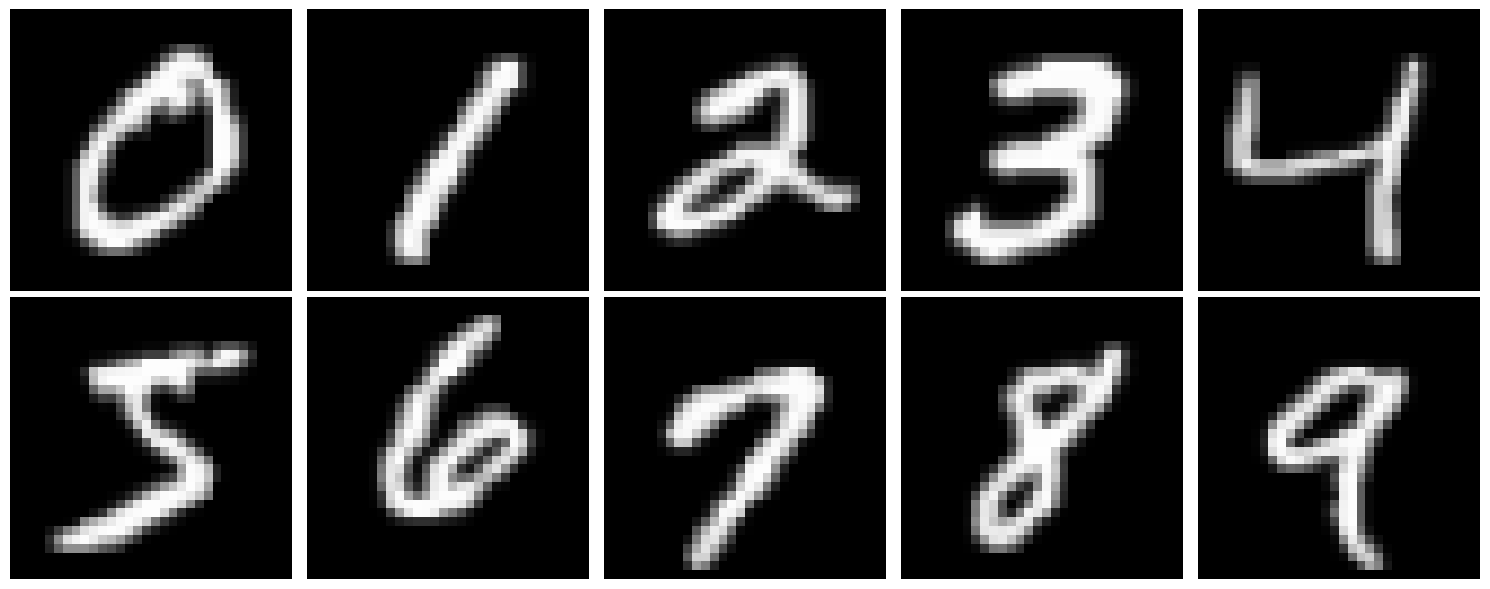

In [3]:
# construct data clusters as one digit per class
data_clusters = torch.zeros((10, 1, H, W))  # placeholder for cluster images
for digit in range(10):
    digit_indices = (labels == digit)
    data_clusters[digit] = data[digit_indices][0]

labels_clusters = torch.arange(10)

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# construct train and val datasets
data_size = data.shape[0]
train_size = int(train_val_split * data_size)
val_size = data_size - train_size
idx = torch.randperm(data_size)
train_idx, val_idx = idx[:train_size], idx[train_size:]
data_train, data_val = data[train_idx], data[val_idx]
labels_train, labels_val = labels[train_idx], labels[val_idx]

print("Data shapes: \n data.shape = {} \n data_train.shape = {} \n data_val.shape = {}".format(data.shape, data_train.shape, data_val.shape))

Data shapes: 
 data.shape = torch.Size([60000, 1, 32, 32]) 
 data_train.shape = torch.Size([48000, 1, 32, 32]) 
 data_val.shape = torch.Size([12000, 1, 32, 32])


In [5]:
# create dataset and dataloader
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)

## Learn an NFlow ##

In [6]:
class MultiLevelImageTransform(ImageTransform):
    def __init__(self, in_channels, height, width, image_transforms):
        """
        :param image_transforms: list of ImageTransform objects, one for each level of the multi-level transform.
        """
        self.L = len(image_transforms)
        assert image_transforms[0].C == in_channels * 4
        assert image_transforms[0].H == height // 2
        assert image_transforms[0].W == width // 2
        # assert that the image transform dimensions shrink by a factor of 2 at each level, but channels grow by a factor of 2 at each level
        assert all(image_transforms[i].C == image_transforms[i-1].C * 2 for i in range(1, self.L))
        assert all(image_transforms[i].H == image_transforms[i-1].H // 2 for i in range(1, self.L))
        assert all(image_transforms[i].W == image_transforms[i-1].W // 2 for i in range(1, self.L))
        super().__init__(in_channels, height, width)
        self.image_transforms = nn.ModuleList(image_transforms)

        self.squeeze = SqueezeTransform(factor=2)
        

    def forward(self, inputs, context=None):
        batch_size = inputs.shape[0]
        outputs = inputs
        total_logabsdet = inputs.new_zeros(batch_size)
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, log_abs_det = self.squeeze(outputs, None)
            total_logabsdet += log_abs_det

            # flow step
            outputs, log_abs_det = self.image_transforms[i](outputs, None)
            total_logabsdet += log_abs_det

            # split
            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # add context if provided
        if context is not None:
            assert context.shape[0] == batch_size
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs - context_

        # iterate through splits to get outputs in correct order
        for i in reversed(range(self.L)):
            # concatenate split back to outputs
            outputs = torch.cat([splits[i], outputs], dim=1)
            # unsqueeze
            outputs, _ = self.squeeze.inverse(outputs, None)

        return outputs, total_logabsdet
    
    def inverse(self, inputs, context=None):
        # iterate through splits to get outputs in correct order
        outputs = inputs
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, _ = self.squeeze(outputs, None)

            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # remove context if provided
        if context is not None:
            assert context.shape[0] == inputs.shape[0]
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs + context_

        total_logabsdet = inputs.new_zeros(inputs.shape[0])
        for i in reversed(range(self.L)):
            # concatenate
            outputs = torch.cat([splits[i], outputs], dim=1)

            # flow step
            outputs, log_abs_det = self.image_transforms[i].inverse(outputs, None)
            total_logabsdet += log_abs_det

            # unsqueeze
            outputs, log_abs_det = self.squeeze.inverse(outputs, None)
            total_logabsdet += log_abs_det

        return outputs, total_logabsdet

In [7]:
class SimpleMultiLevelImageTransform(MultiLevelImageTransform):
    def __init__(self, in_channels, height, width, kernel_size=3, hidden_channels=64, n_flows=3, n_scales=3):
        super().__init__(in_channels, height, width, [self.create_transform(in_channels * (2 ** i) * 2, height // (2 ** i), width // (2 ** i), kernel_size, hidden_channels, n_flows) for i in range(1, n_scales+1)])

    def create_transform(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        transforms_list = []
        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels)) # OneByOneConvolution
            transforms_list.append(OneByOneConvolution(in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(OneByOneConvolution(in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transform = ImageCompositeTransform(in_channels, height, width, transforms_list)
        return transform

In [8]:
# construct nflow and trainer
nflow = Flow(transform=SimpleMultiLevelImageTransform(in_channels=1, height=H, width=W, kernel_size=nflow_cfg["kernel_size"], hidden_channels=nflow_cfg["hidden_channels"], n_flows=nflow_cfg["n_flows"], n_scales=nflow_cfg["n_scales"]),
             distribution=StandardNormal(shape=[1, H, W])).to(device)

nflow_trainer = NFlowTraining(nflow)

In [9]:
# construct train loop
def train_nflow(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf'), save_every=10):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for x in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.nflow.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        if (epoch+1) % save_every == 0 or (epoch+1) == n_epochs:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [10]:
# train or load nflow model
nflow_extension = f"lr_{nflow_cfg['learning_rate']}_kernel_{nflow_cfg['kernel_size']}_hidden_{nflow_cfg['hidden_channels']}_flows_{nflow_cfg['n_flows']}_scales_{nflow_cfg['n_scales']}"
checkpoint_dir = os.path.join(results_folder, nflow_cfg["checkpoint_subdir"], nflow_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if nflow_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])
        nflow_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    train_nflow(
        nflow_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=nflow_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])

In [11]:
# construct diffeomorphism from nflow
phi = NFlowImageDiffeomorphism(1, H, W, nflow_trainer.nflow)

In [12]:
# construct pullback manifold and ref manifold
phi_manifold = StandardPullbackImageEuclidean(phi)
l2_euclidean = StandardImageEuclidean(1, H, W)

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(


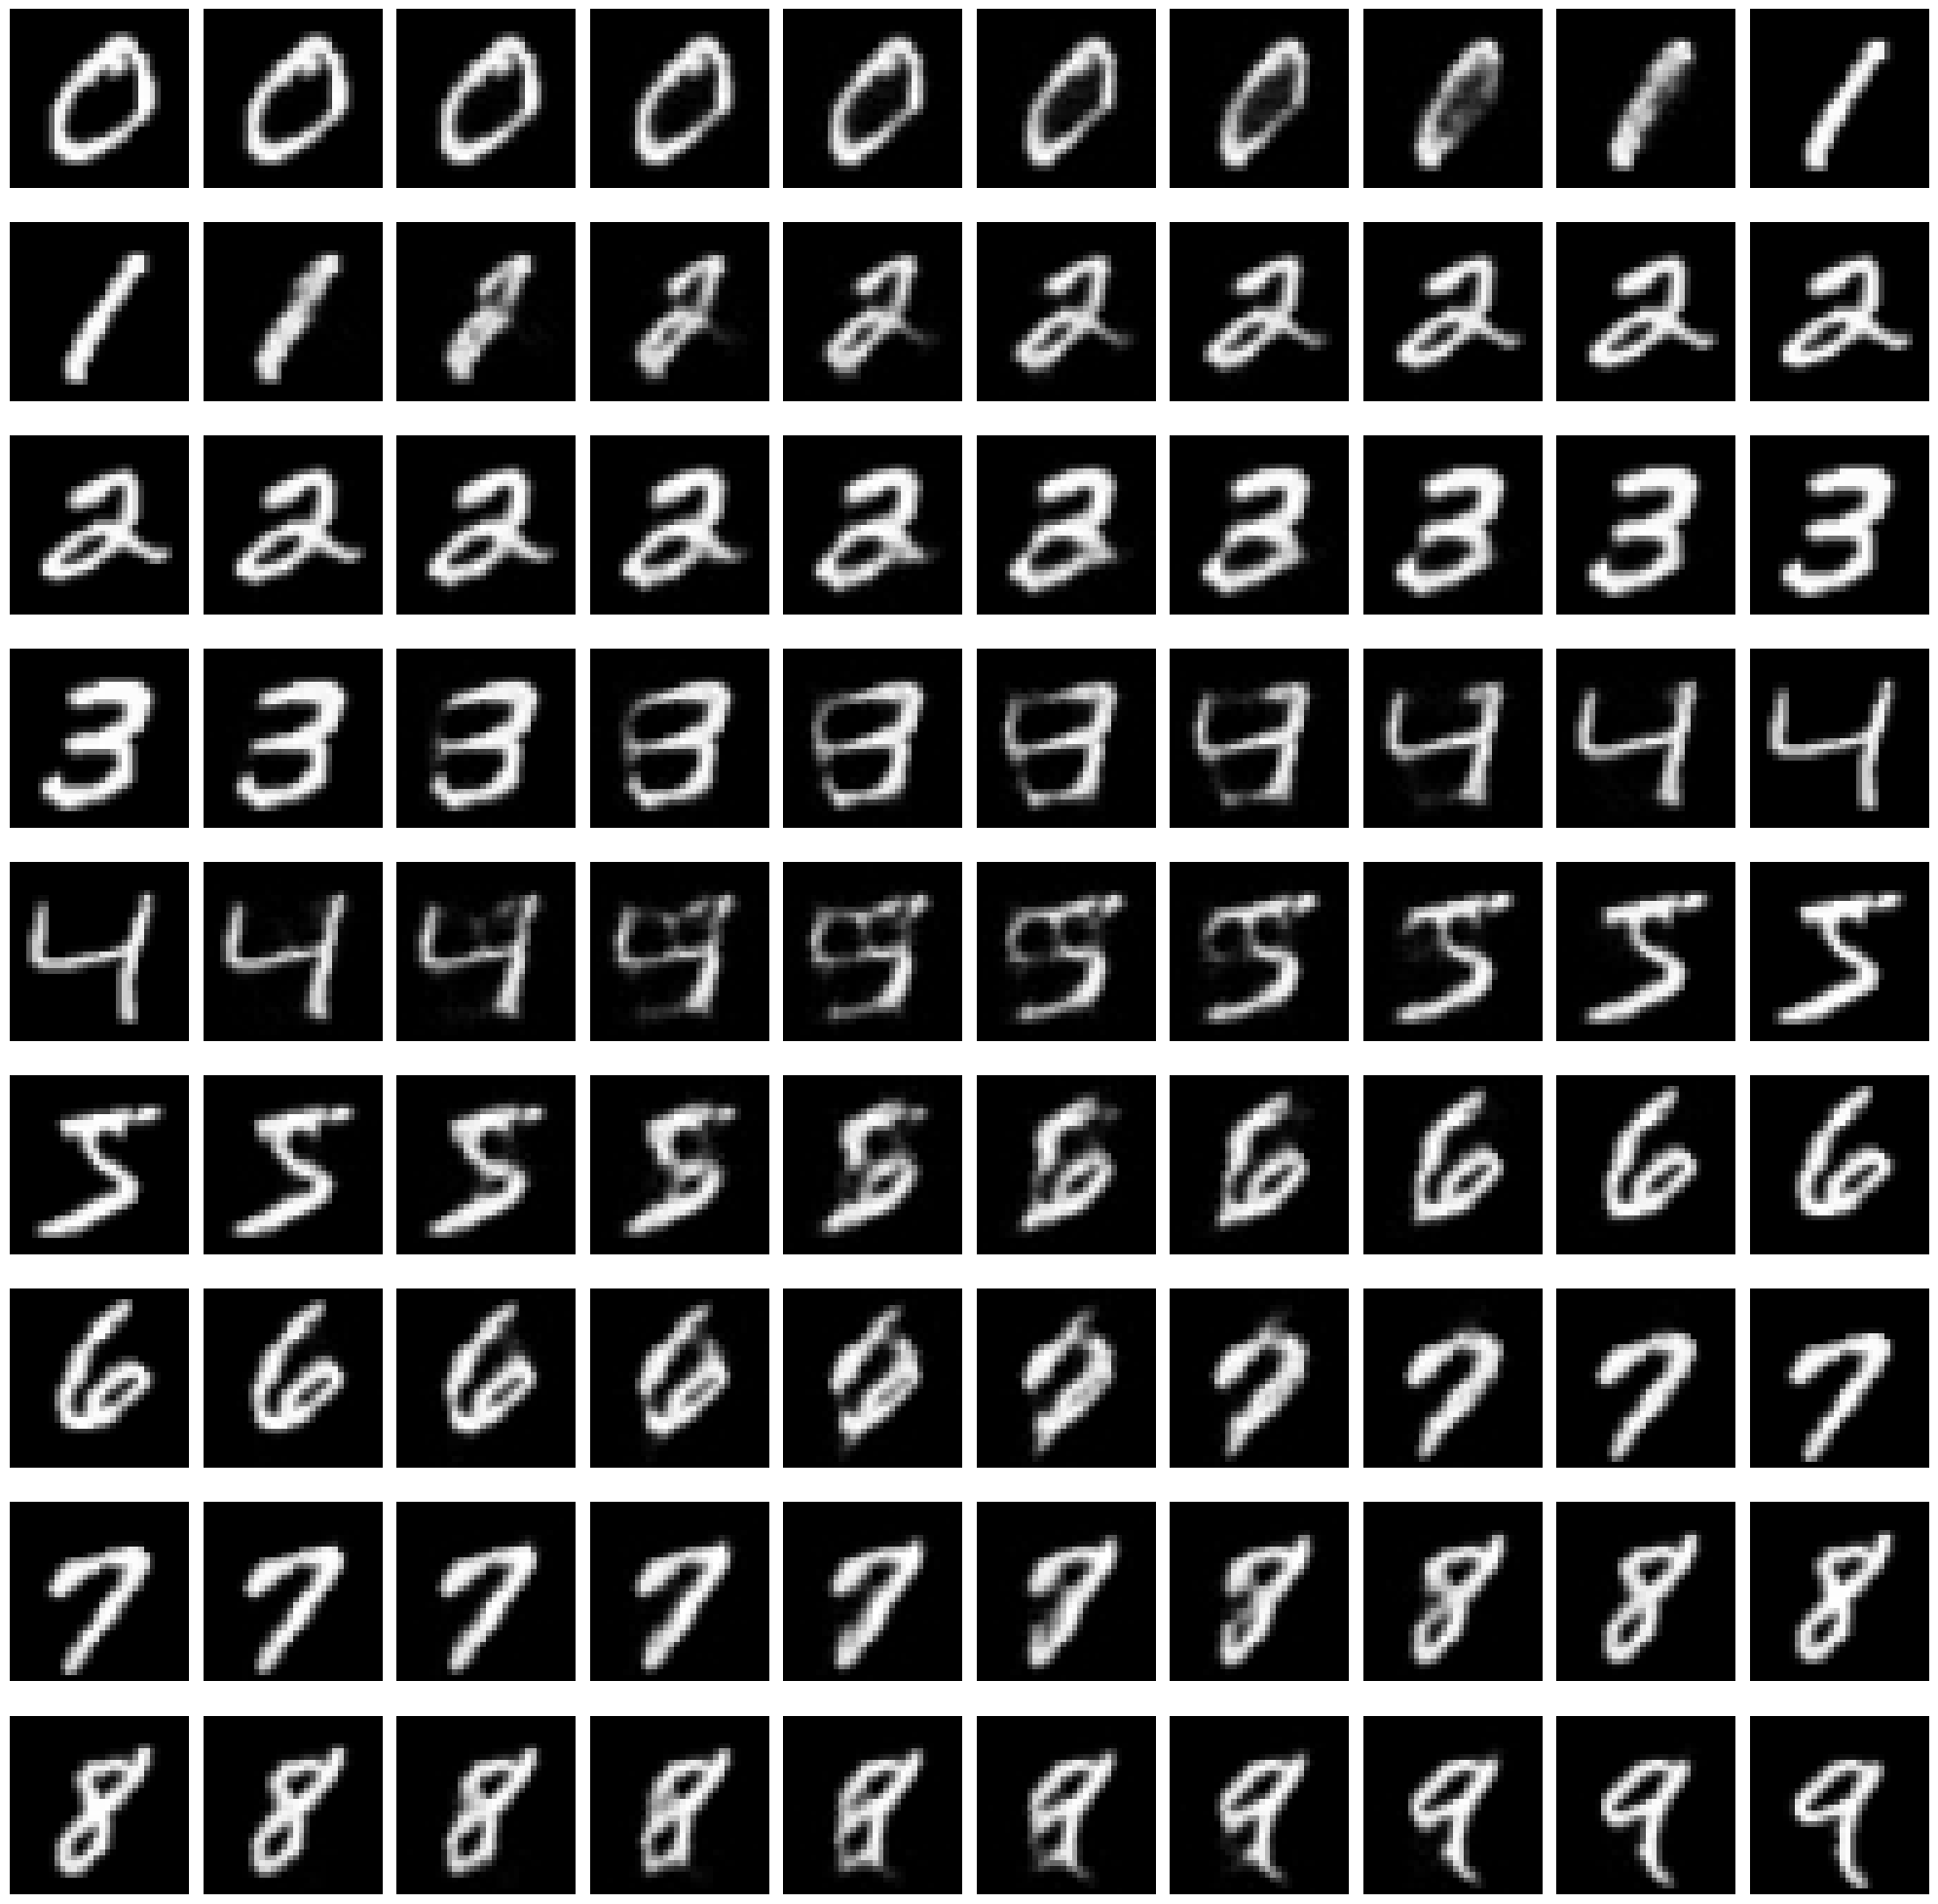

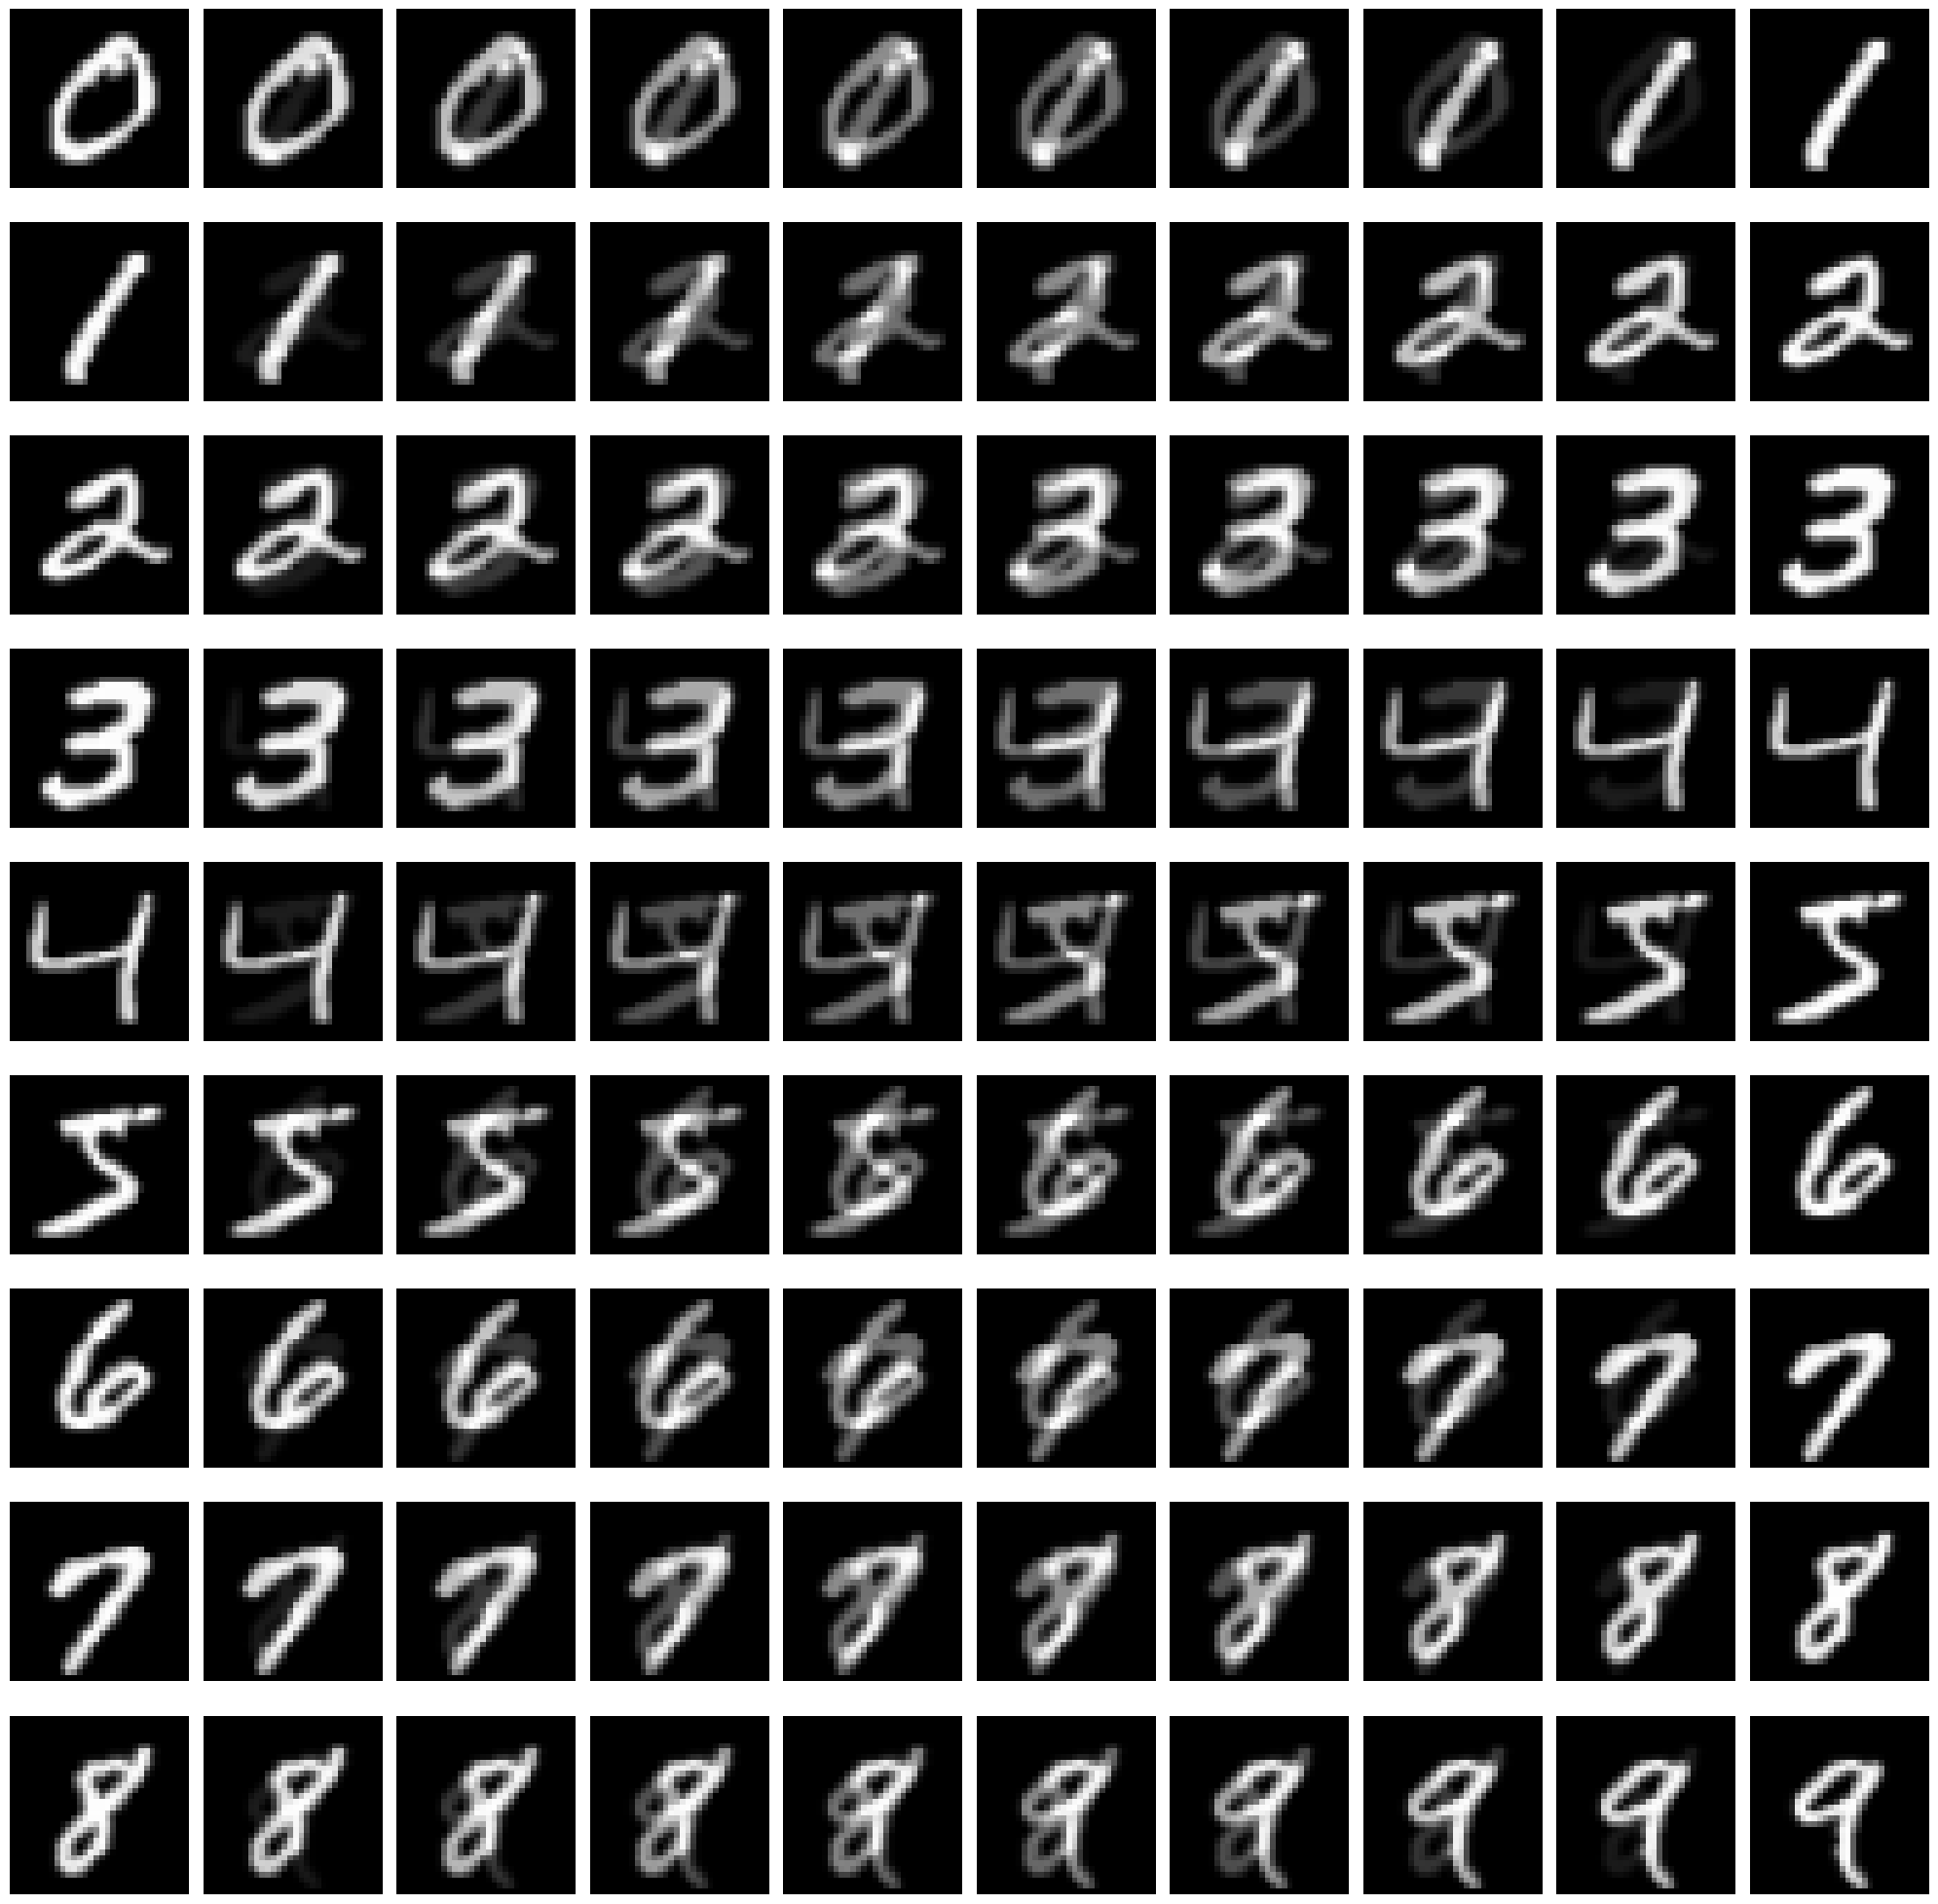

In [13]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    phi_geodesics = phi_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()
    interpolations = l2_euclidean.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(phi_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_phi.png"))
plt.show()

# plot interpolations
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow(interpolations[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"linear_interpolations.png"))
plt.show()

## Learn a Latent Space Star ##

In [14]:
phi_data_train = torch.zeros_like(data_train)
i = 0
with torch.no_grad():
    for x in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        b = x.size(0)                      # actual batch size
        phi_data_train[i:i+b] = phi(x).cpu()
        i += b
    phi_data_clusters = phi(data_clusters.to(device)).cpu()

100%|██████████| 375/375 [00:37<00:00,  9.95it/s]


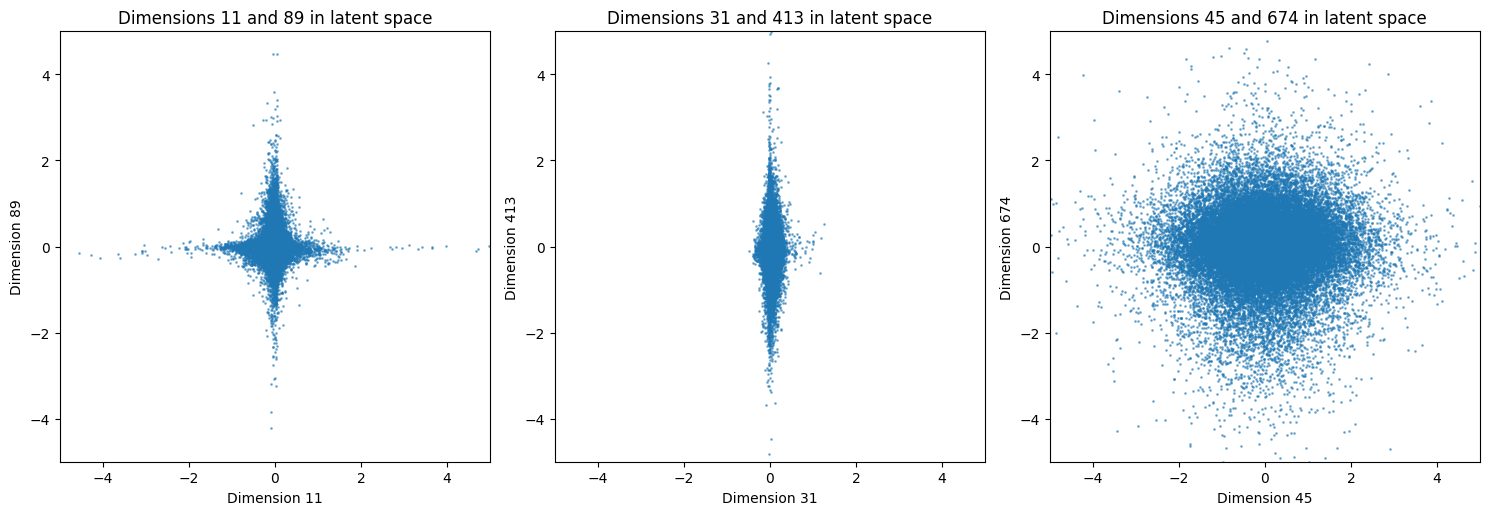

In [15]:
# plot first two dimensions of phi_data_train
dims_1 = [11, 89]
dims_2 = [31, 413]
dims_3 = [45, 674]

# three scatter plots of different dimensions of phi_data_train
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(phi_data_train.reshape(-1, size*size)[:, dims_1[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_1[1]].numpy(), s=1, alpha=0.5)
ax[0].set_title(f"Dimensions {dims_1[0]} and {dims_1[1]} in latent space")
ax[0].set_xlabel(f"Dimension {dims_1[0]}")
ax[0].set_ylabel(f"Dimension {dims_1[1]}")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-5, 5)

ax[1].scatter(phi_data_train.reshape(-1, size*size)[:, dims_2[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_2[1]].numpy(), s=1, alpha=0.5)
ax[1].set_title(f"Dimensions {dims_2[0]} and {dims_2[1]} in latent space")
ax[1].set_xlabel(f"Dimension {dims_2[0]}")
ax[1].set_ylabel(f"Dimension {dims_2[1]}")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-5, 5)

ax[2].scatter(phi_data_train.reshape(-1, size*size)[:, dims_3[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_3[1]].numpy(), s=1, alpha=0.5)
ax[2].set_title(f"Dimensions {dims_3[0]} and {dims_3[1]} in latent space")
ax[2].set_xlabel(f"Dimension {dims_3[0]}")
ax[2].set_ylabel(f"Dimension {dims_3[1]}")
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlim(-5, 5)
ax[2].set_ylim(-5, 5)
plt.tight_layout()
plt.show()

In [16]:
# # compute barycentre and logs
# with torch.no_grad():
#     phi_barycentre = phi.inverse(phi_data_train.mean(dim=0, keepdim=True).to(device)).cpu()

# phi_logs_data_train = torch.zeros_like(data_train)
# i = 0
# with torch.no_grad():
#     for x in tqdm(train_loader):
#         x = x.to(device, non_blocking=True)
#         b = x.size(0)                      # actual batch size
#         phi_logs_data_train[i:i+b] = phi_manifold.log(phi_barycentre.to(device)[None], x[None]).cpu()[0,0]
#         i += b

### Supervised ###

In [17]:
# construct pullback manifold
psi = ConcaveImageDiffeomorphism(1, H, W, LogConcave(a=10.))
Omega = ImageCompositionDiffeomorphism([phi, psi], 1, H, W)
Omega_manifold = StandardPullbackImageEuclidean(phi)
iso_Omega_manifold = l2IsometrizedImageEuclidean(Omega_manifold, num_intervals=20)

In [18]:
# construct centers
centers_supervised = []
phi_centers_supervised = []
for label in torch.unique(labels):
    phi_center = phi_data_train[torch.tensor(labels_train) == label].mean(dim=0)
    phi_centers_supervised.append(phi_center.reshape(size * size))
    with torch.no_grad():
        center = phi.inverse(phi_center.to(device)[None]).cpu()[0]
    centers_supervised.append(center)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/724732502.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_center = phi_data_train[torch.tensor(labels_train) == label].mean(dim=0)


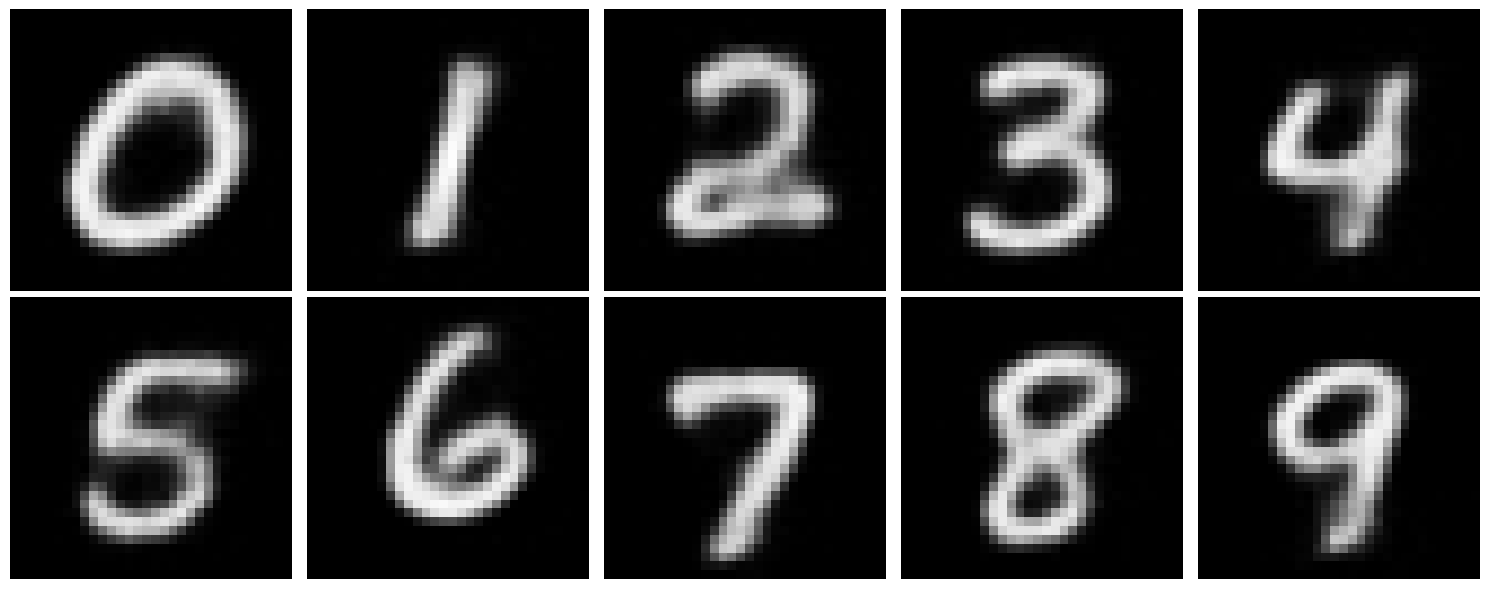

In [19]:
# visualize cluster centers
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for k in range(10):
    axes[k].imshow(centers_supervised[k].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[k].axis('off') 
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"barycentres_phi_supervised.png"))
plt.show()

In [20]:
# construct archetypes
n_archetypes = 30

archetypes_supervised = []
phi_archetypes_supervised = []
for label in torch.unique(labels):
    phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)
    print(f"Constructing archetypes for label {label} with {phi_data_train_label.shape[0]} samples")
    aa = AA(n_archetypes, init='furthest_sum')
    aa.fit(phi_data_train_label)
    with torch.no_grad():
        archetypes = phi.inverse(torch.from_numpy(aa.archetypes_).to(device).reshape(n_archetypes, 1, H, W)).cpu()
    archetypes_supervised.append(archetypes)
    phi_archetypes_supervised.append(torch.from_numpy(aa.archetypes_))

# archetypes_supervised = []
# phi_archetypes_supervised = []
# for label in torch.unique(labels):
#     phi_logs_data_train_label = phi_logs_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)
#     print(f"Constructing archetypes for label {label} with {phi_logs_data_train_label.shape[0]} samples")
#     aa = AA(n_archetypes, init='furthest_sum')
#     aa.fit(phi_logs_data_train_label)
#     with torch.no_grad():
#         archetypes = phi_manifold.exp(phi_barycentre.to(device), torch.from_numpy(aa.archetypes_).to(device).reshape(1, n_archetypes, 1, H, W)).cpu()[0]
#         phi_archetypes = phi(archetypes.to(device).reshape(n_archetypes, 1, H, W)).cpu().reshape(n_archetypes, size * size)
#     archetypes_supervised.append(archetypes)
#     phi_archetypes_supervised.append(phi_archetypes)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 0 with 4724 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 1 with 5365 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 2 with 4744 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 3 with 4889 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 4 with 4662 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 5 with 4314 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 6 with 4732 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 7 with 5091 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 8 with 4744 samples


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_21769/628282362.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label = phi_data_train[torch.tensor(labels_train) == label].reshape(-1, size * size)


Constructing archetypes for label 9 with 4735 samples


In [21]:
for i in range(10):
    print(f"Label {i}: phi Center shape: {phi_centers_supervised[i].shape}, phi Archetypes shape: {phi_archetypes_supervised[i].shape}")
    print(f"Label {i}: Center shape: {centers_supervised[i].shape}, Archetypes shape: {archetypes_supervised[i].shape}")

Label 0: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([30, 1024])
Label 0: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([30, 1, 32, 32])
Label 1: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([30, 1024])
Label 1: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([30, 1, 32, 32])
Label 2: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([30, 1024])
Label 2: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([30, 1, 32, 32])
Label 3: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([30, 1024])
Label 3: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([30, 1, 32, 32])
Label 4: phi Center shape: torch.Size([1024]), phi Archetypes shape: torch.Size([30, 1024])
Label 4: Center shape: torch.Size([1, 32, 32]), Archetypes shape: torch.Size([30, 1, 32, 32])
Label 5: phi Center shape: torch.Size([1024]), phi Archetypes shape: t

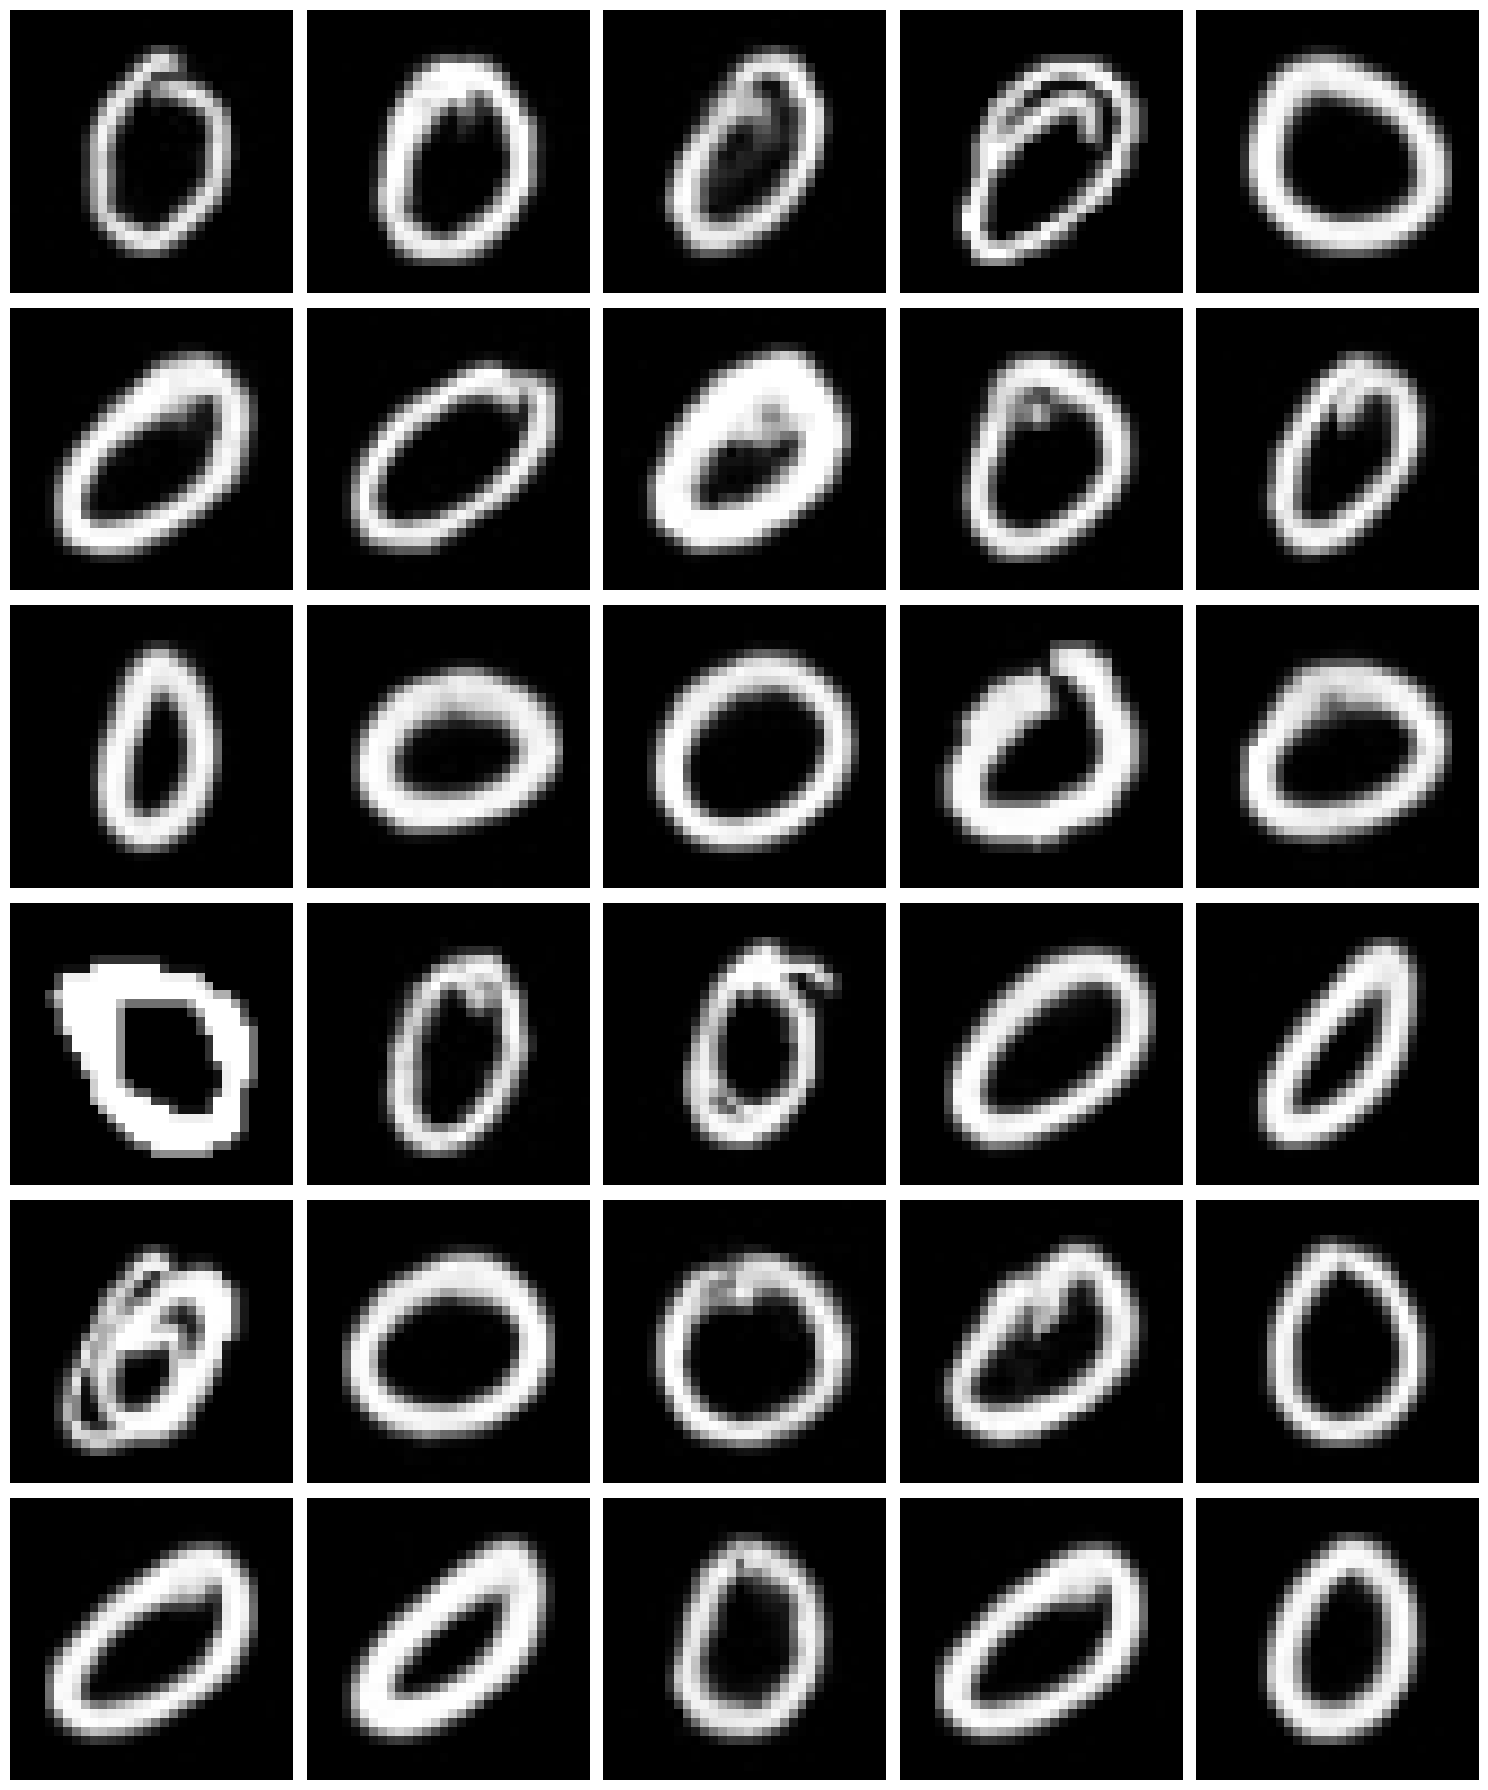

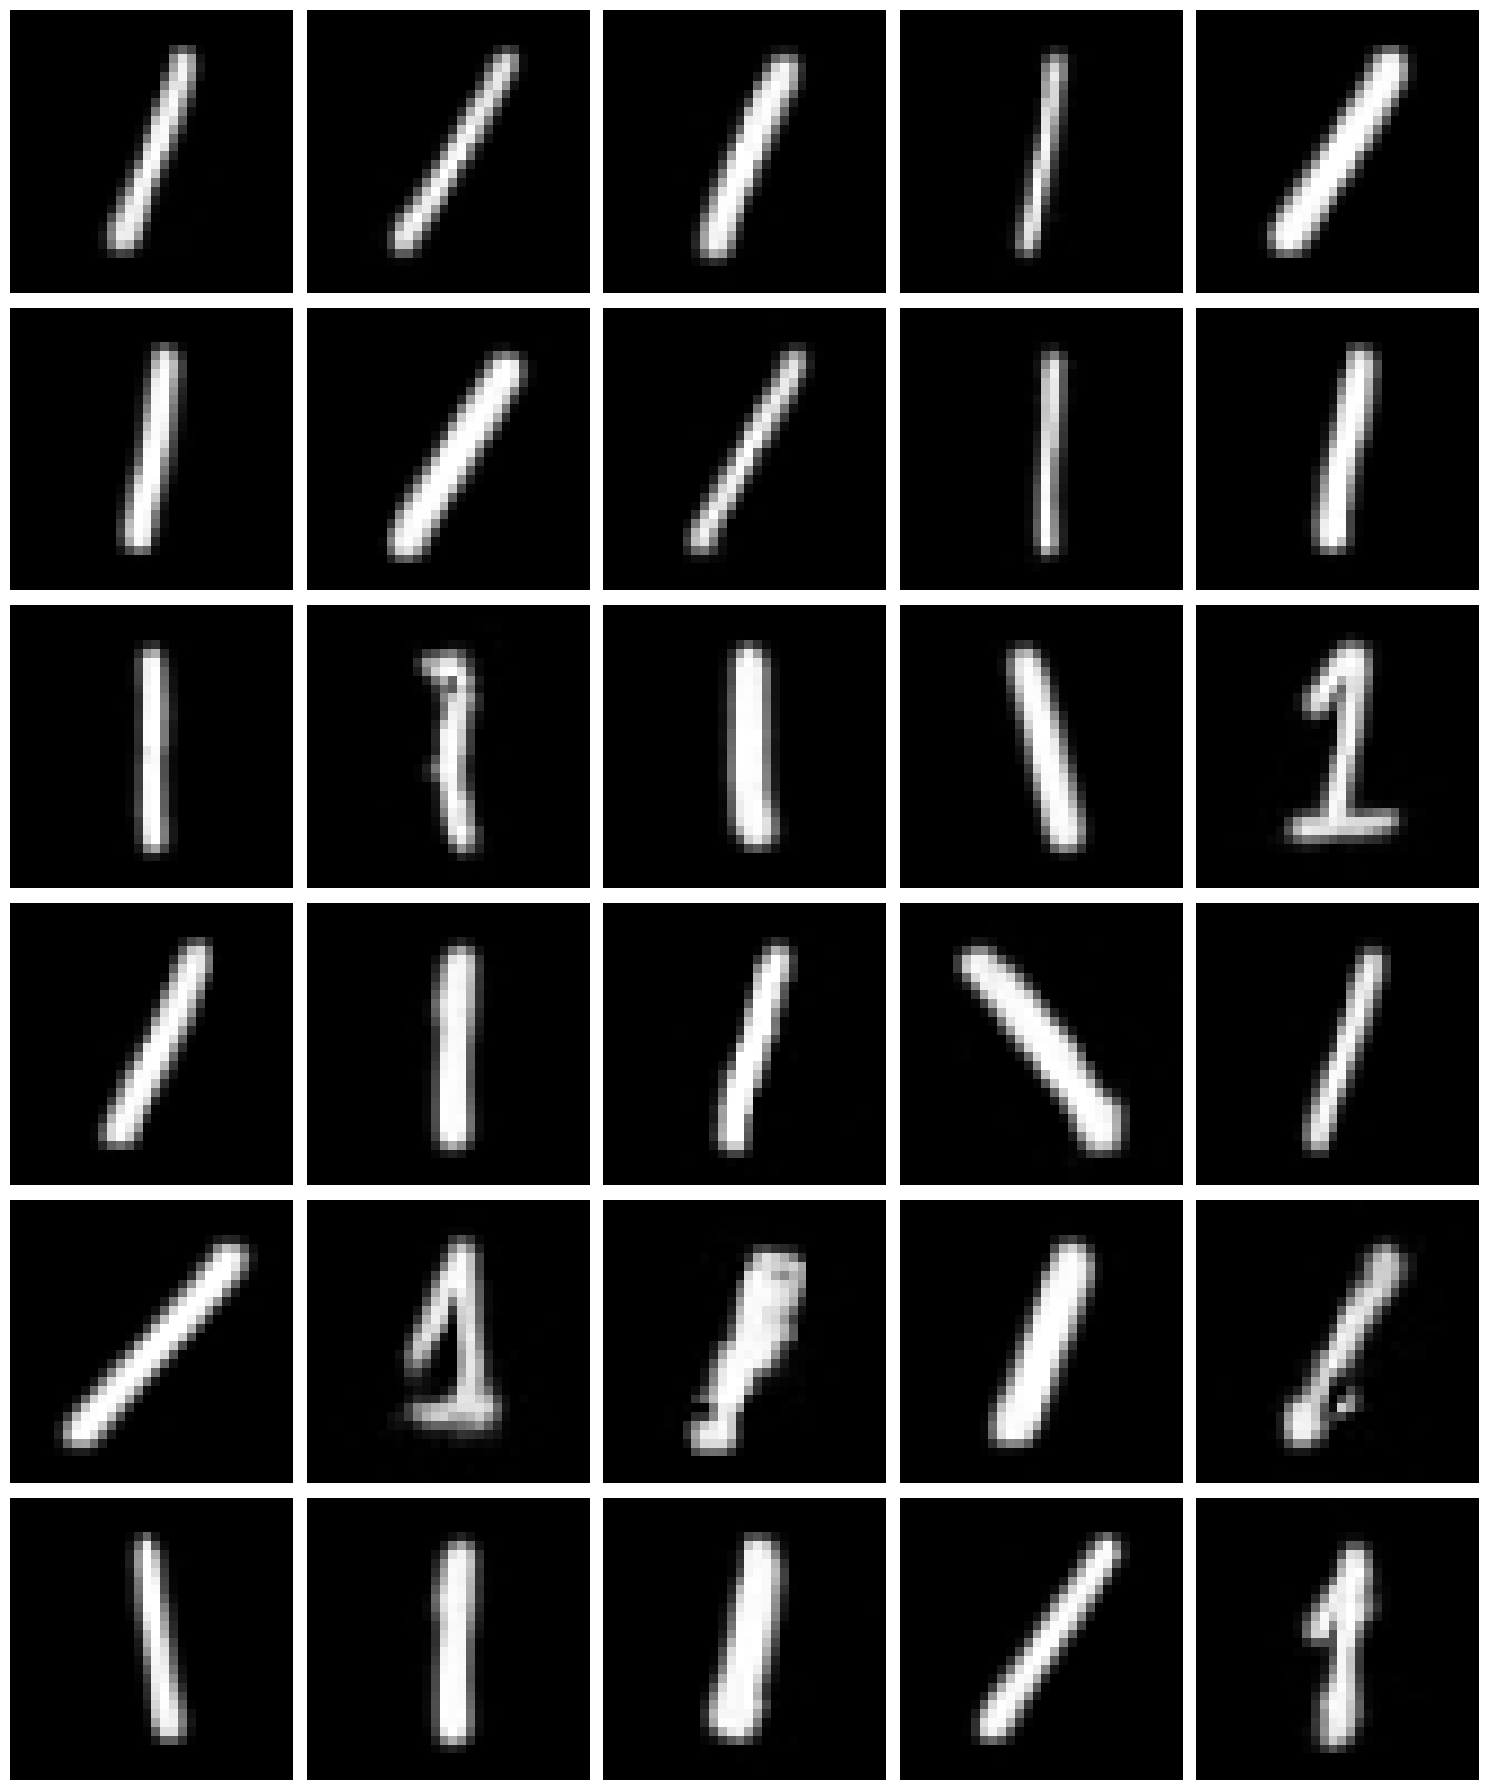

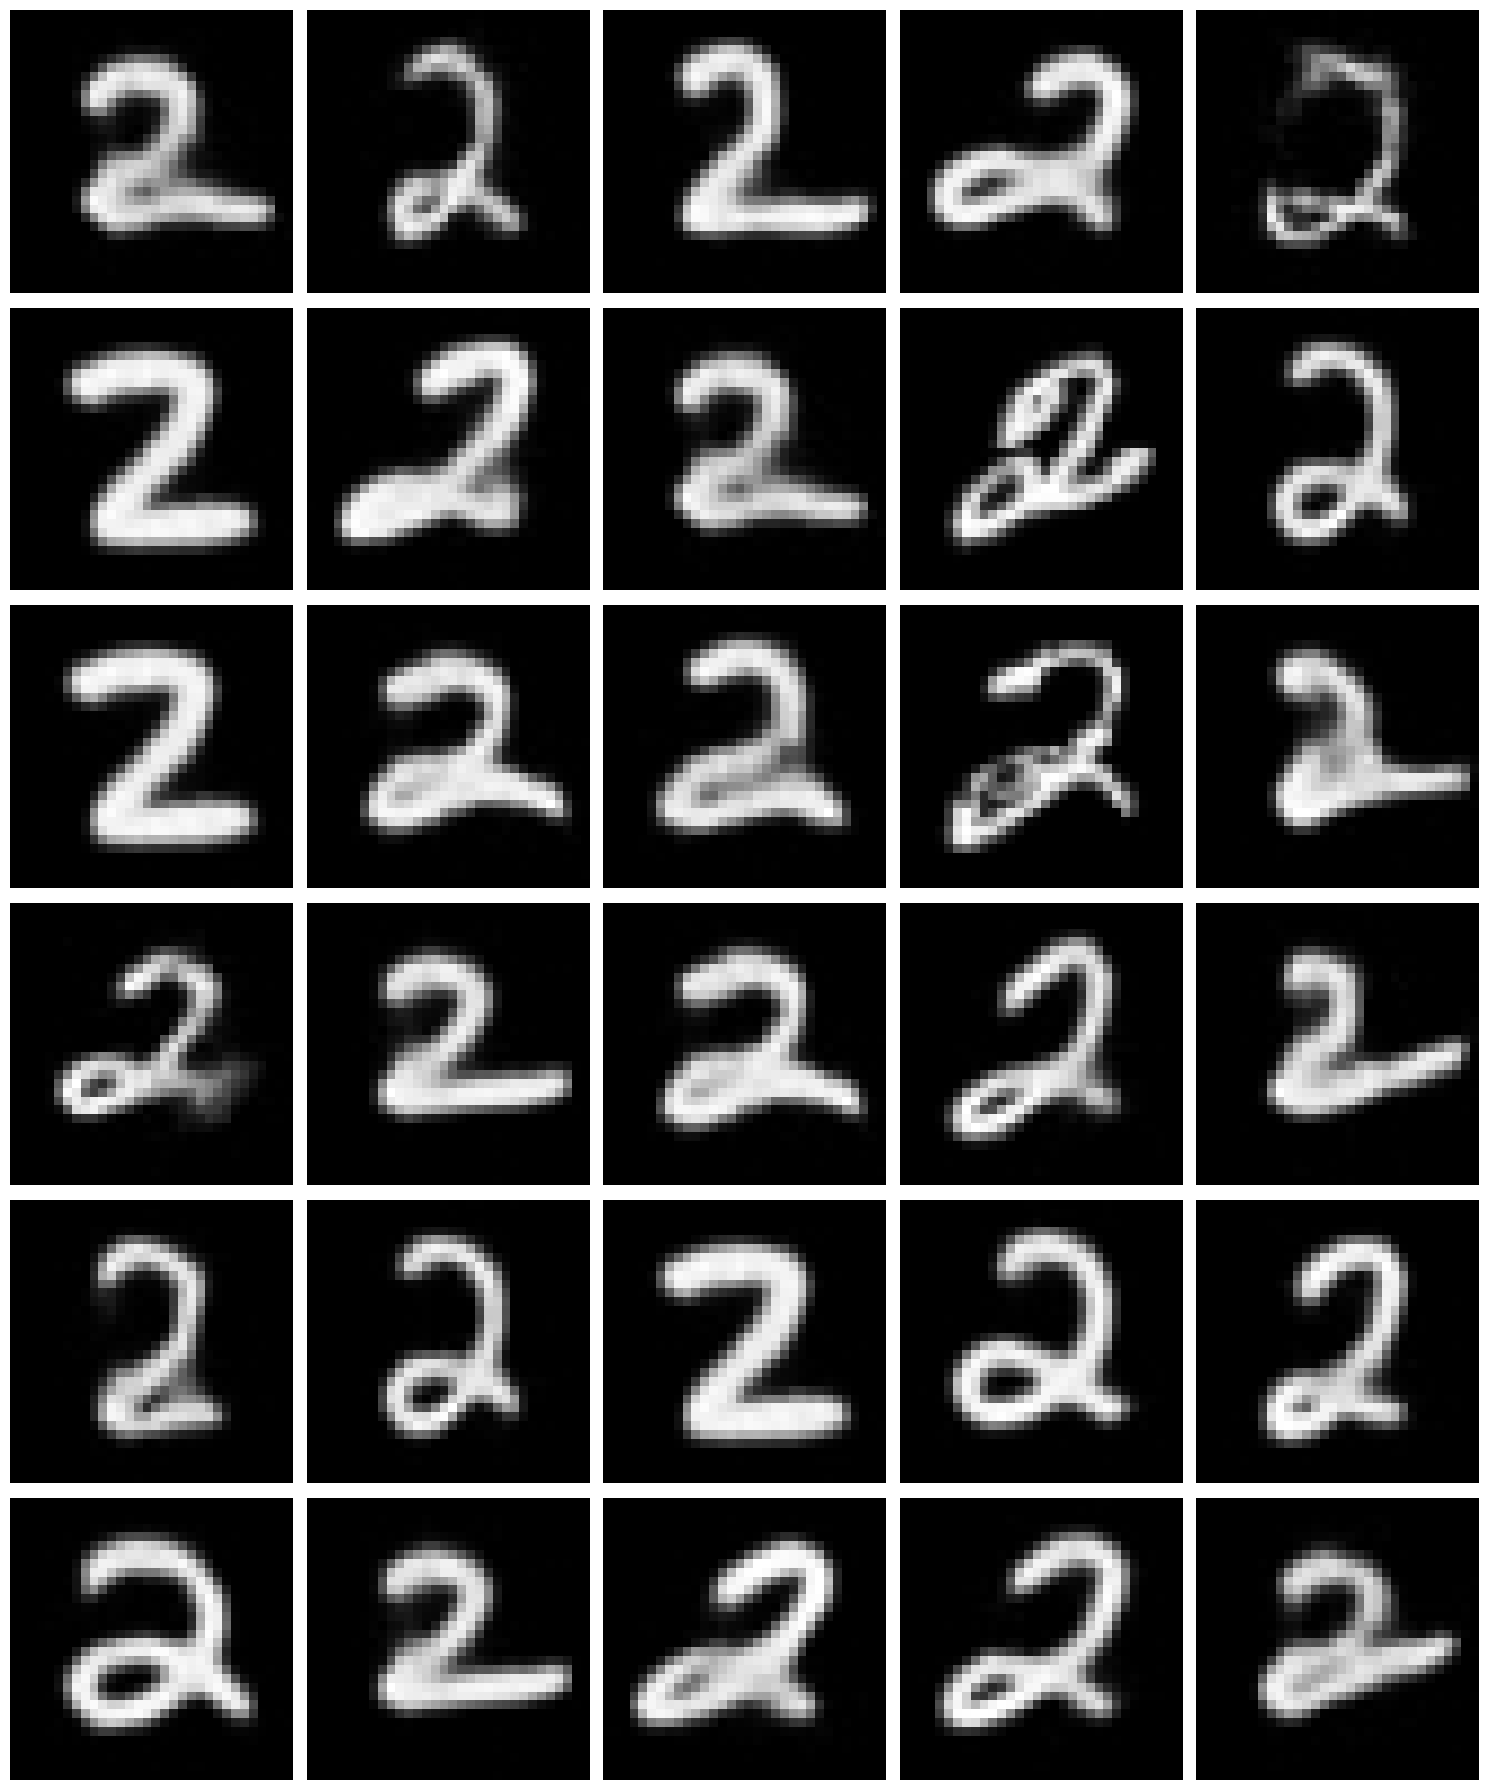

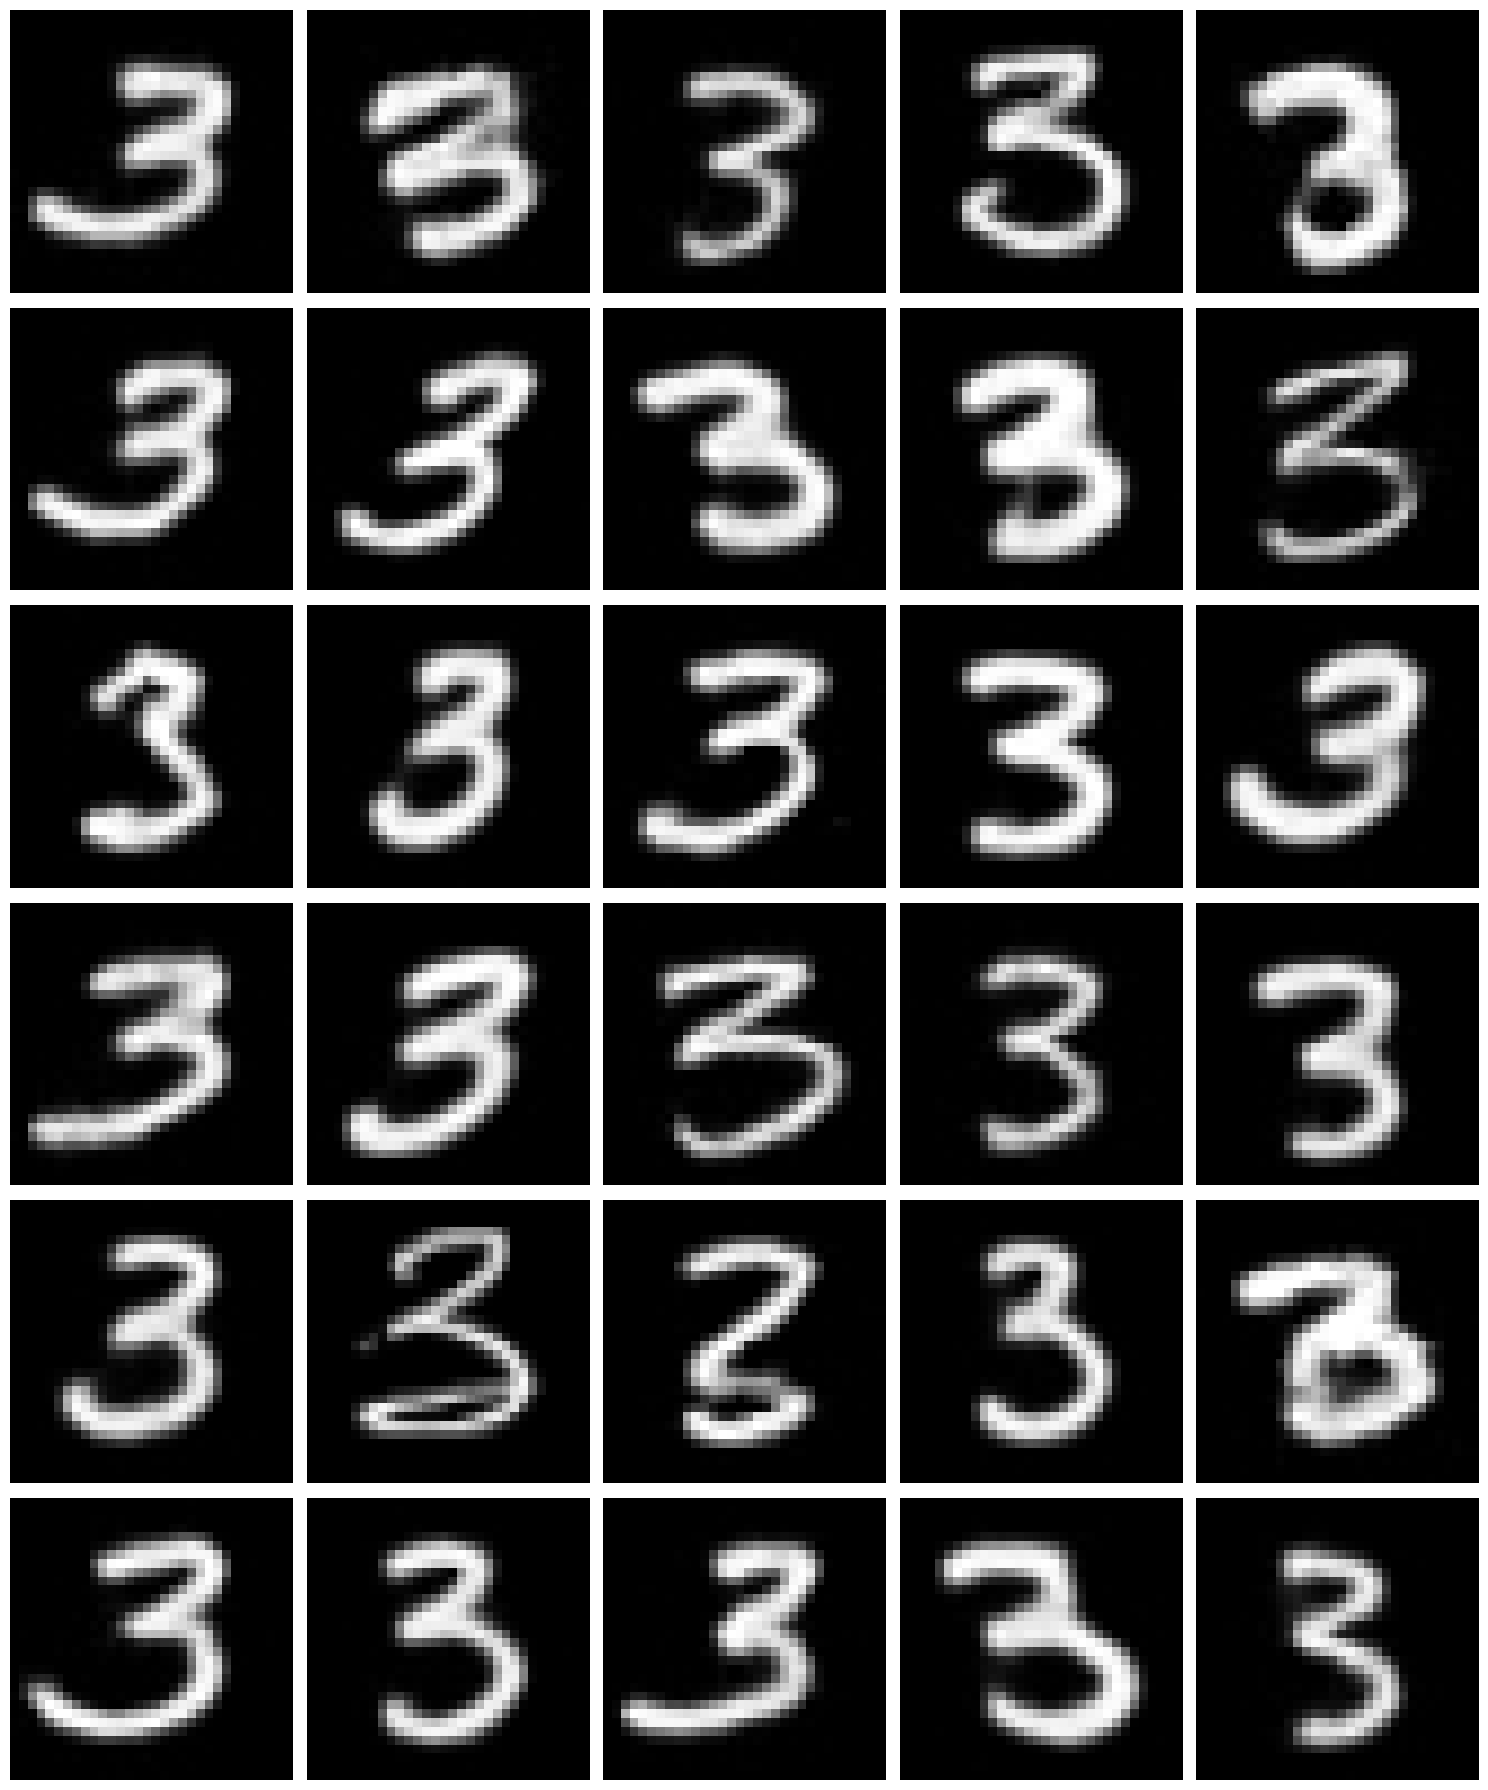

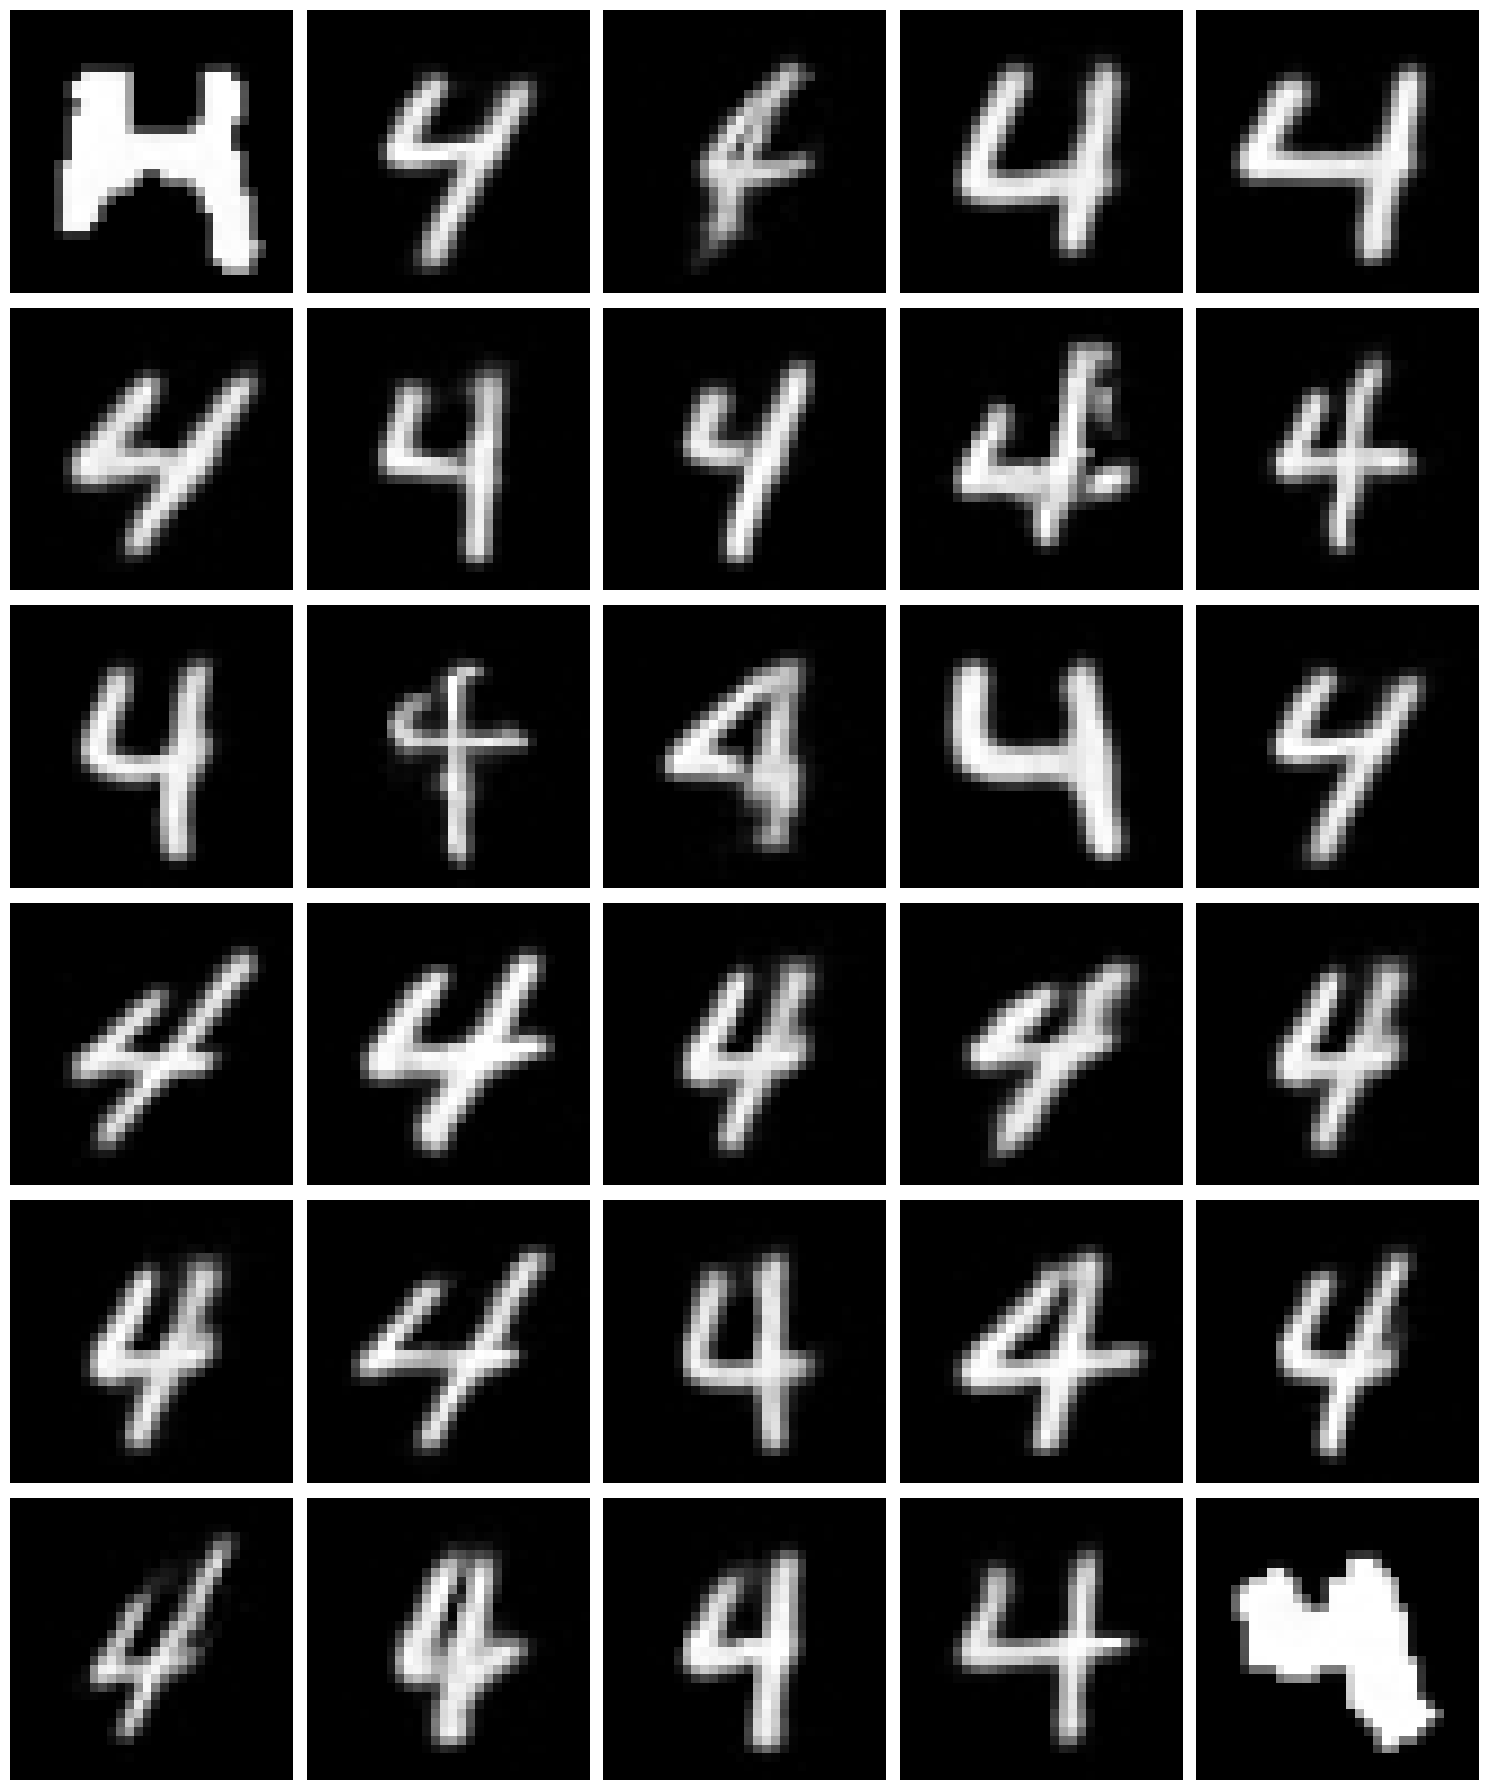

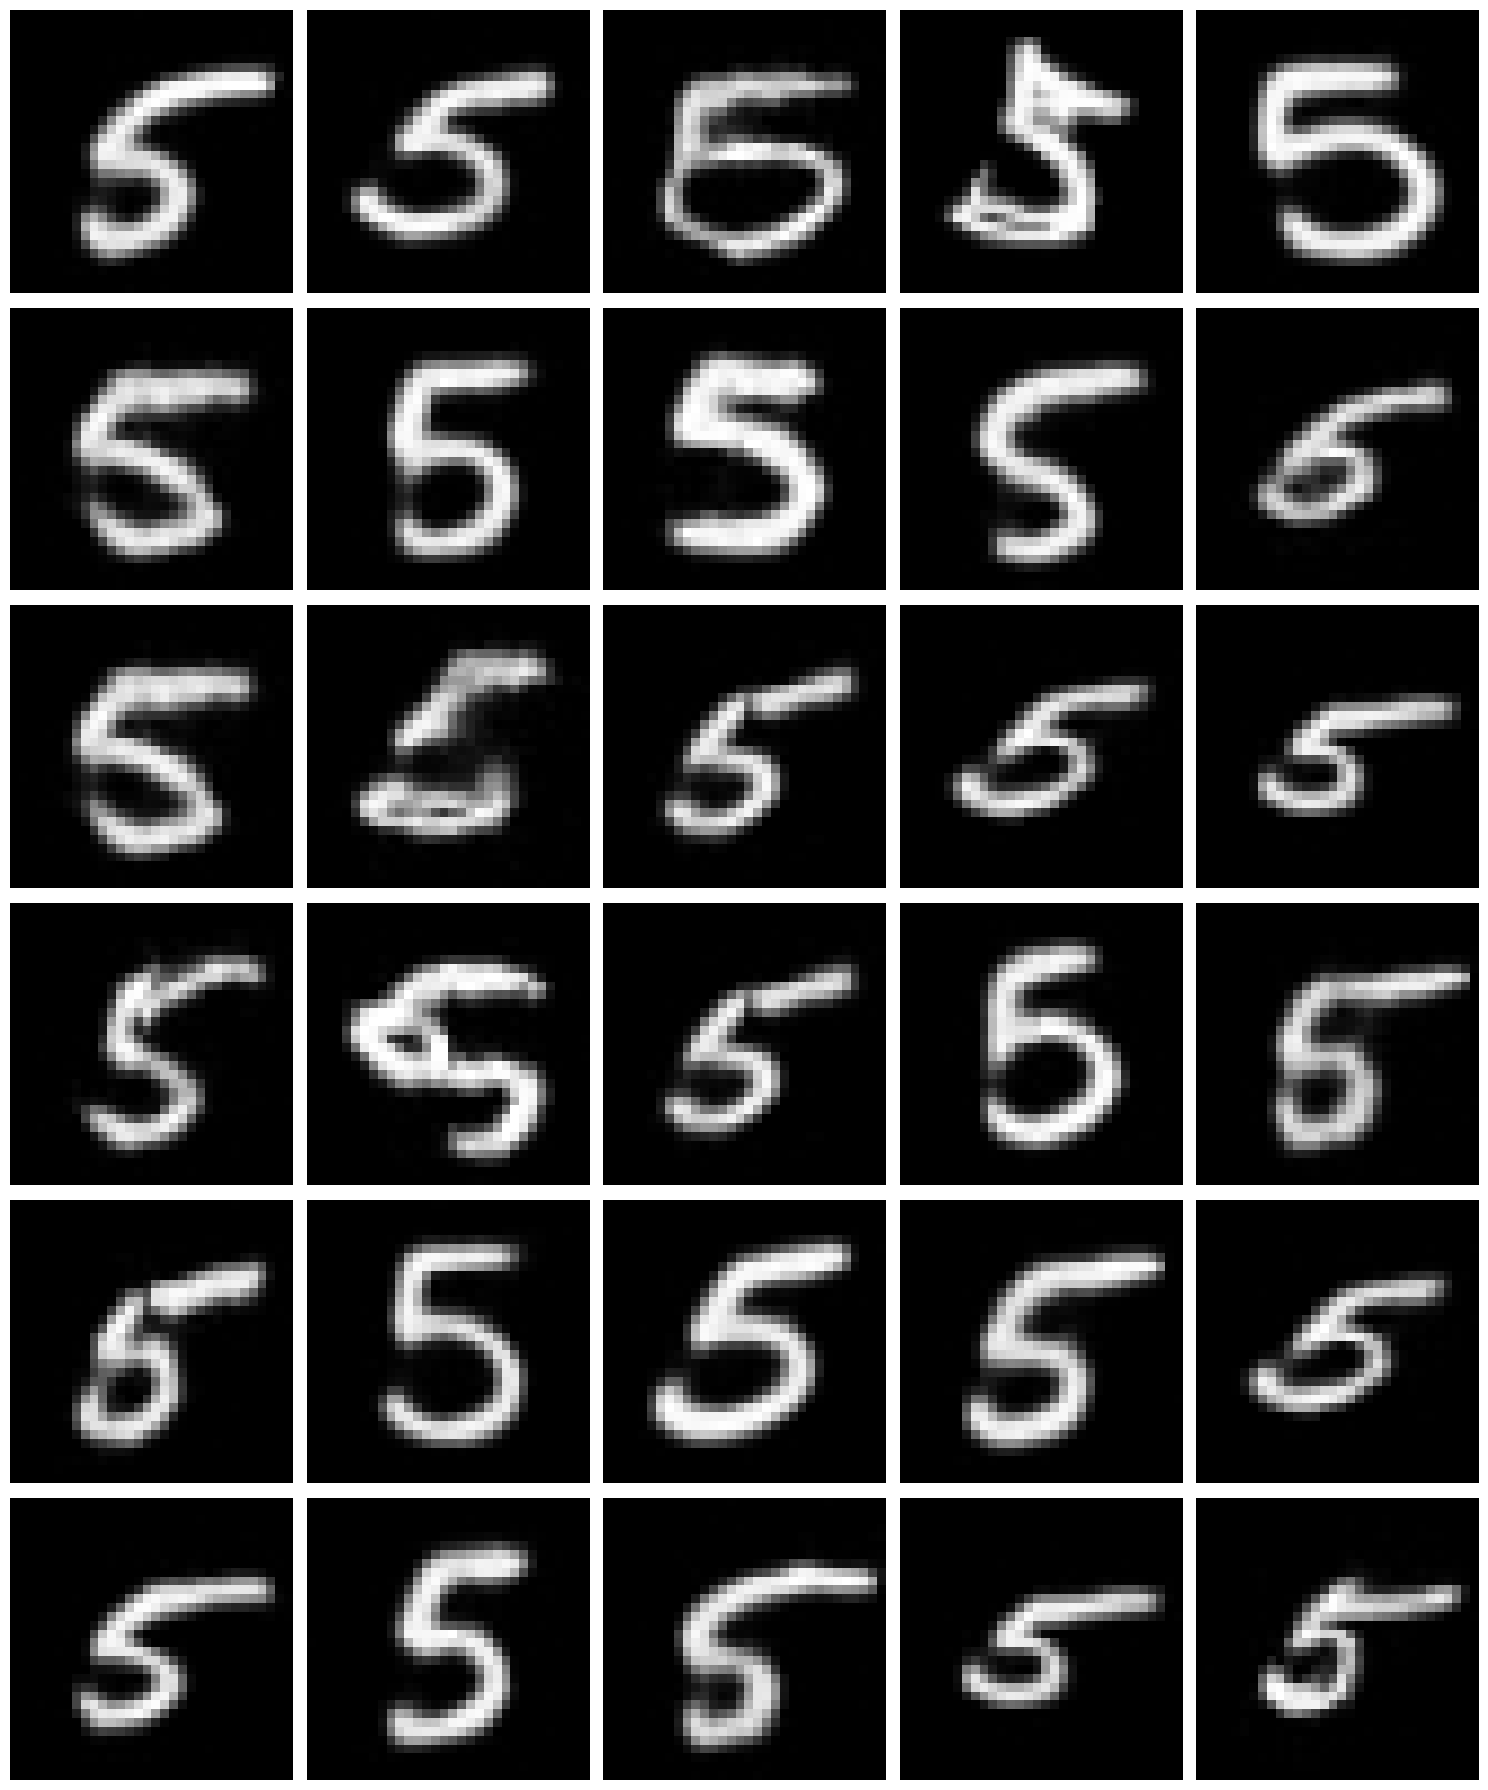

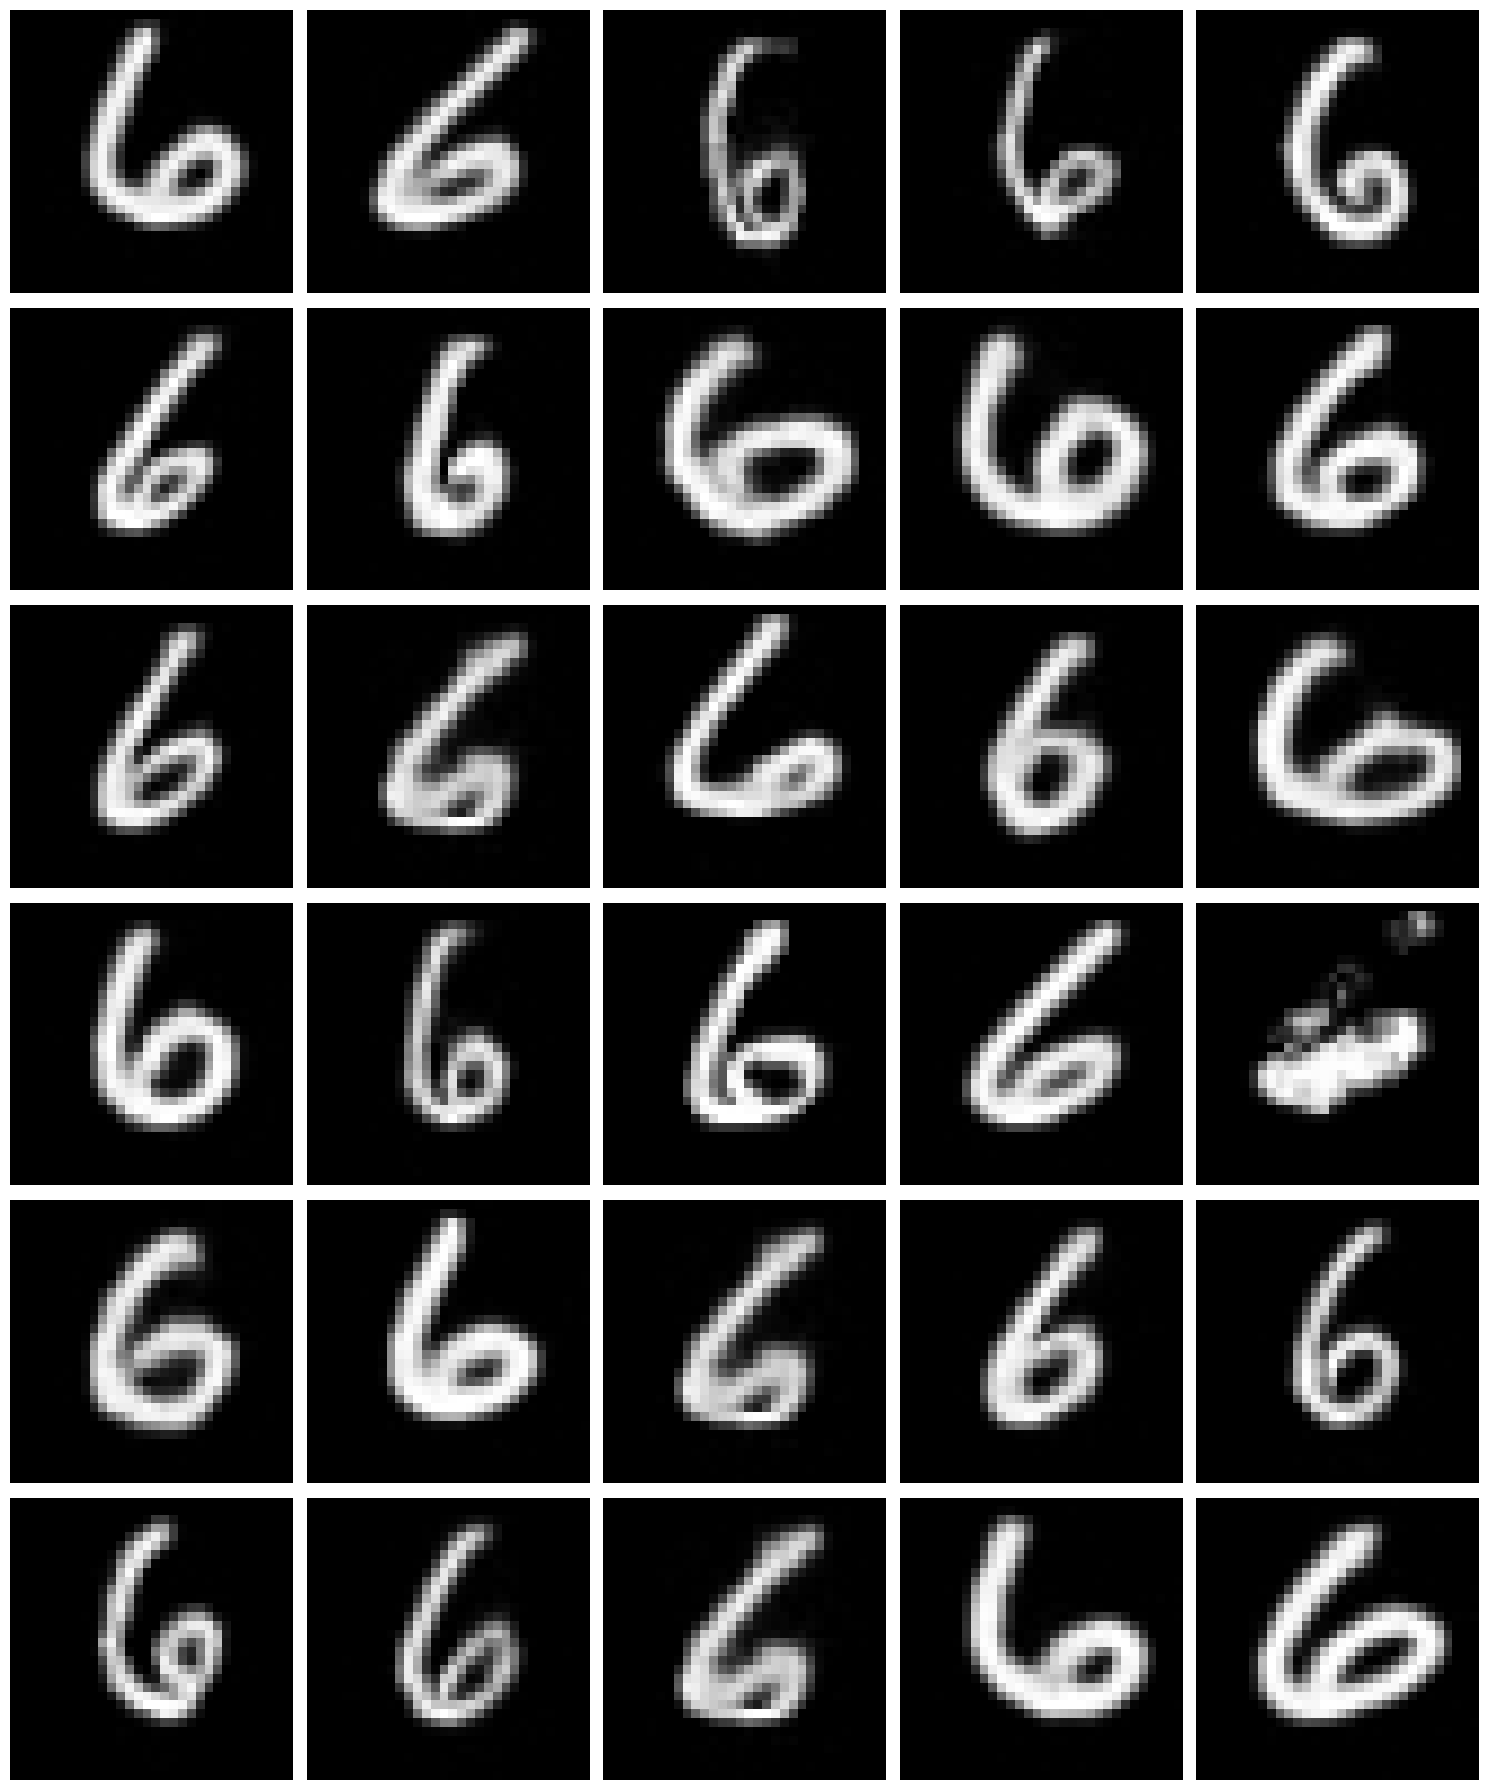

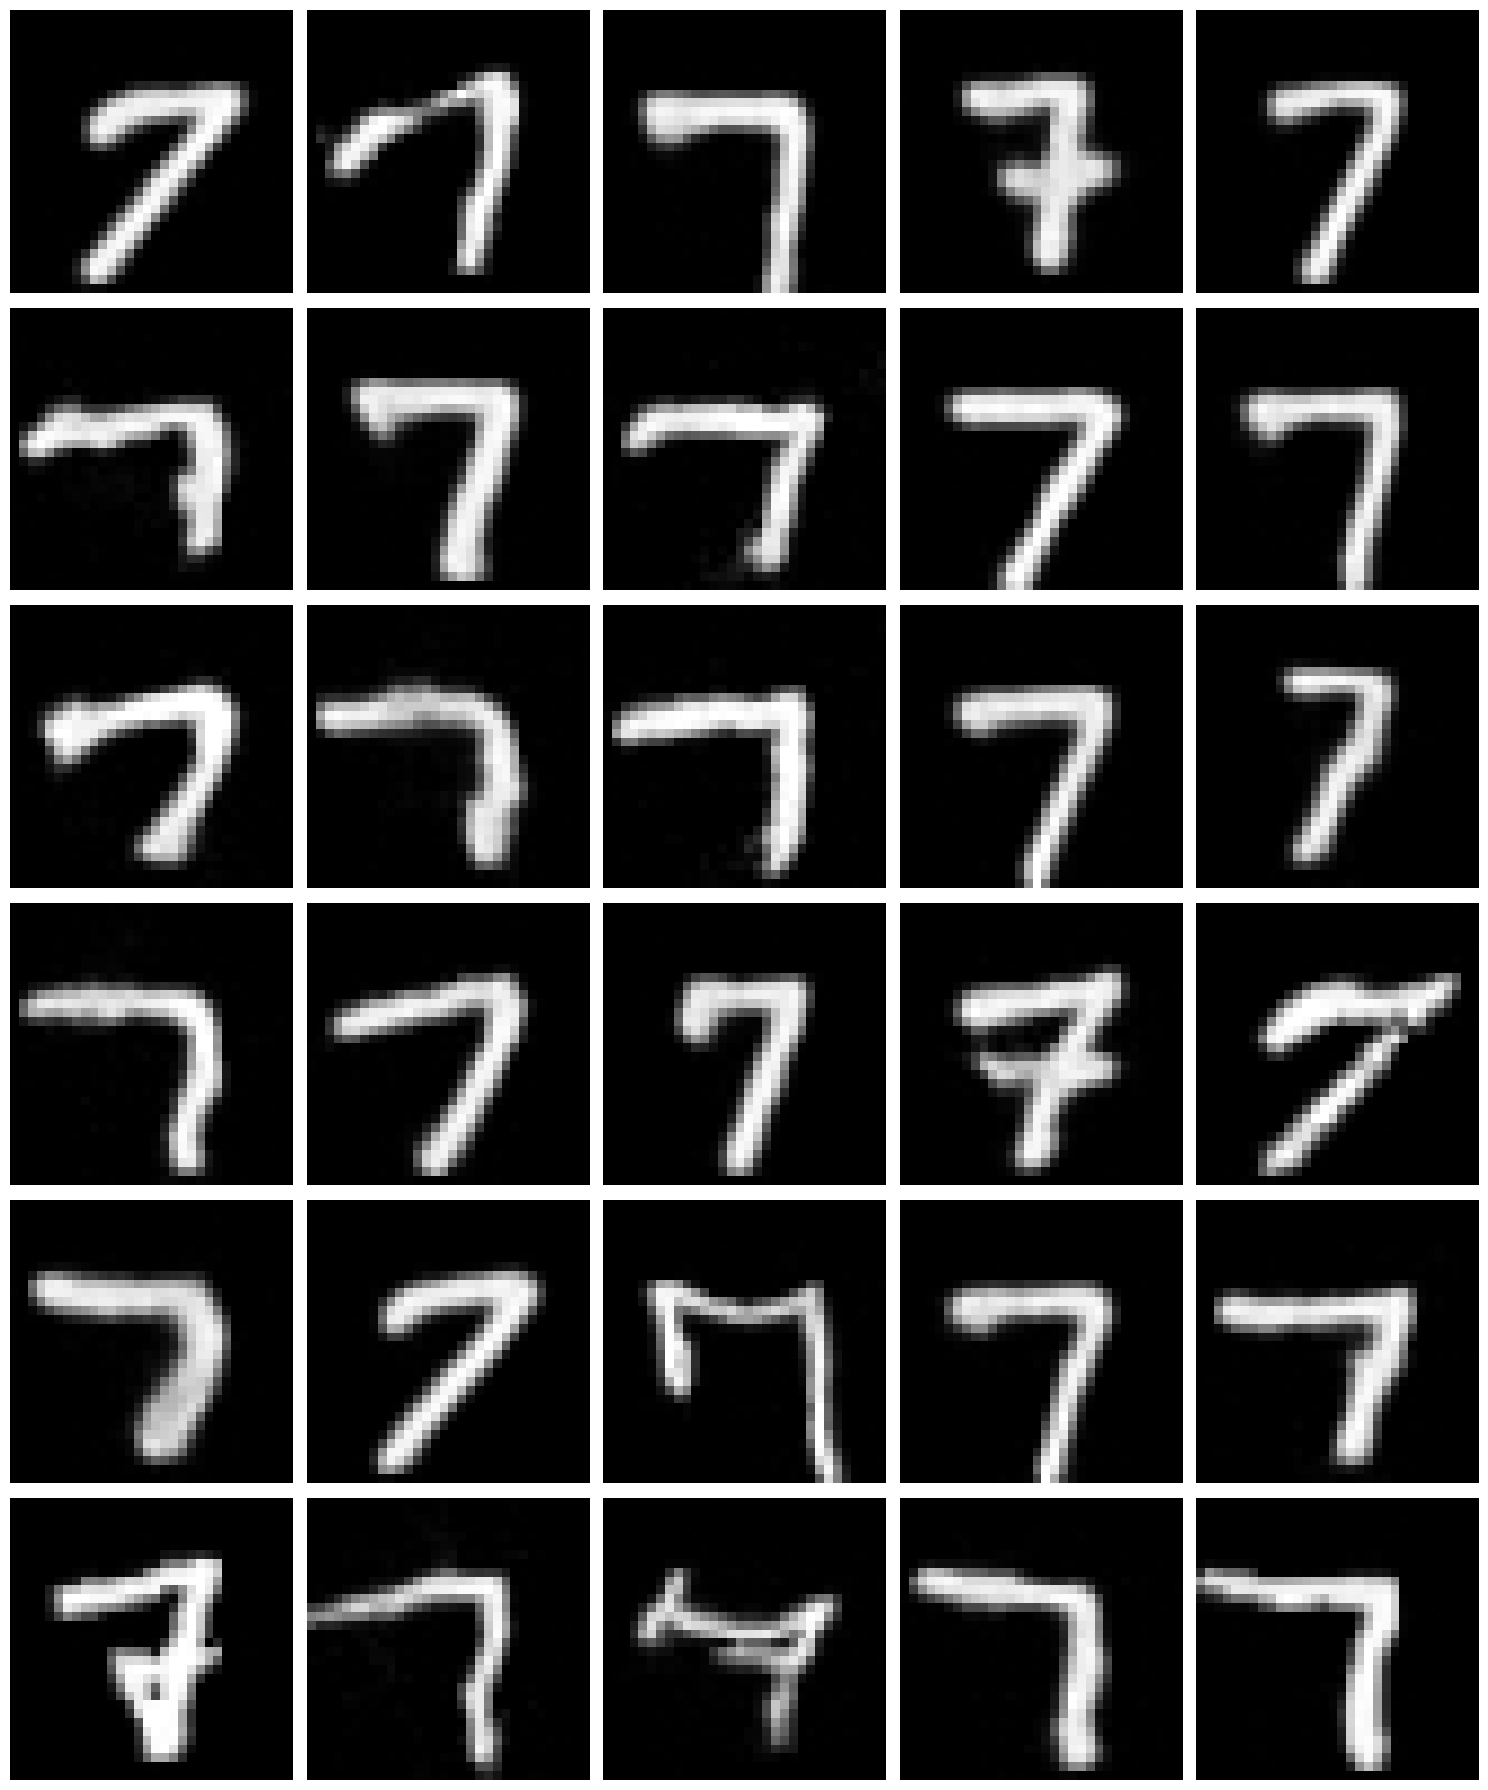

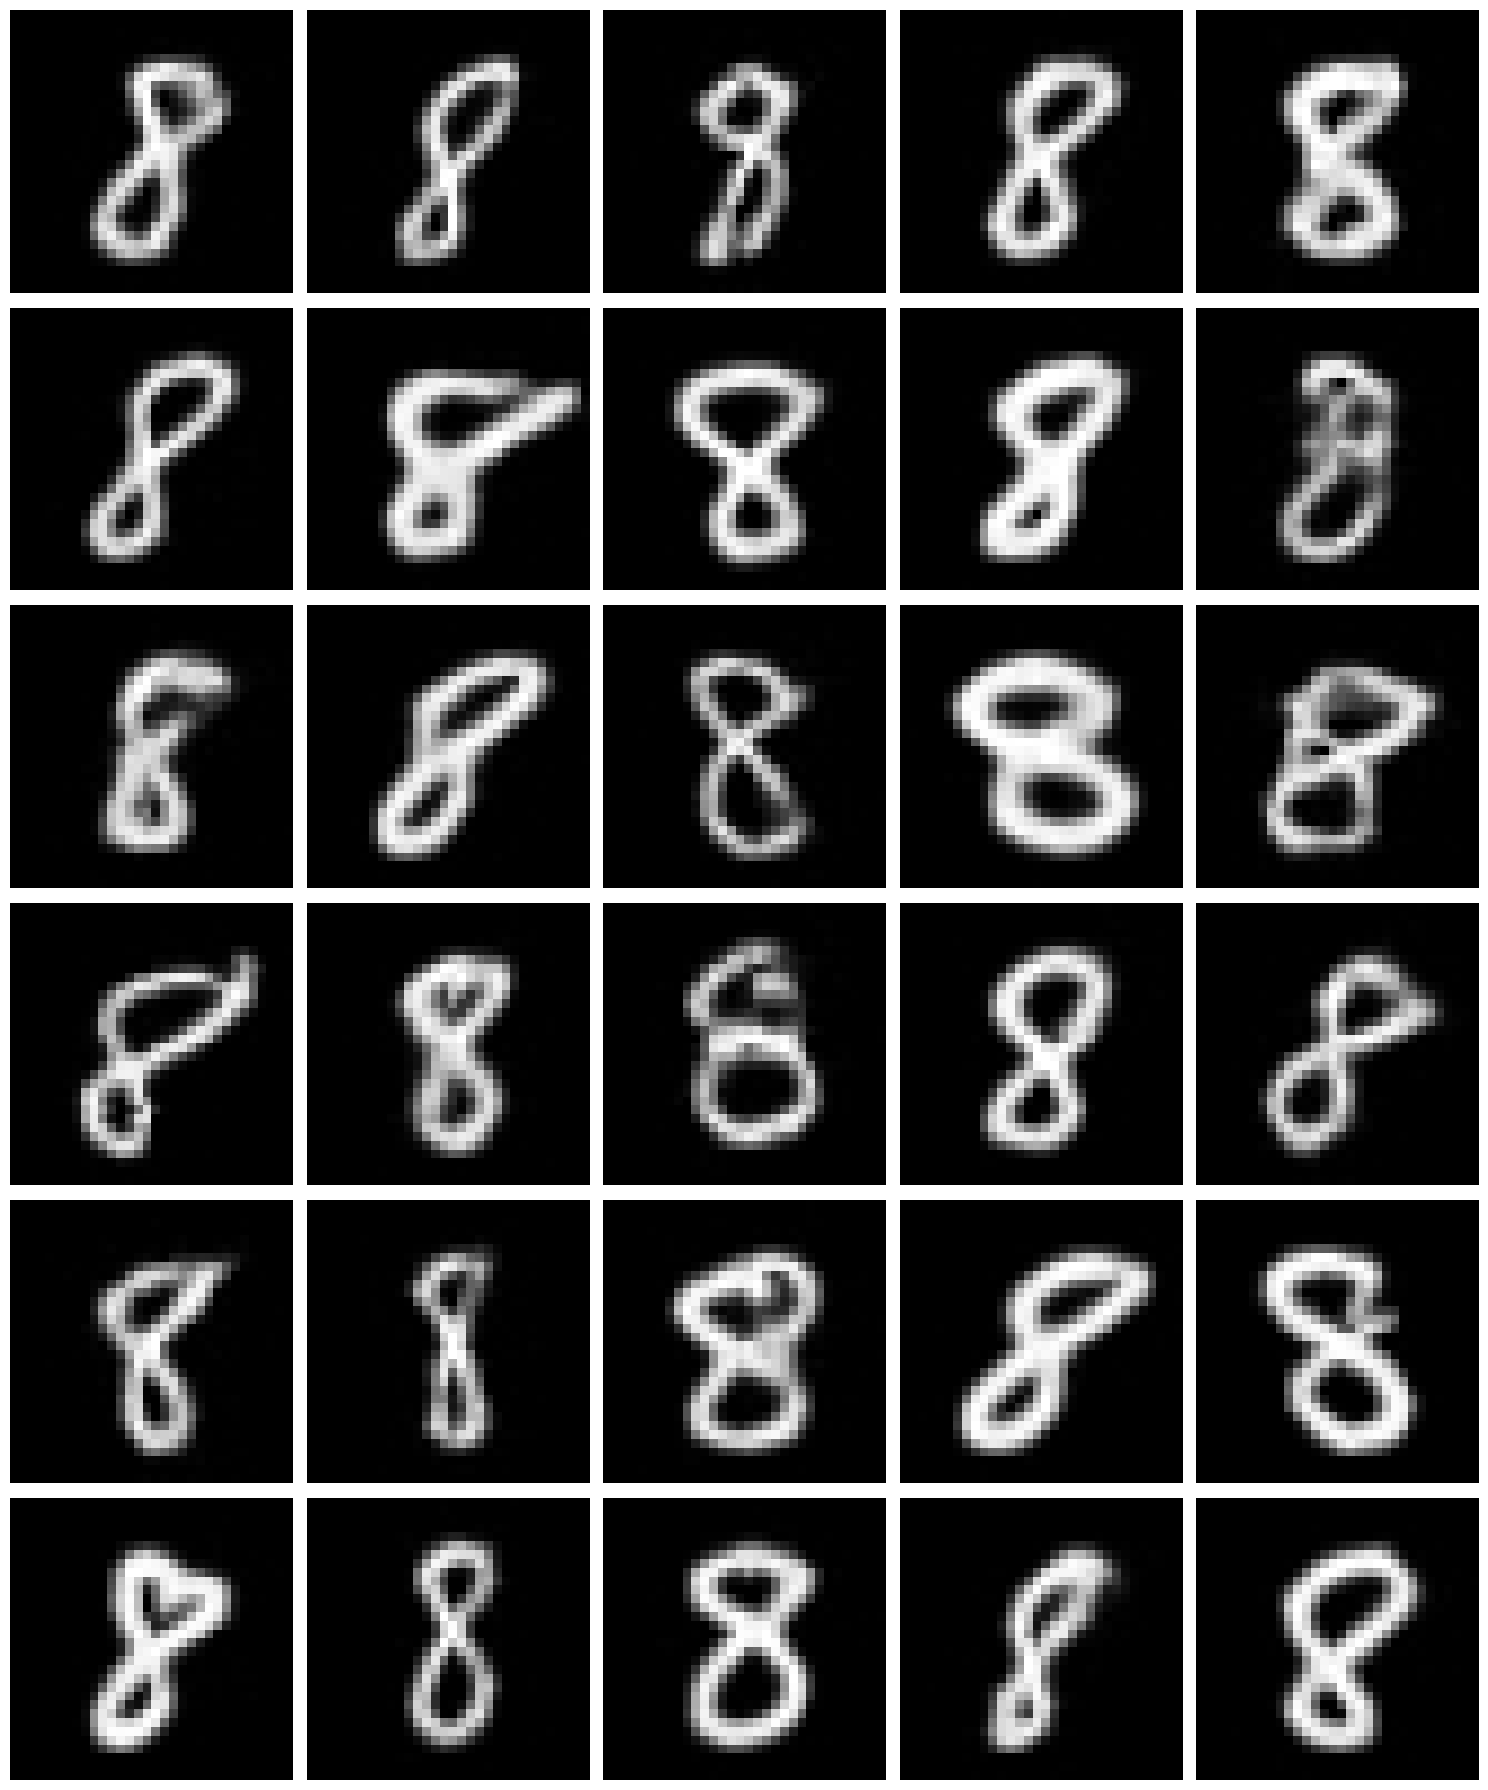

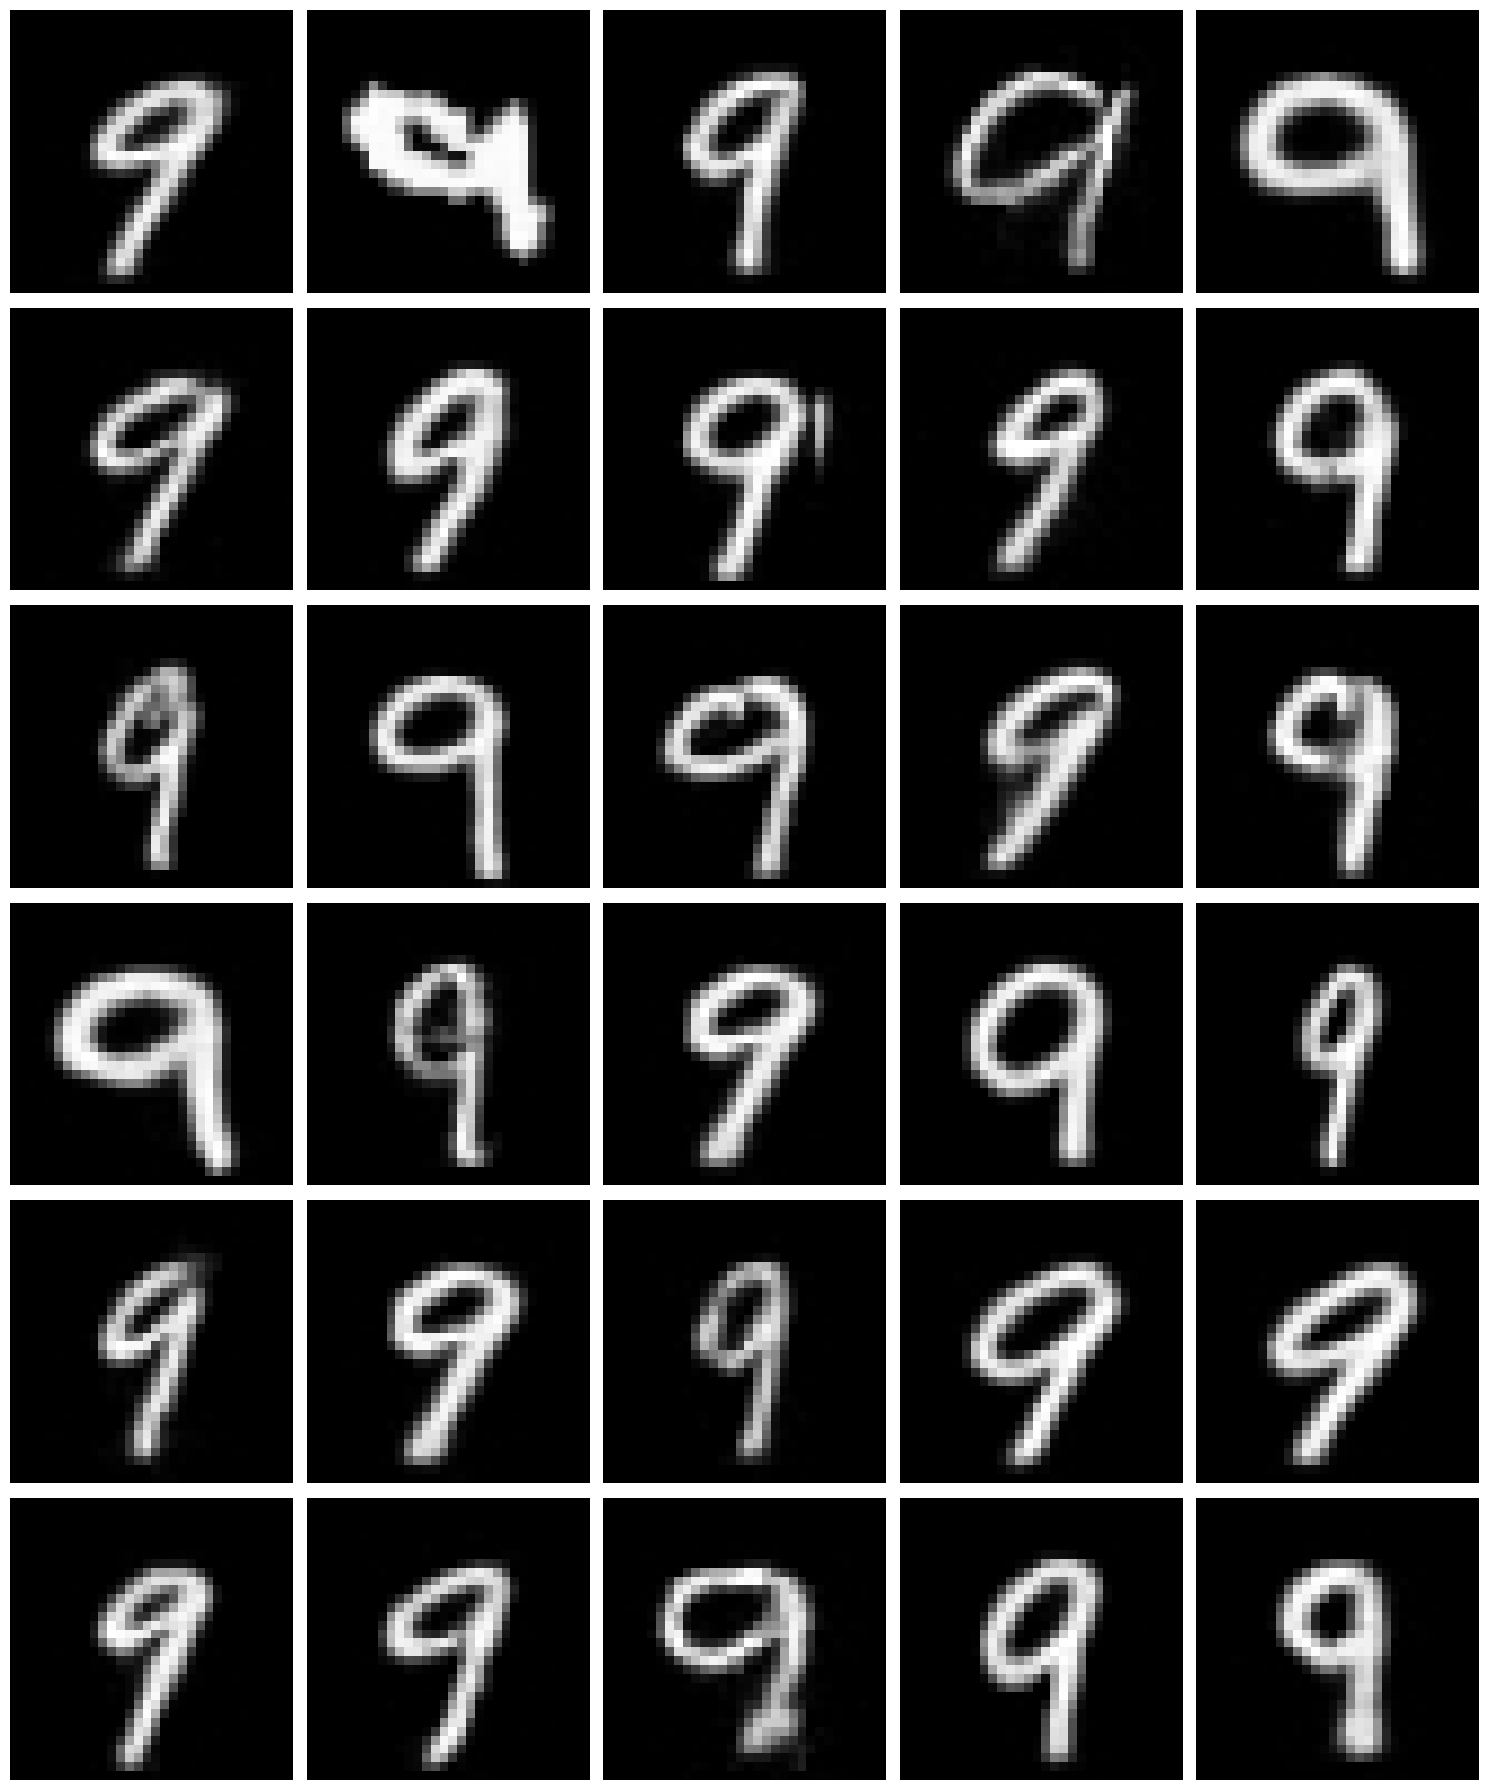

In [22]:
# visualize archetypes
num_vertical = n_archetypes // 5
for k in range(10):
    fig, axes = plt.subplots(num_vertical, 5, figsize=(15, 3 * num_vertical))
    axes = axes.flatten()
    for i in range(n_archetypes):
        axes[i].imshow(archetypes_supervised[k][i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i].axis('off') 
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder,f"archetype_{k}_phi_supervised.png"))
    plt.show()

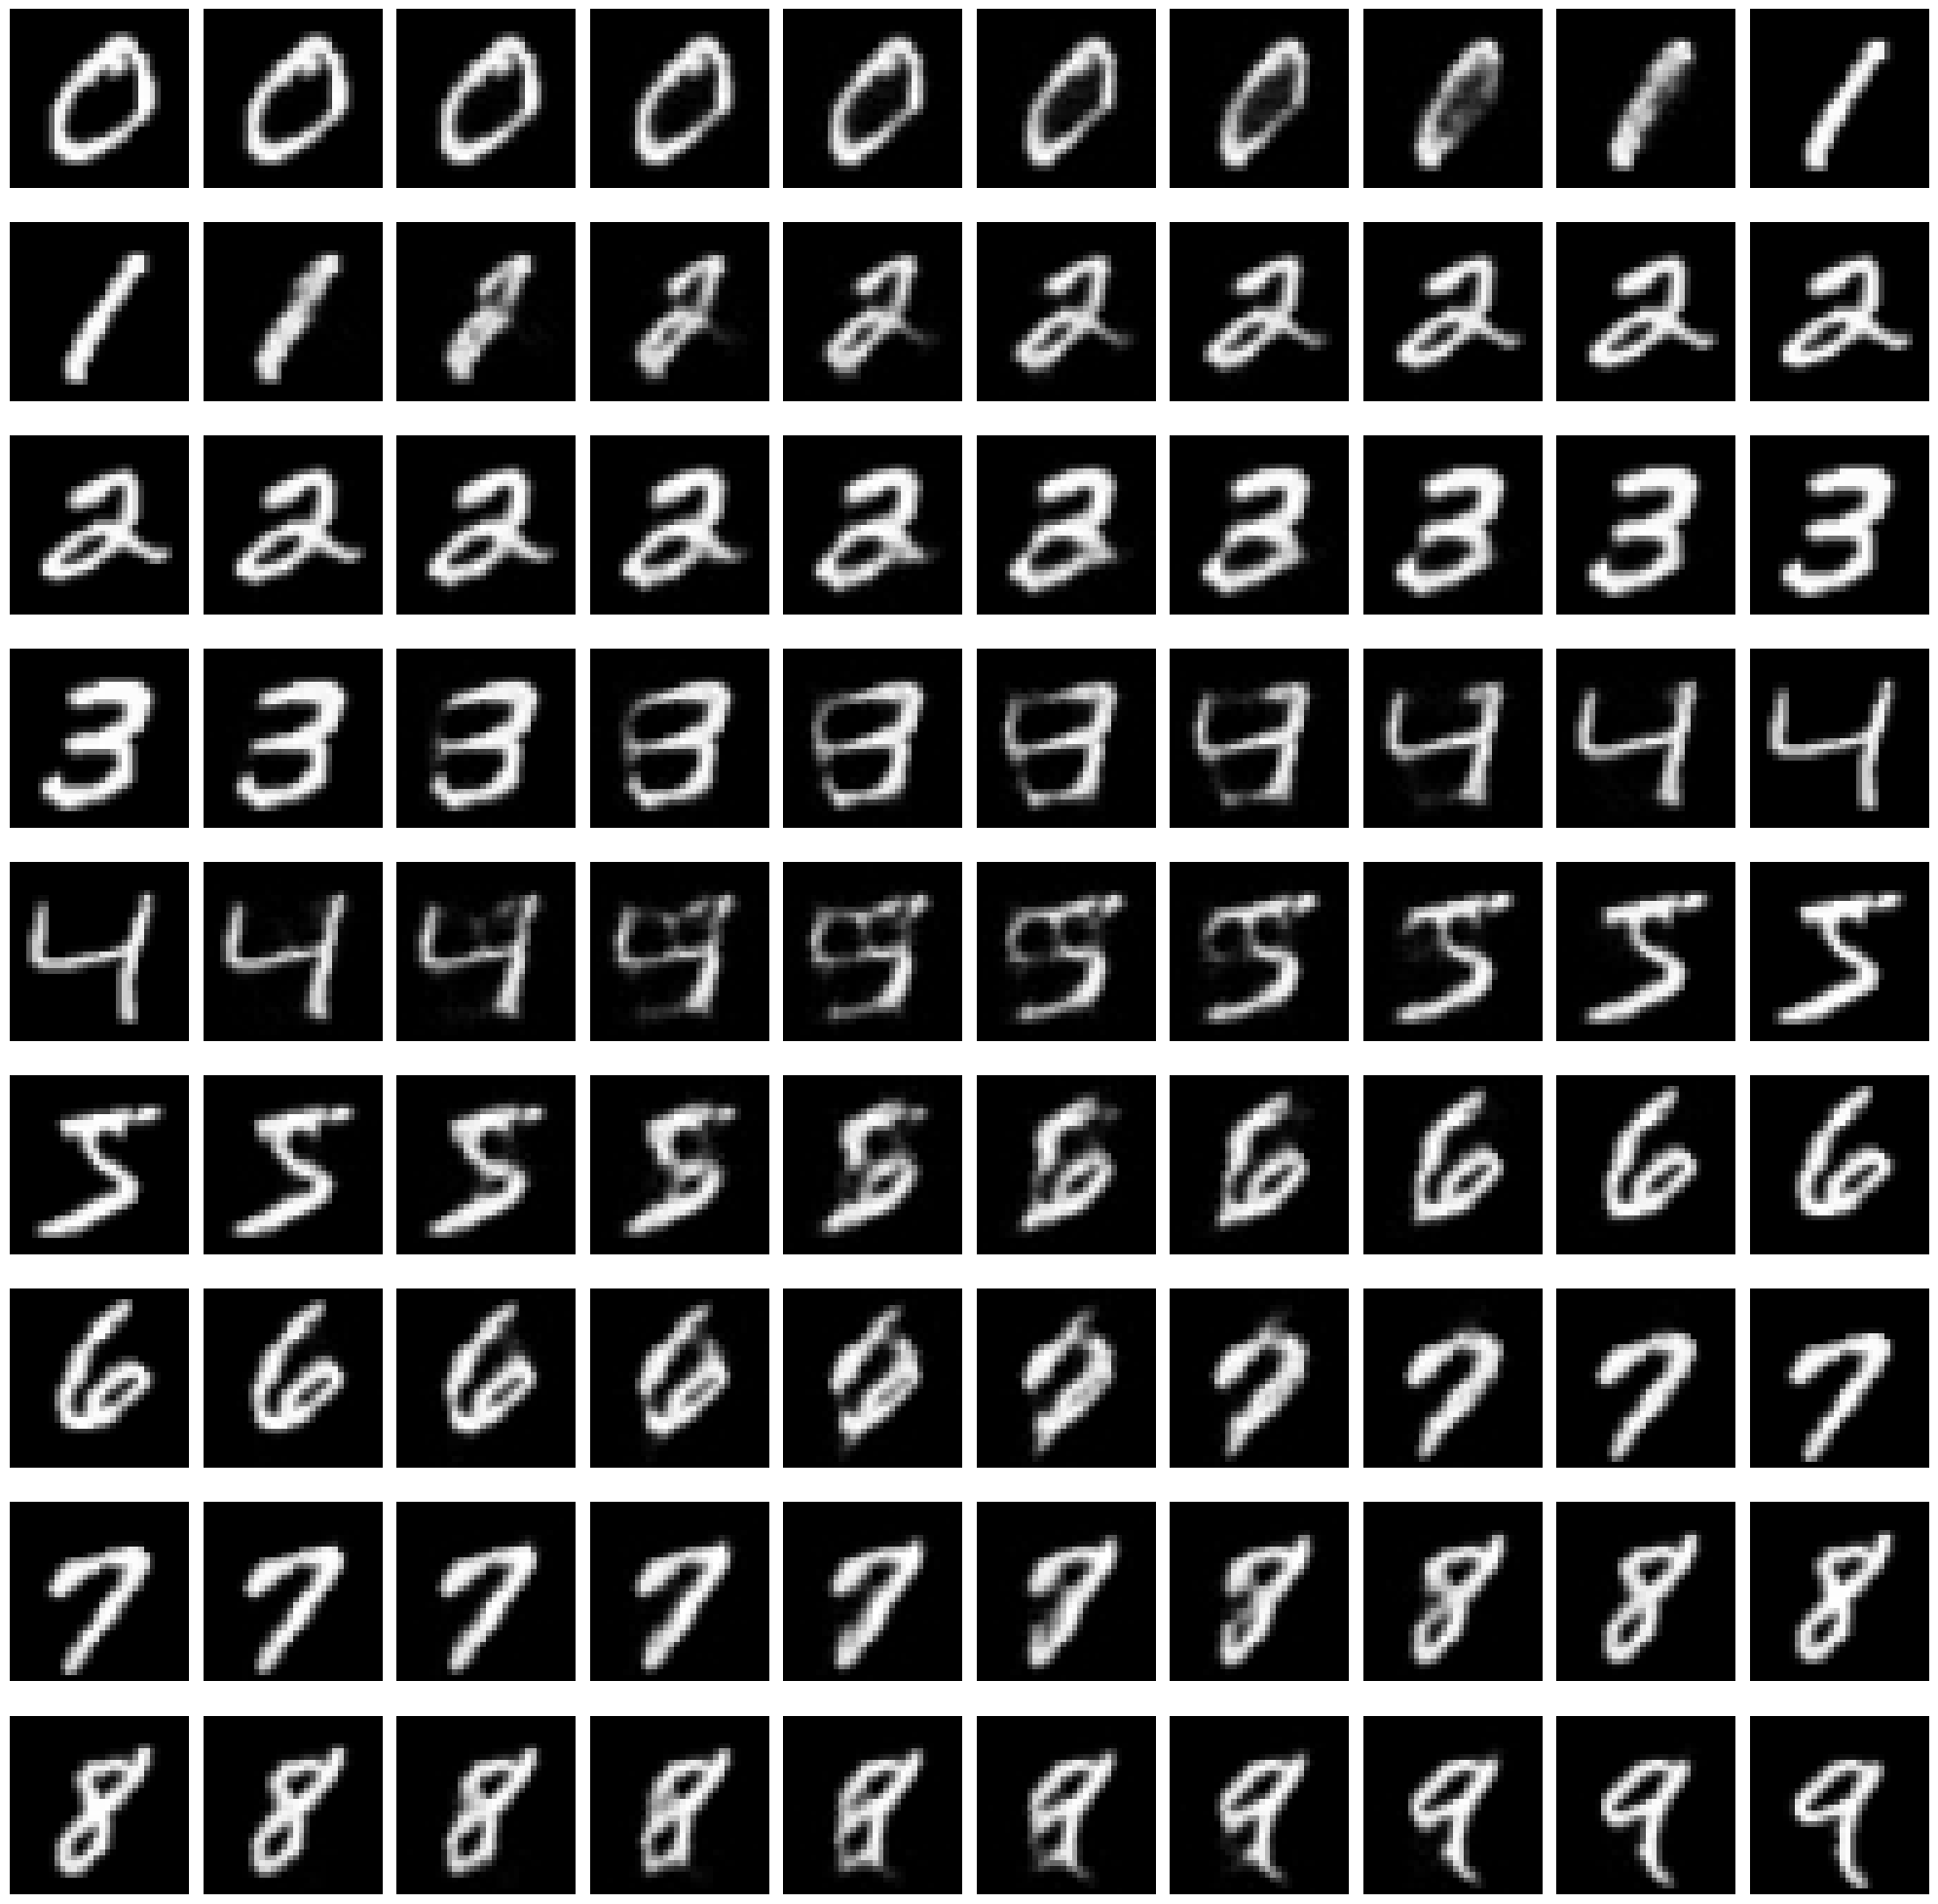

In [23]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    Omega_supervised_geodesics = Omega_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu() 

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(Omega_supervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_supervised.png"))
plt.show()

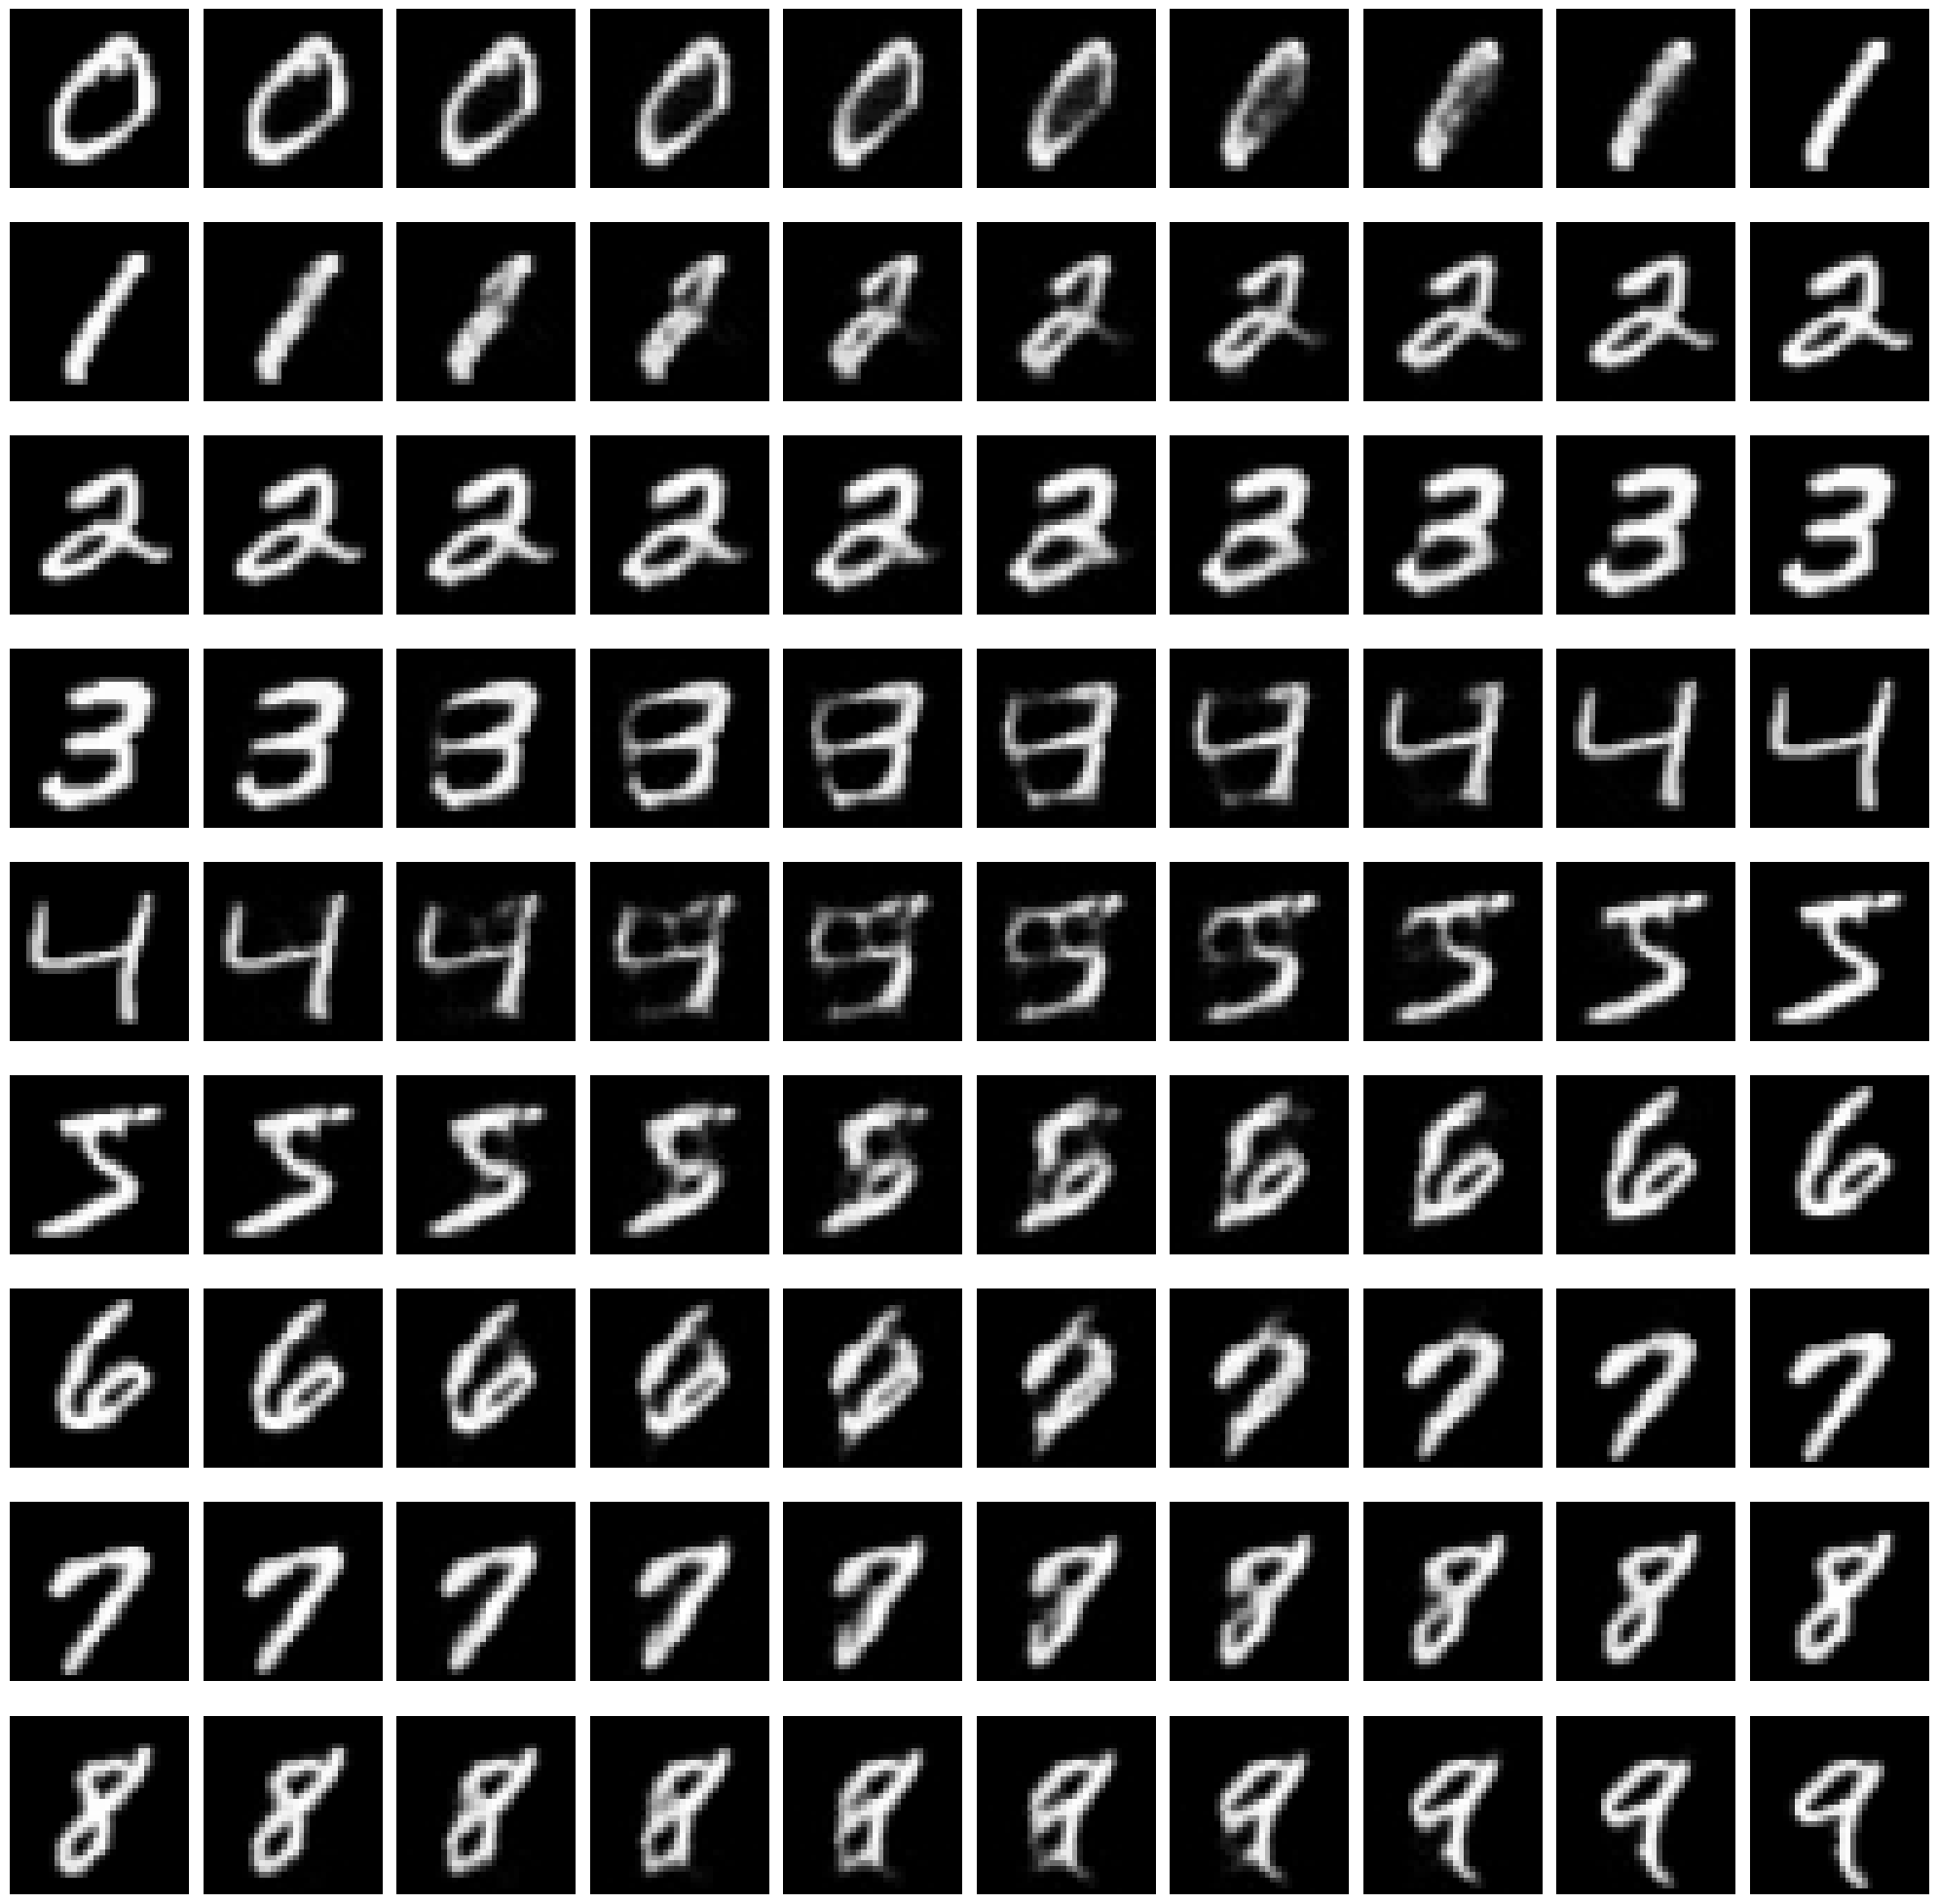

In [24]:
# compute iso geodesics between all pairs of points
with torch.no_grad():
    iso_Omega_supervised_geodesics = iso_Omega_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()

# plot iso-geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(iso_Omega_supervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_supervised_iso.png"))
plt.show()

In [25]:
# construct RAM
ram_supervised = RiemannianArchetypalMapping(Omega_manifold, torch.cat(archetypes_supervised, dim=0))
# ram_supervised = RiemannianArchetypalMapping(Omega_supervised_manifold, torch.stack(centers_supervised))

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/src/nn/module/riemannian/archetypal_mapping.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("pgd_step_tensor", torch.tensor(step, dtype=A.dtype, device=A.device))


In [26]:
# project clusters
with torch.no_grad():
    ram_supervised_projected_data_clusters = ram_supervised.forward(data_clusters.to(device))
    ram_supervised_projected_centers = ram_supervised.forward(torch.stack(centers_supervised).to(device))

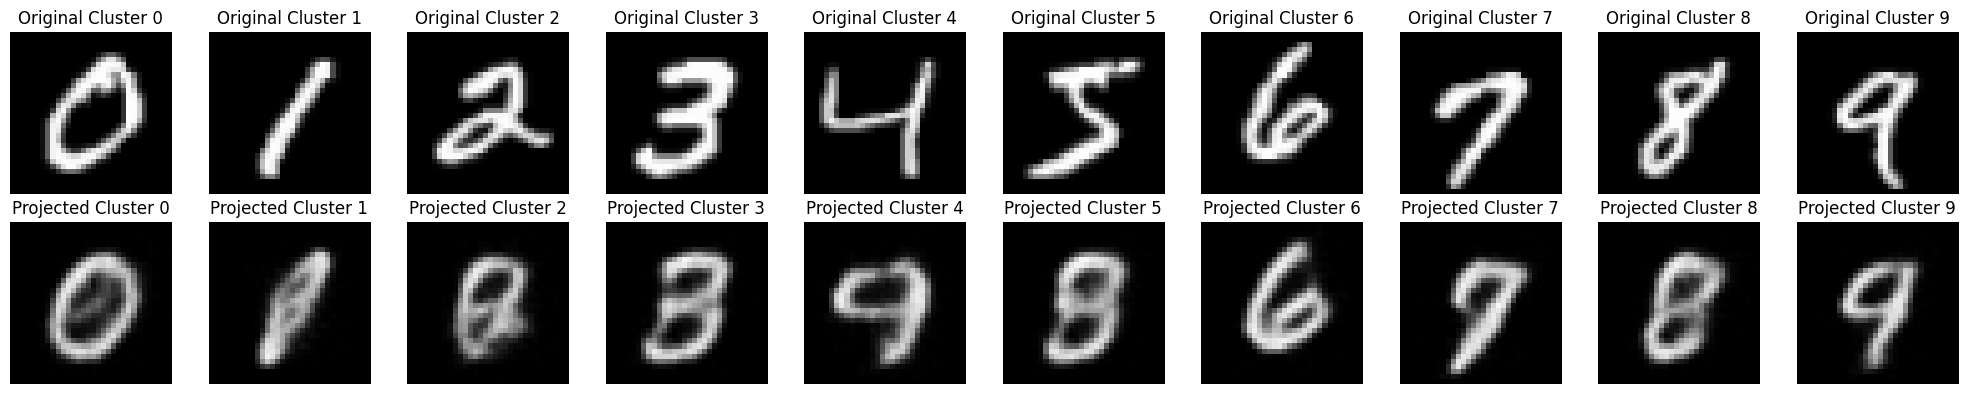

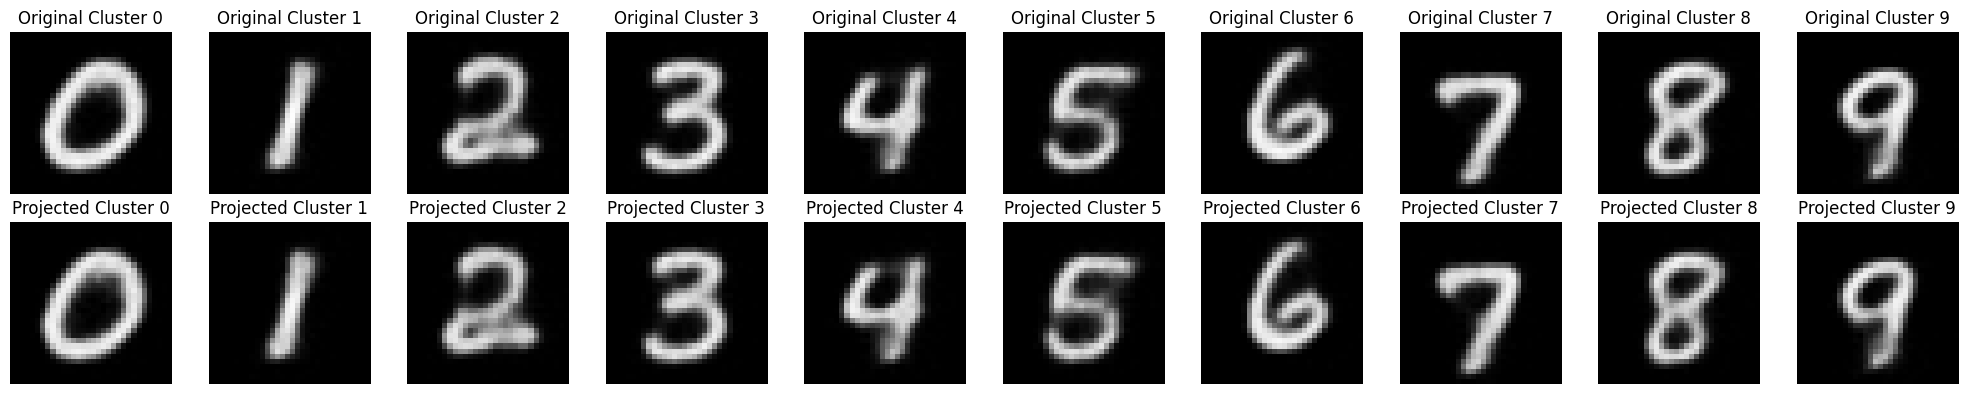

In [27]:
# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_supervised_projected_data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(centers_supervised[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_supervised_projected_centers[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [29]:
with torch.no_grad():
    weights = ram_supervised.w(data_clusters.to(device))

Weights = weights.reshape(10,10,n_archetypes)
Weights_sum = Weights.sum(dim=-1)
pred = Weights_sum.argmax(dim=-1)

print("W sum:", Weights_sum)
print("Predicted labels:", pred)

W sum: tensor([[4.2215e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.1000e-01, 1.6412e-01,
         4.6157e-02, 2.9974e-02, 1.8456e-01, 4.3039e-02],
        [2.6699e-02, 6.8517e-01, 0.0000e+00, 3.5151e-02, 5.1090e-02, 2.4435e-05,
         4.5648e-02, 1.4978e-02, 7.6576e-02, 6.4661e-02],
        [1.8082e-02, 0.0000e+00, 2.3812e-01, 5.0702e-02, 4.6153e-02, 1.1308e-01,
         2.0896e-02, 3.3215e-02, 1.4740e-01, 3.3236e-01],
        [1.2258e-01, 2.8988e-02, 3.7928e-02, 5.0051e-01, 8.2794e-02, 0.0000e+00,
         4.5428e-02, 1.5367e-02, 1.2243e-01, 4.3972e-02],
        [3.6652e-02, 0.0000e+00, 0.0000e+00, 1.8475e-02, 4.4079e-01, 0.0000e+00,
         7.9312e-02, 3.1291e-01, 3.0643e-02, 8.1212e-02],
        [1.0296e-01, 0.0000e+00, 1.3478e-02, 3.1066e-01, 9.2290e-02, 7.5588e-02,
         6.7835e-02, 3.1009e-02, 2.6289e-01, 4.3292e-02],
        [2.2731e-02, 0.0000e+00, 8.7492e-02, 8.6540e-03, 6.6310e-02, 0.0000e+00,
         6.1732e-01, 0.0000e+00, 5.9572e-02, 1.3792e-01],
        [1.3475e-02,

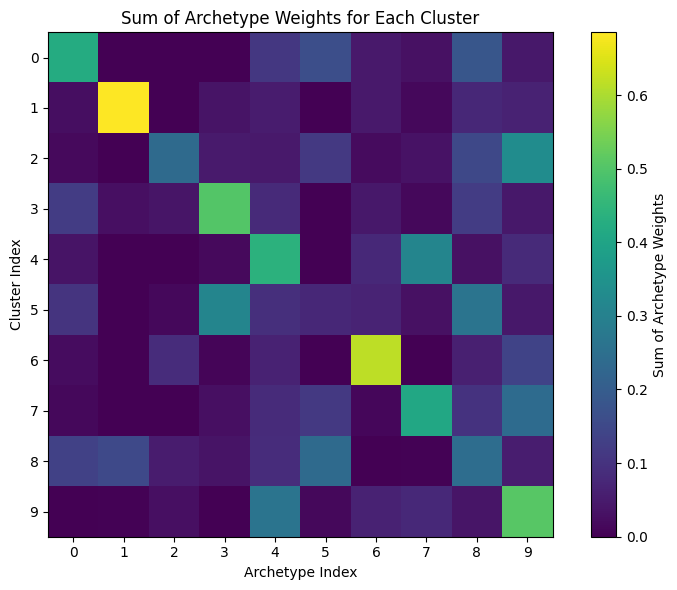

In [30]:
# plot preed matrix
plt.figure(figsize=(8, 6))
plt.imshow(Weights_sum, cmap='viridis')
plt.colorbar(label='Sum of Archetype Weights')
plt.xlabel('Archetype Index')
plt.ylabel('Cluster Index')
plt.title('Sum of Archetype Weights for Each Cluster')
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
# plt.savefig(os.path.join(results_folder,"weights_sum.png"))
plt.show()

### Unsupervised ###

In [ ]:
# construct archetypes
n_clusters = 100

N_max = 5000 # max number of samples to use for archetype construction to save time

archetypes_unsupervised = []
phi_archetypes_unsupervised = []
print(f"Constructing clusters with {N_max} samples")
aa = AA(n_clusters, init='furthest_sum')
aa.fit(phi_data_train.reshape(-1, size * size)[:N_max]) # use subset of data for archetype construction to save time

Constructing clusters with 5000 samples


,n_archetypes,20
,max_iter,300
,tol,0.0001
,init,'furthest_sum'
,n_init,1
,init_params,None
,save_init,False
,method,'pgd'
,method_params,None
,verbose,False
,random_state,None


In [ ]:
# get labels from 
print("Assigning labels to training data based on closest archetype")
labels_train_unsupervised = torch.zeros(phi_data_train.shape[0], dtype=torch.long)
i = 0
with torch.no_grad():
    for x in tqdm(train_loader):
        # x = x.to(device, non_blocking=True)
        b = x.size(0)                      # actual batch size
        labels_train_unsupervised[i:i+b] = torch.from_numpy(aa.transform(phi_data_train.reshape(-1, size * size)[i:i+b]).argmax(axis=1))
        i += b

print(len(torch.unique(labels_train_unsupervised)) == n_clusters)

Assigning labels to training data based on closest archetype


100%|██████████| 375/375 [00:00<00:00, 386.80it/s]

True


In [ ]:
# construct centers
centers_unsupervised = []
phi_centers_unsupervised = []
for label in torch.unique(labels_train_unsupervised):
    phi_center = phi_data_train[torch.tensor(labels_train_unsupervised) == label].mean(dim=0)
    phi_centers_unsupervised.append(phi_center.reshape(size * size))
    with torch.no_grad():
        center = phi.inverse(phi_center.to(device)[None]).cpu()[0]
    centers_unsupervised.append(center)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_20947/3056724957.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_center = phi_data_train[torch.tensor(labels_train_unsupervised) == label].mean(dim=0)


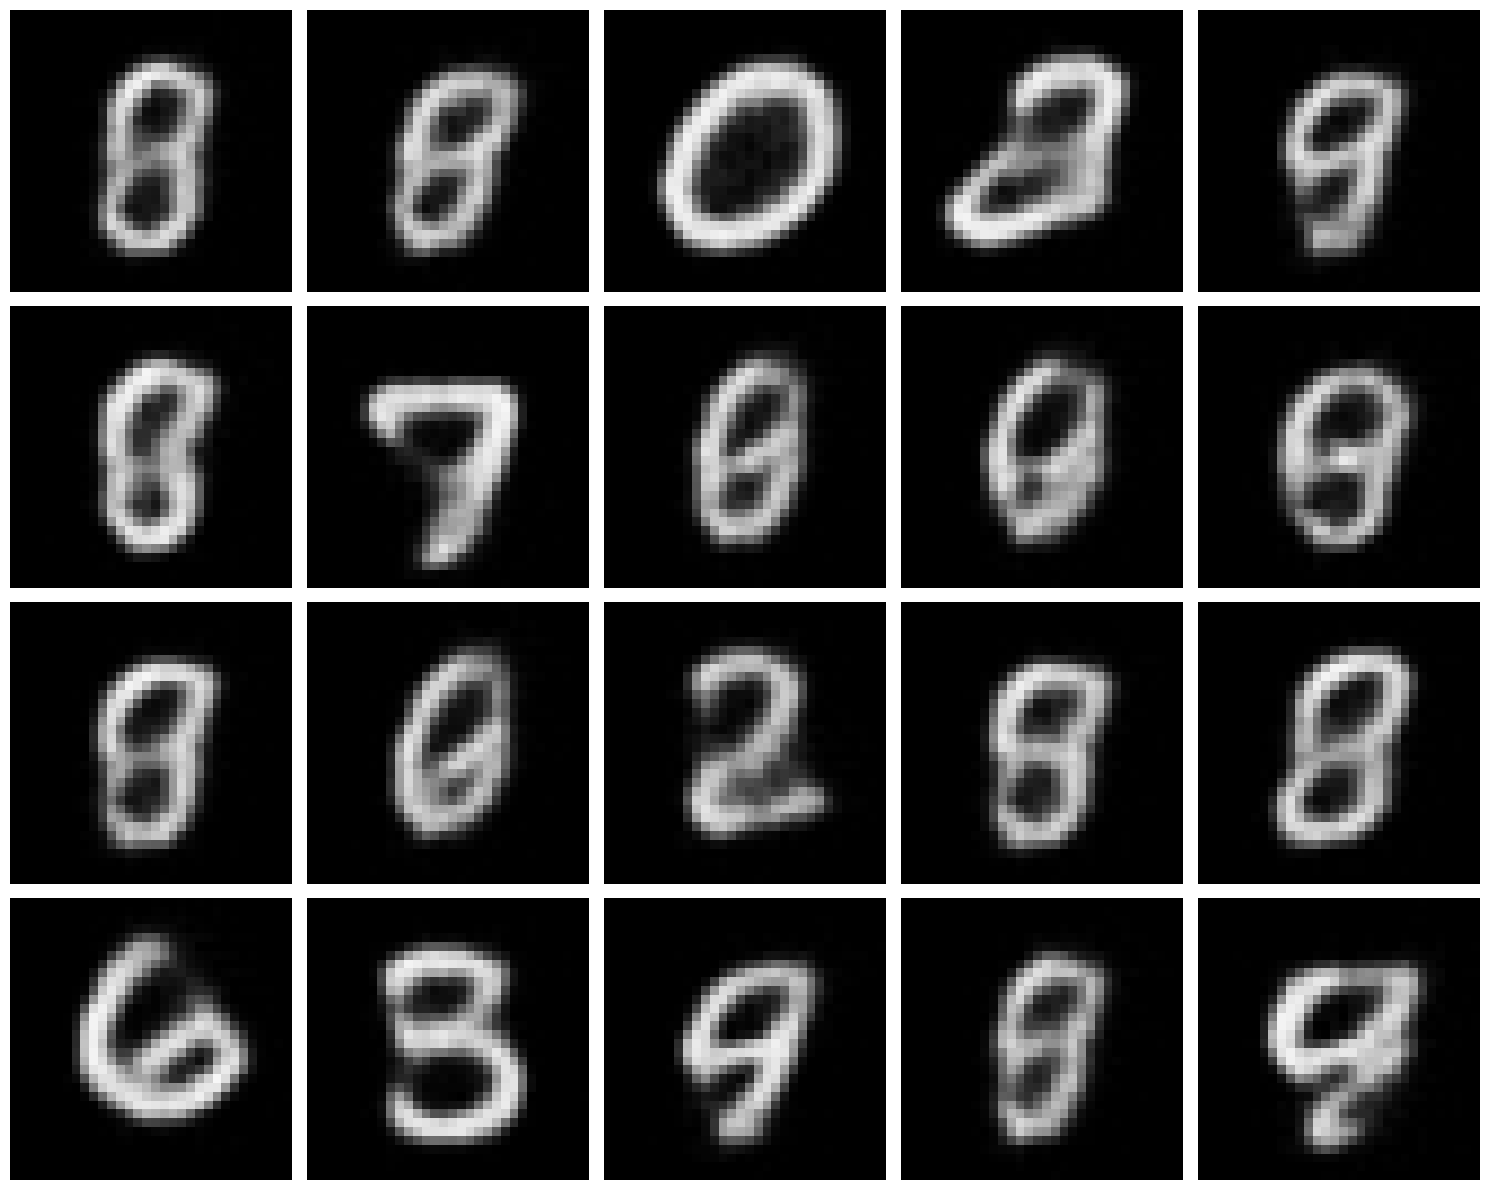

In [ ]:
# visualize cluster centers
num_vertical = n_clusters // 5
fig, axes = plt.subplots(num_vertical, 5, figsize=(15, 3 * num_vertical))
axes = axes.flatten()
for k in range(n_clusters):
    axes[k].imshow(centers_unsupervised[k].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[k].axis('off') 
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"barycentres_phi_unsupervised.png"))
plt.show()

In [ ]:
# construct archetypes
n_archetypes = 10

archetypes_unsupervised = []
phi_archetypes_unsupervised = []
for label in torch.unique(labels_train_unsupervised):
    phi_data_train_label_unsupervised = phi_data_train[torch.tensor(labels_train_unsupervised) == label].reshape(-1, size * size)
    if phi_data_train_label_unsupervised.shape[0] <= n_archetypes:
        print(f"Skipping label {label} with {phi_data_train_label_unsupervised.shape[0]} samples")
        continue
    print(f"Constructing archetypes for label {label} with {phi_data_train_label_unsupervised.shape[0]} samples")
    aa = AA(n_archetypes, init='furthest_sum')
    aa.fit(phi_data_train_label_unsupervised)
    with torch.no_grad():
        archetypes_label = phi.inverse(torch.from_numpy(aa.archetypes_).to(device).reshape(n_archetypes, 1, H, W)).cpu()
    archetypes_unsupervised.append(archetypes_label)
    phi_archetypes_unsupervised.append(torch.from_numpy(aa.archetypes_))

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_20947/2402471572.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi_data_train_label_unsupervised = phi_data_train[torch.tensor(labels_train_unsupervised) == label].reshape(-1, size * size)


Constructing archetypes for label 0 with 1144 samples


TypeError: reshape(): argument 'shape' failed to unpack the object at pos 4 with error "type must be tuple of ints,but got Tensor"

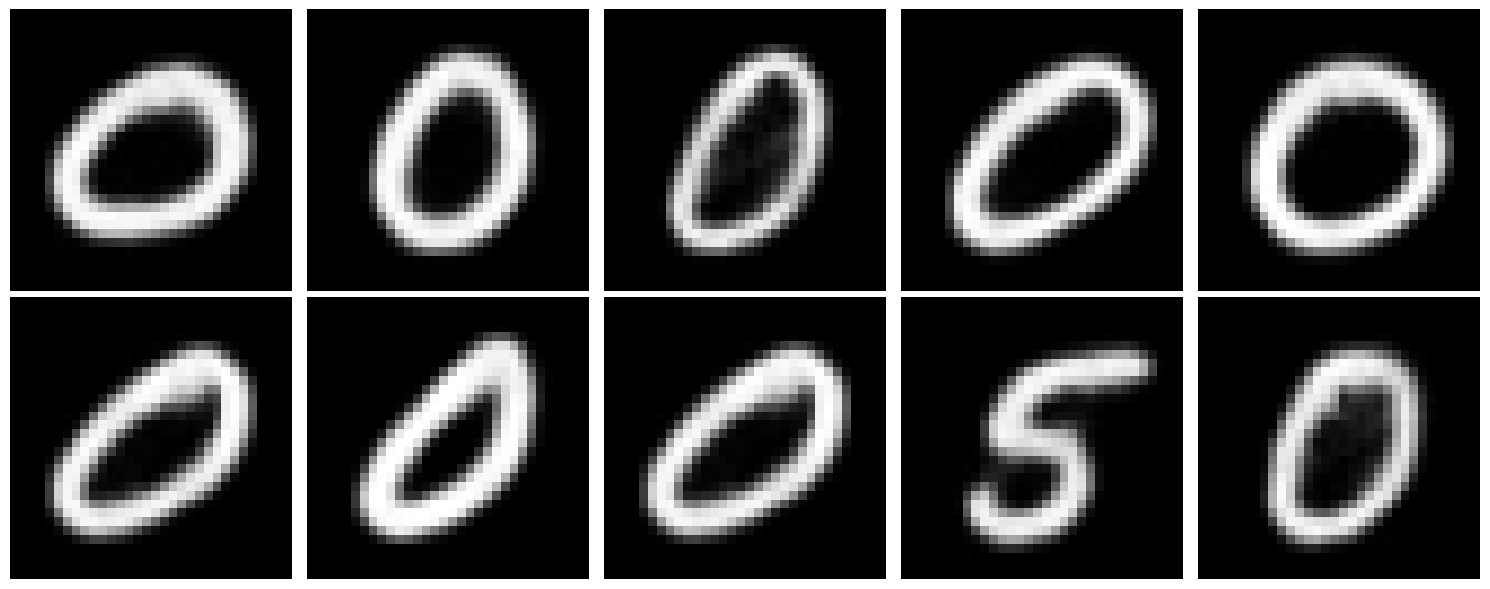

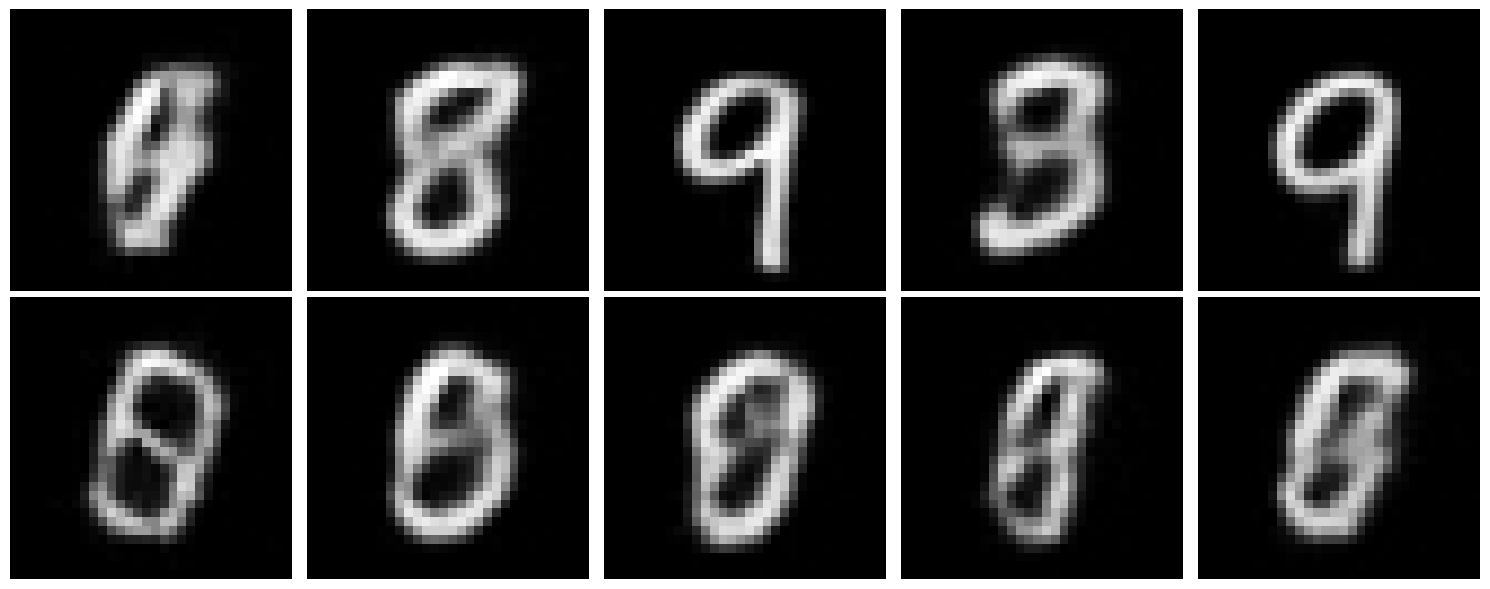

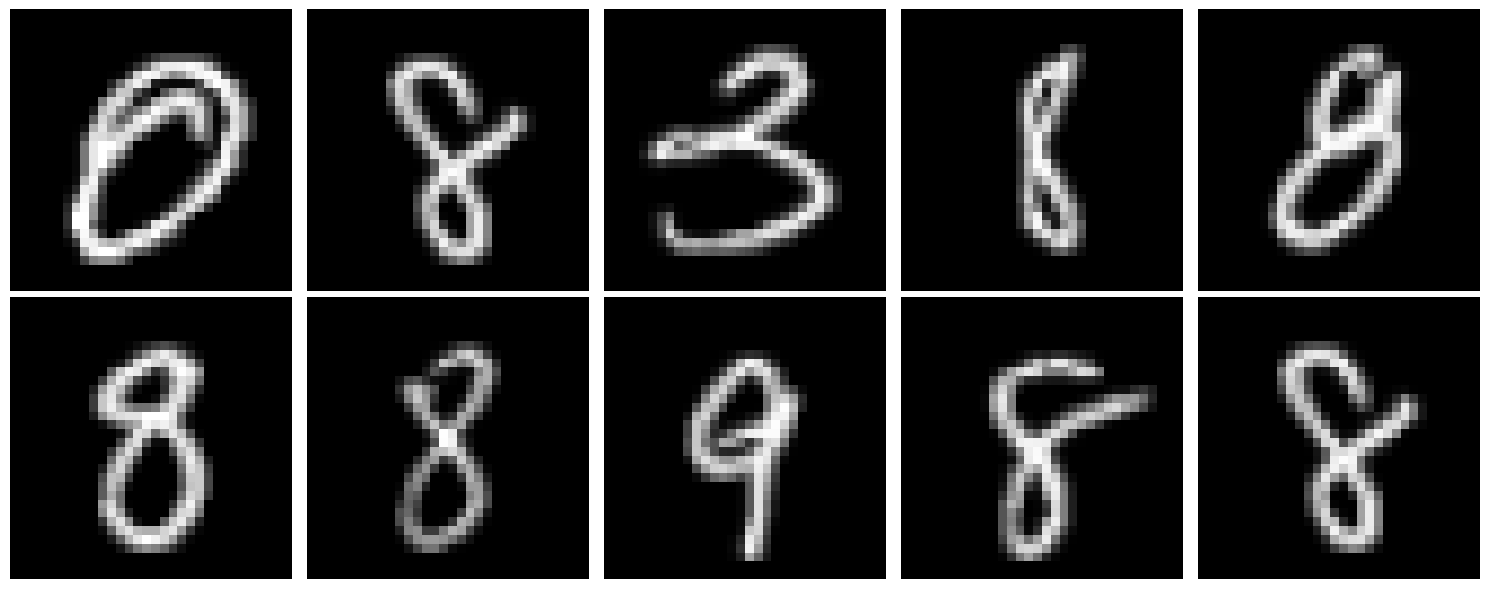

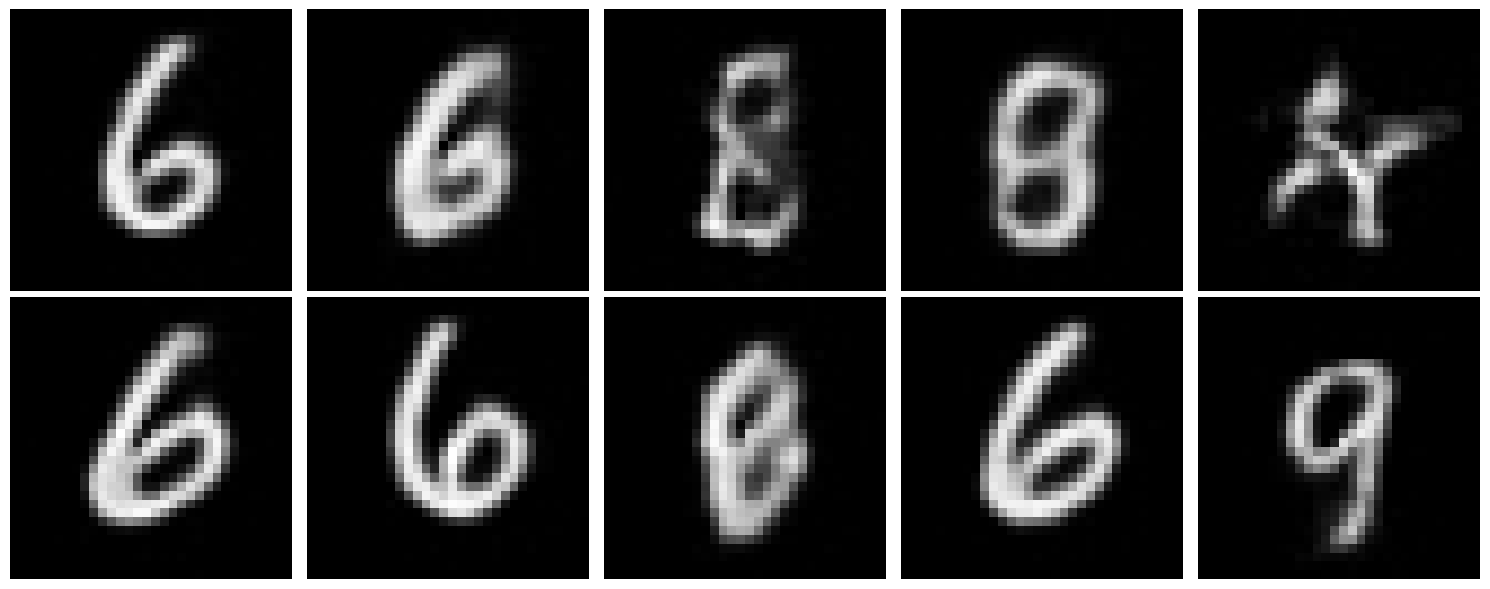

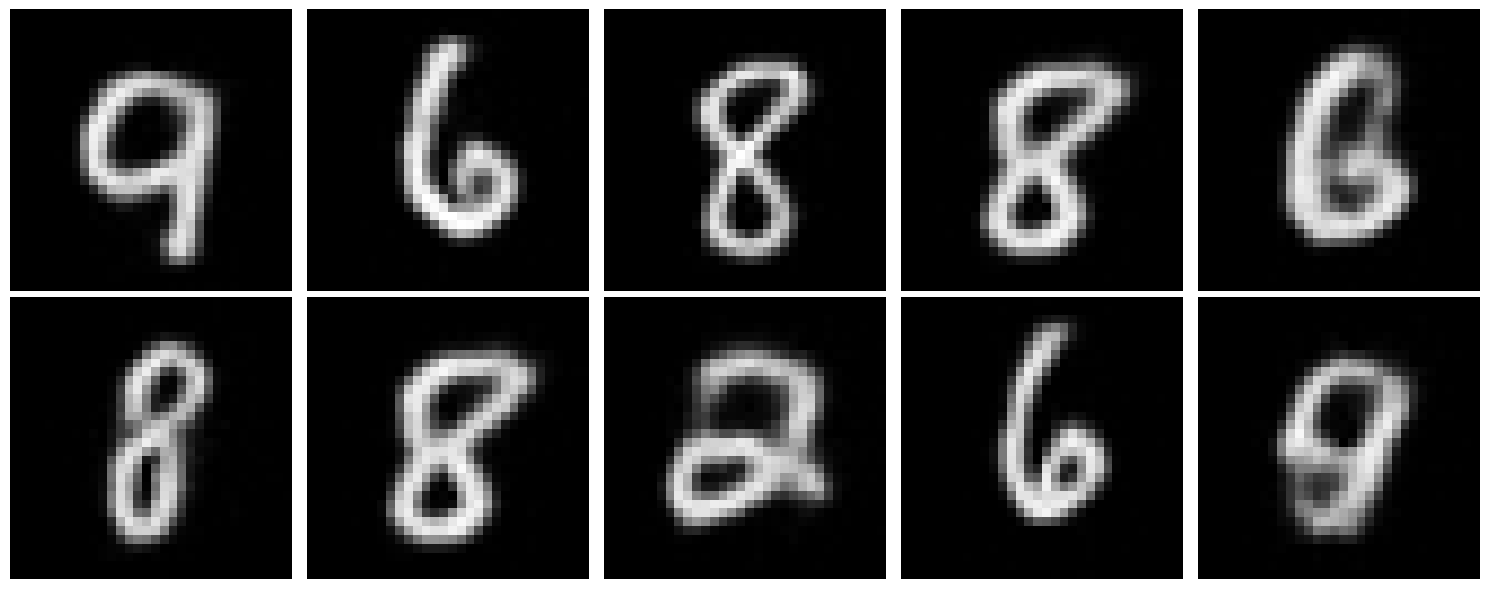

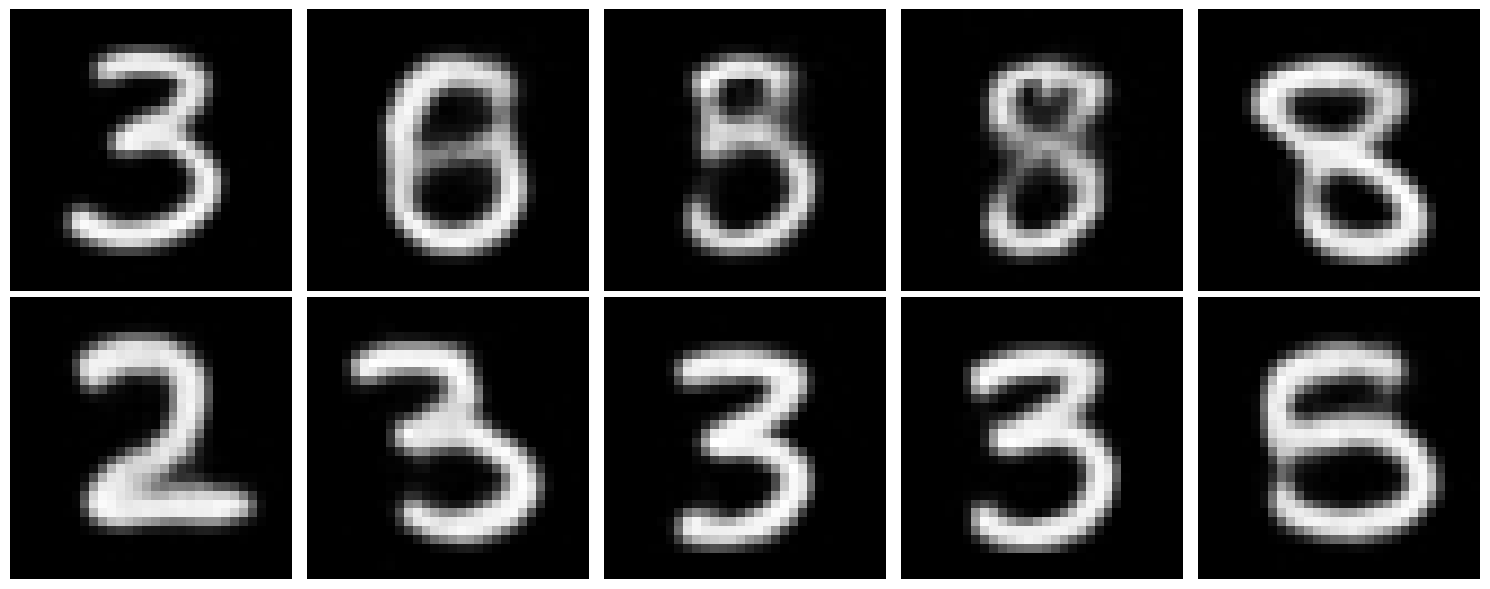

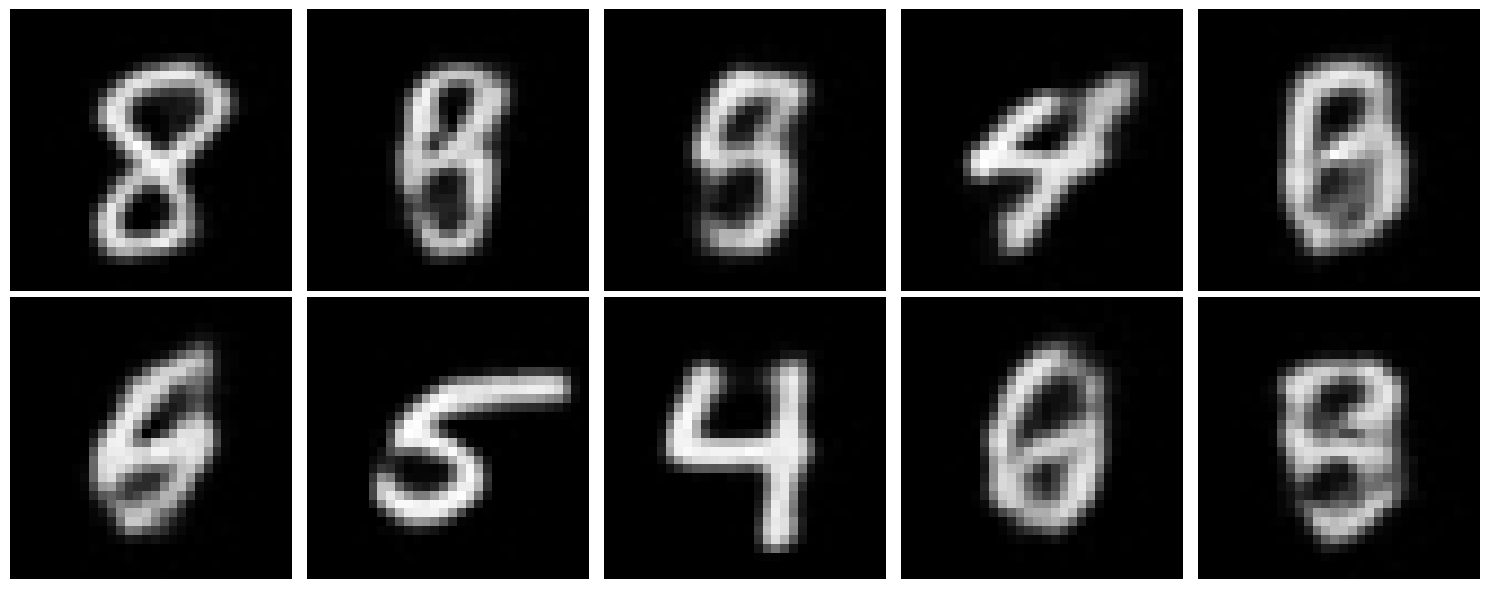

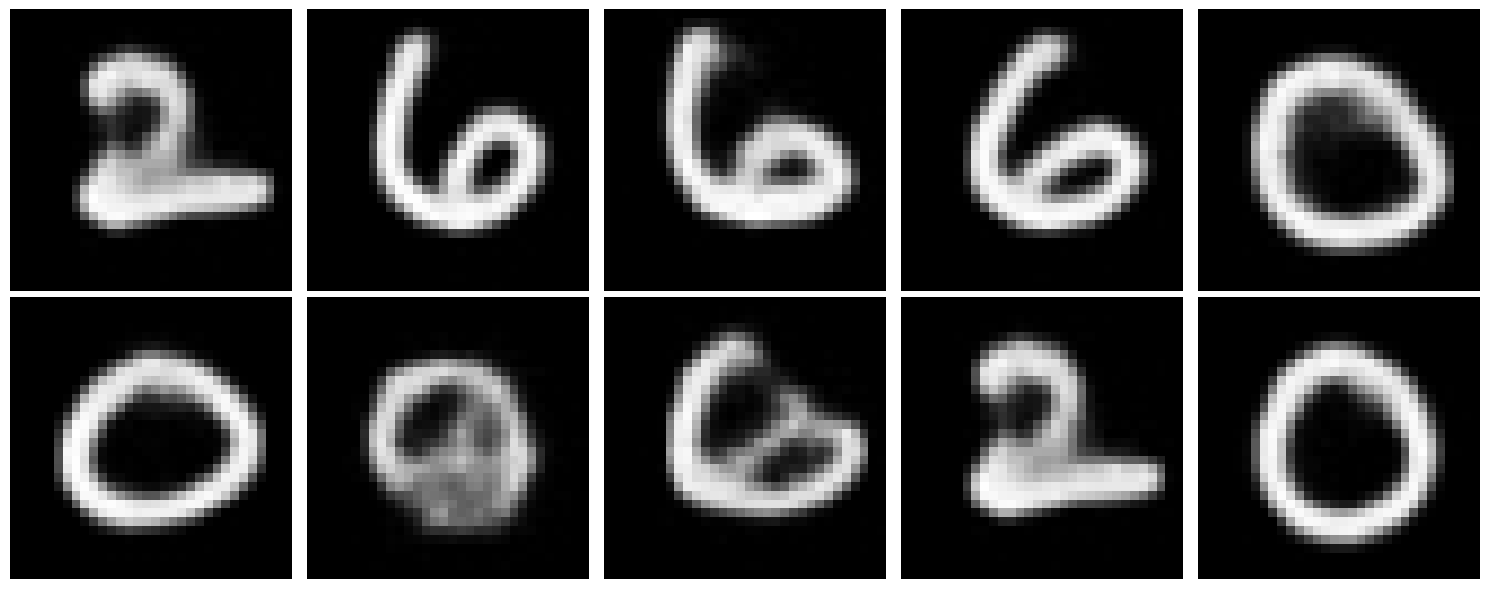

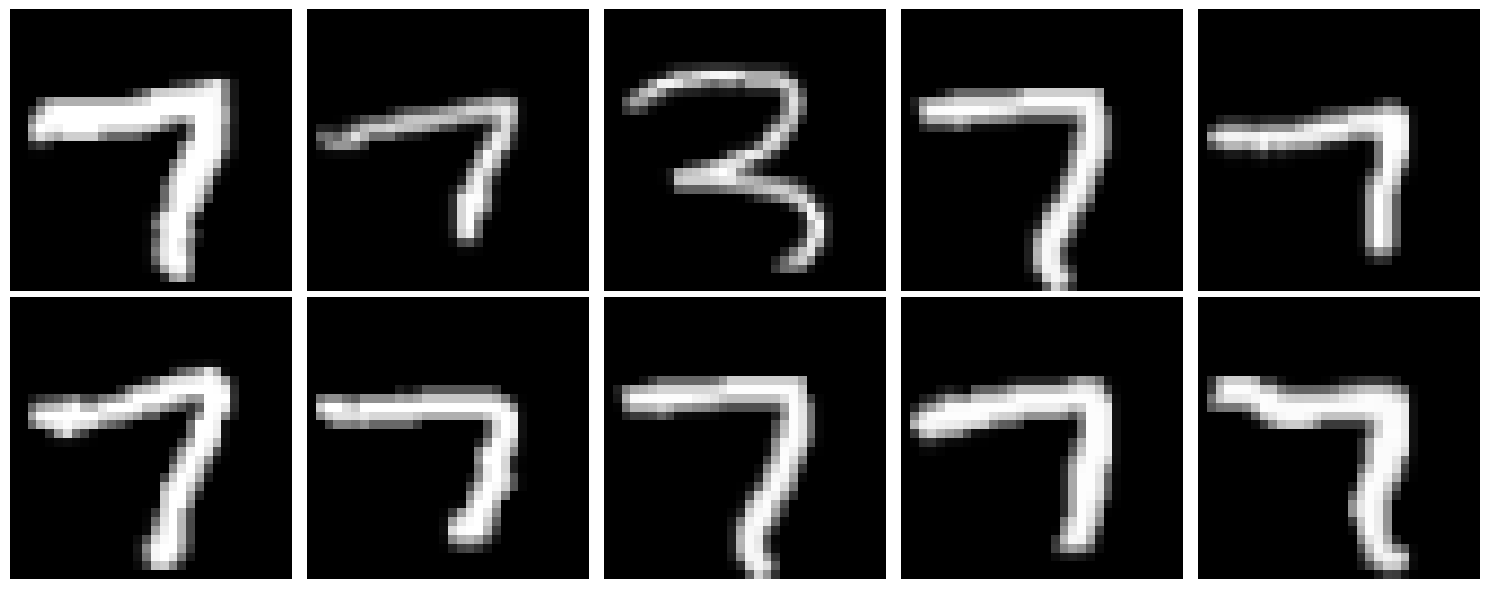

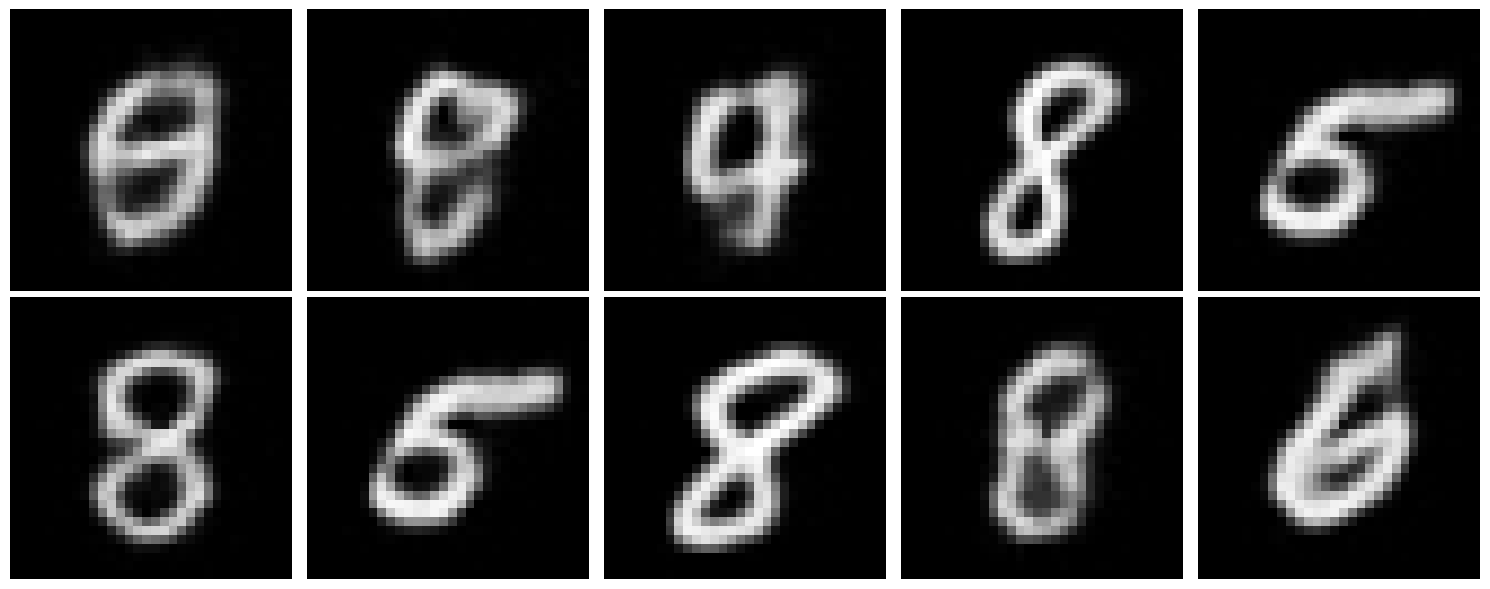

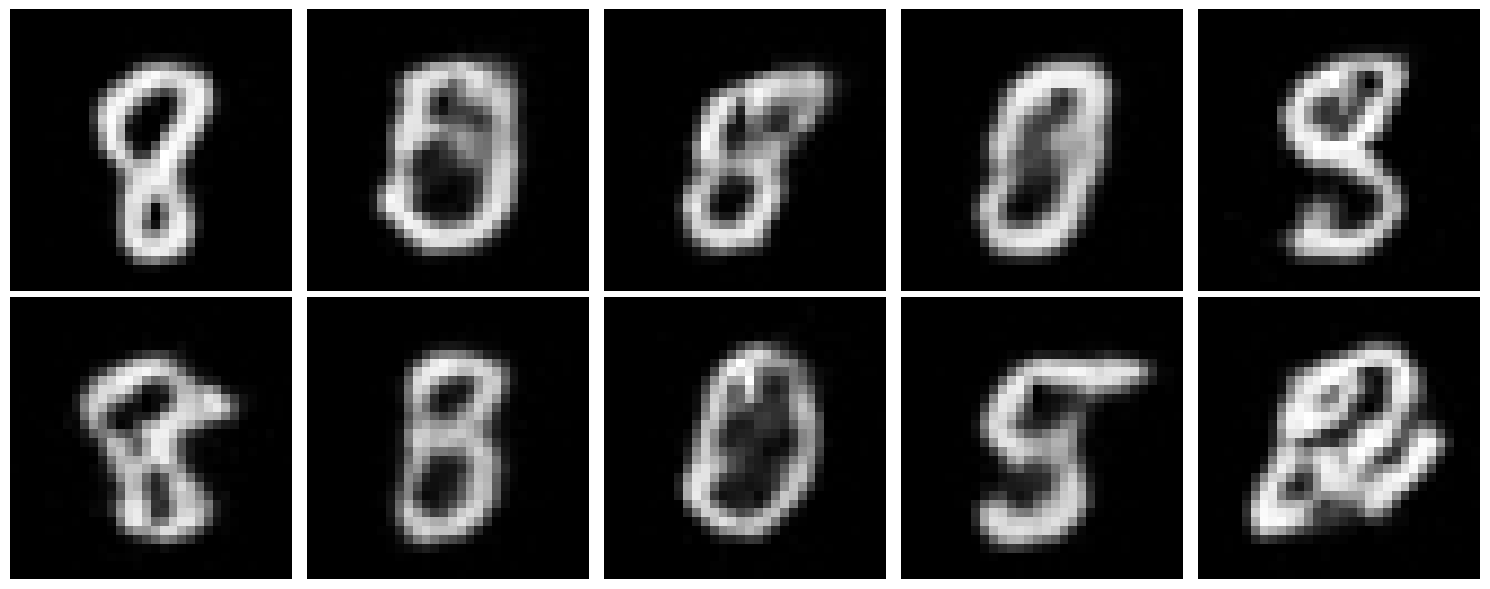

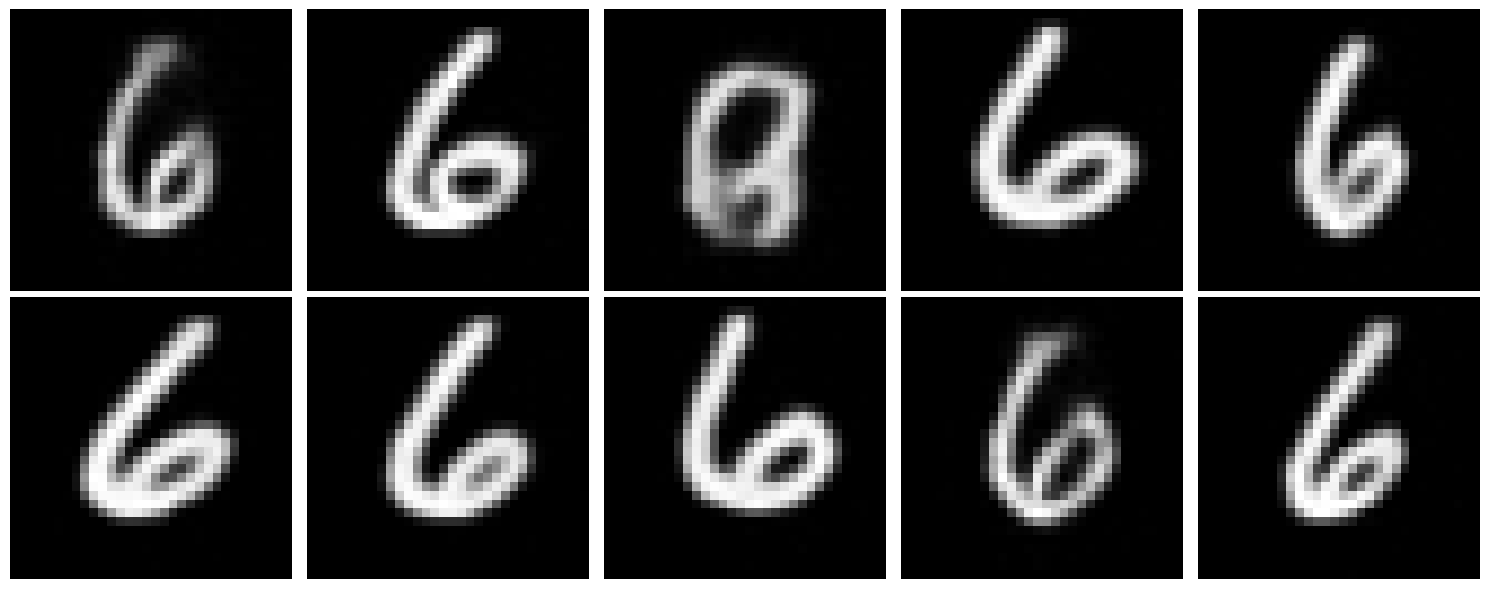

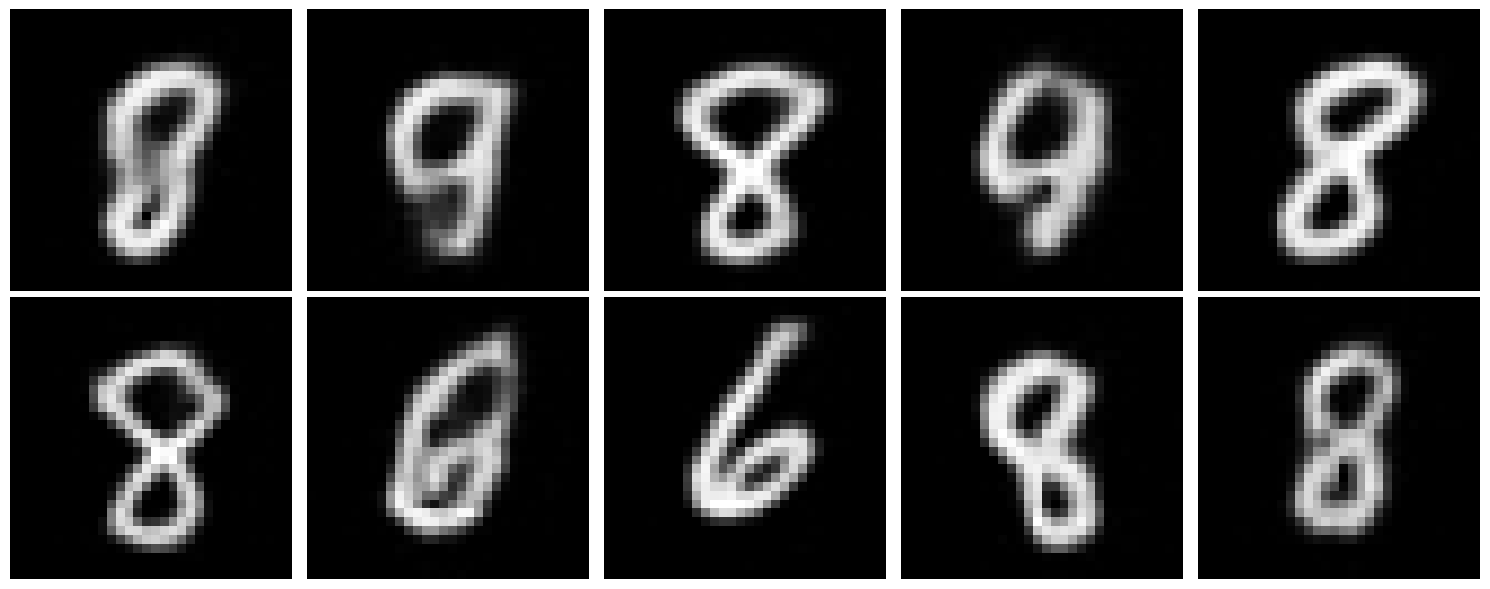

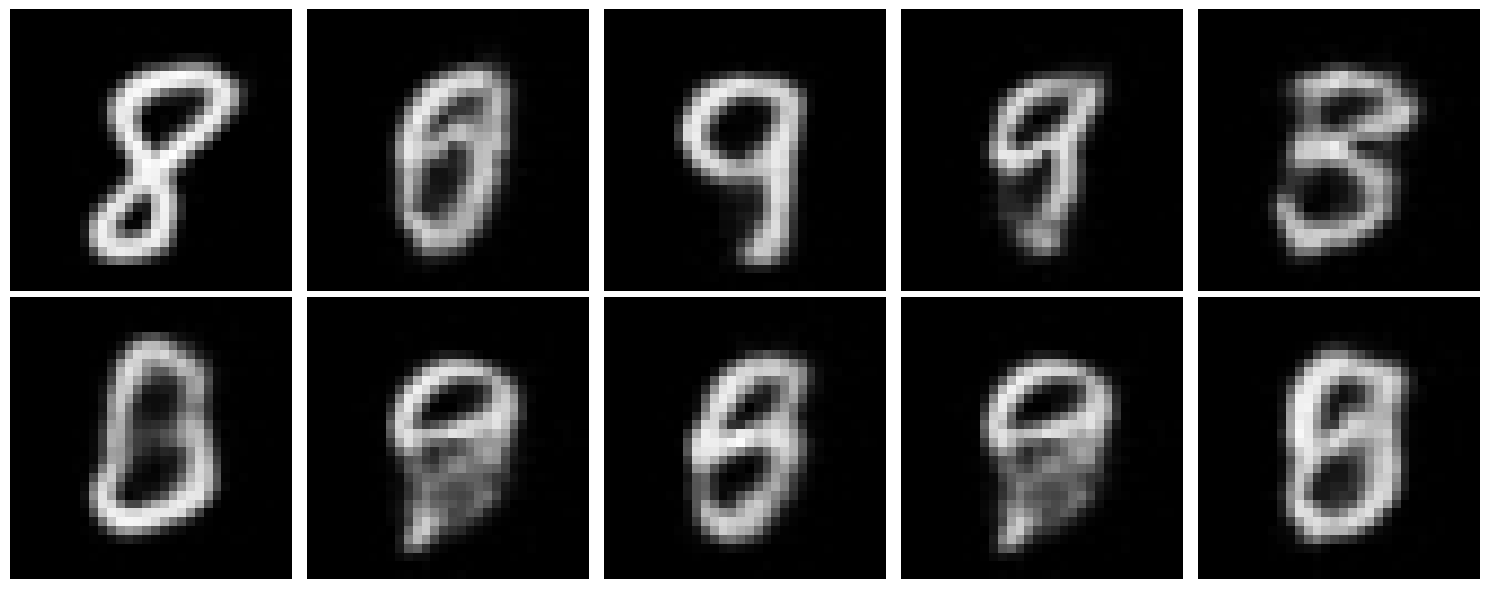

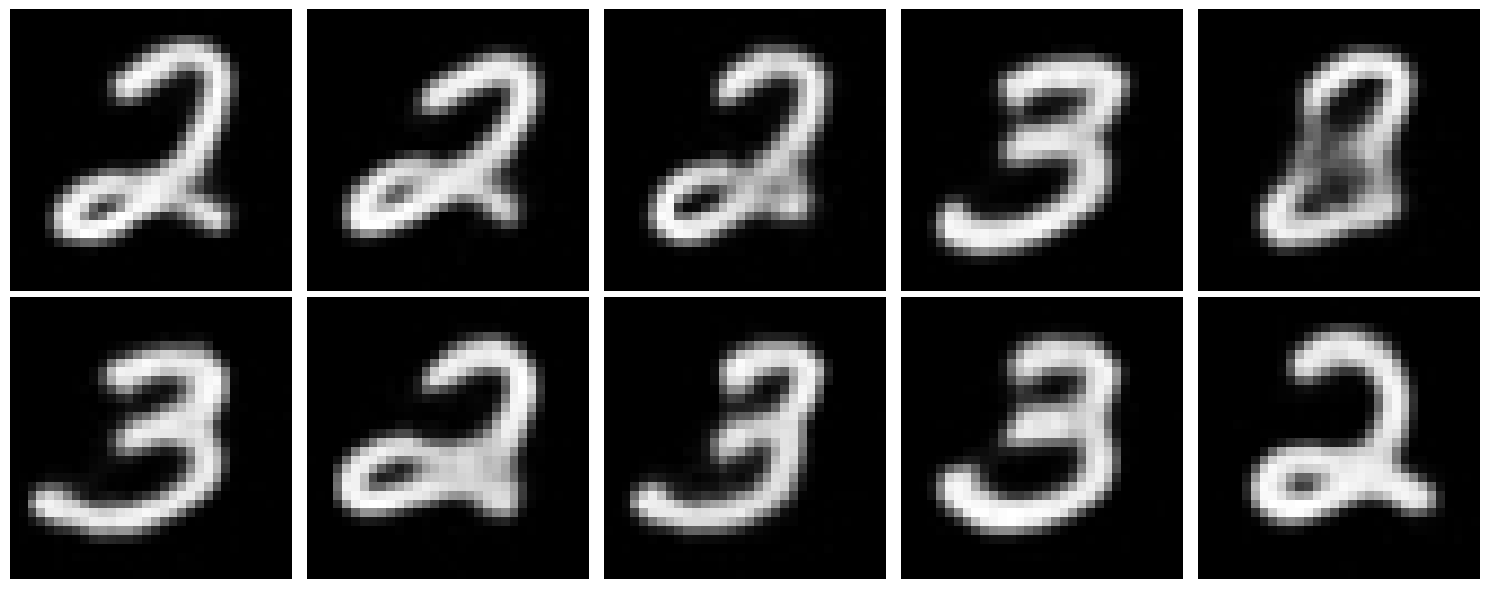

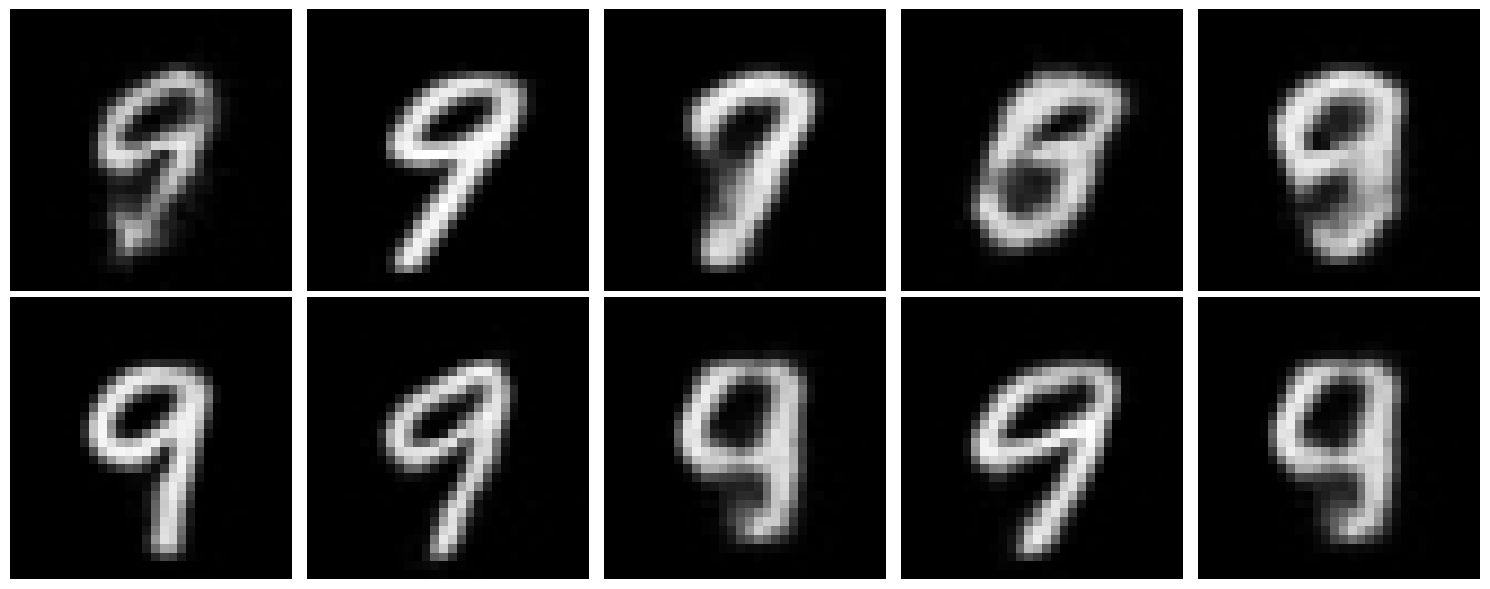

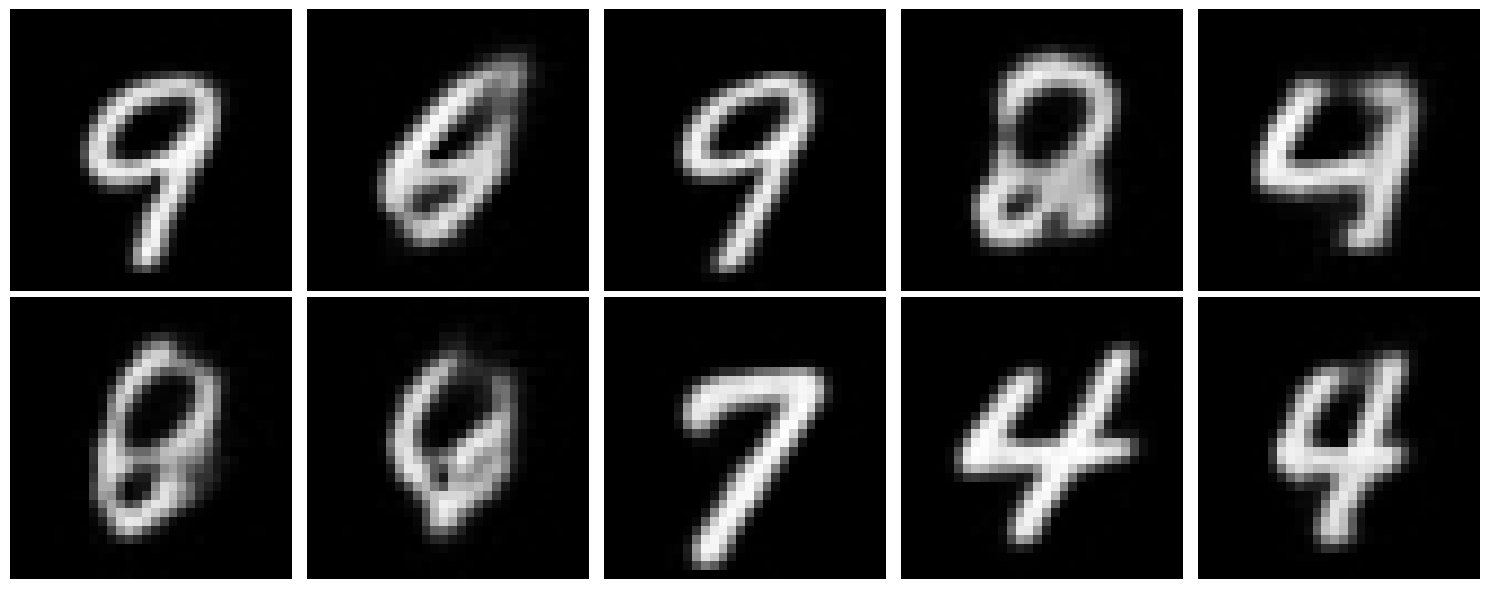

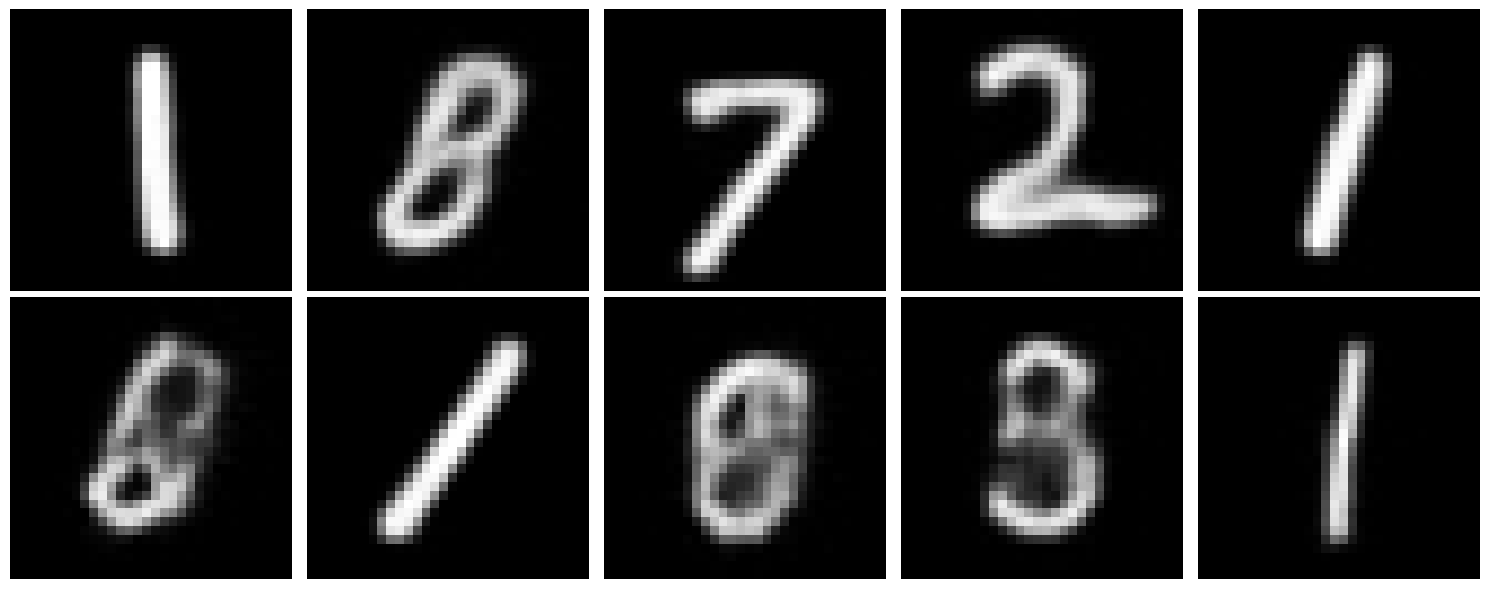

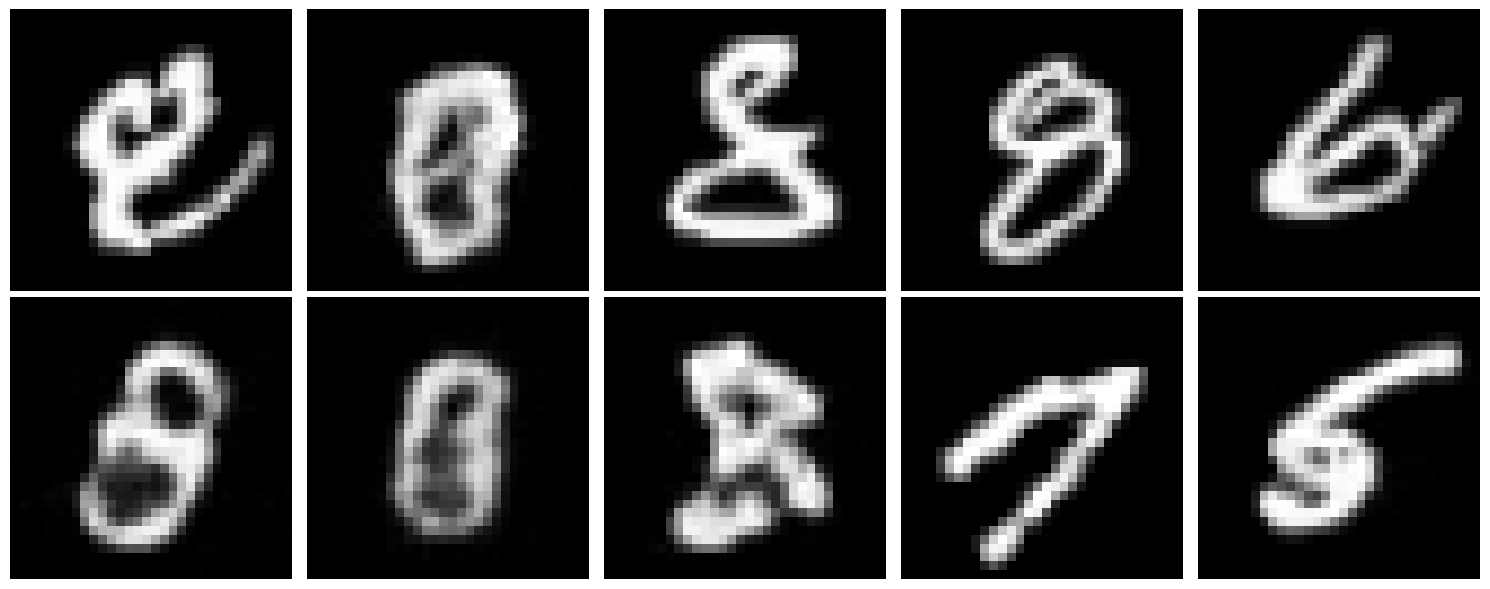

In [ ]:
# visualize archetypes
num_vertical = n_archetypes // 5
for k in range(len(archetypes_unsupervised)):
    fig, axes = plt.subplots(num_vertical, 5, figsize=(15, 3 * num_vertical))
    axes = axes.flatten()
    for i in range(n_archetypes):
        axes[i].imshow(archetypes_unsupervised[k][i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i].axis('off') 
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder,f"archetype_{k}_phi_unsupervised.png"))
    plt.show()

In [ ]:
# construct star from archetypes
star_unsupervised = MultimodalDataEnclosingEllipsoidStarDistribution(phi_archetypes_unsupervised, phi_centers_unsupervised, reg_param=1e-3)

Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([18.3916, 11.9374, 11.6865, 10.7716, 10.6520,  9.5330,  7.9850,  7.8851,
         2.0199])
Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([22.8734, 19.2765, 15.1074, 13.6009, 12.6210, 12.1394,  9.8488,  8.5053,
         7.8201,  3.1799])
Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([70.7800, 58.3595, 50.3759, 44.8259, 42.9601, 38.5691, 37.2687, 37.0215,
        30.4198])
Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([43.7984, 29.9264, 18.6410, 16.3169, 15.3303, 14.6750, 12.8504, 12.0472,
         9.7465,  2.9408])
Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([22.5960, 18.6384, 17.3802, 15.7590, 14.9025, 10.3758,  9.2403,  7.3997,
         2.8681])
Singular values of (I - mu mu^T / ||mu||^2) @ (m - mu)^T: tensor([17.8704, 12.8575, 12.3496, 11.7233, 11.3783,  9.4639,  9.2957,  8.2642,
         7.9515,  2.3874])
Singular values of (I - mu mu^T / ||m

In [ ]:
# construct manifold
chi_unsupervised = StarImageDiffeomorphism(1, H, W, star_unsupervised).to(device)
Omega_unsupervised = ImageCompositionDiffeomorphism([phi, chi_unsupervised], 1, H, W)
# Omega_unsupervised = ImageCompositionDiffeomorphism([phi, chi_unsupervised, ConcaveImageDiffeomorphism(1, H, W, LogConcave(a=10.))], 1, H, W)

In [ ]:
Omega_unsupervised_manifold = StandardPullbackImageEuclidean(Omega_unsupervised)

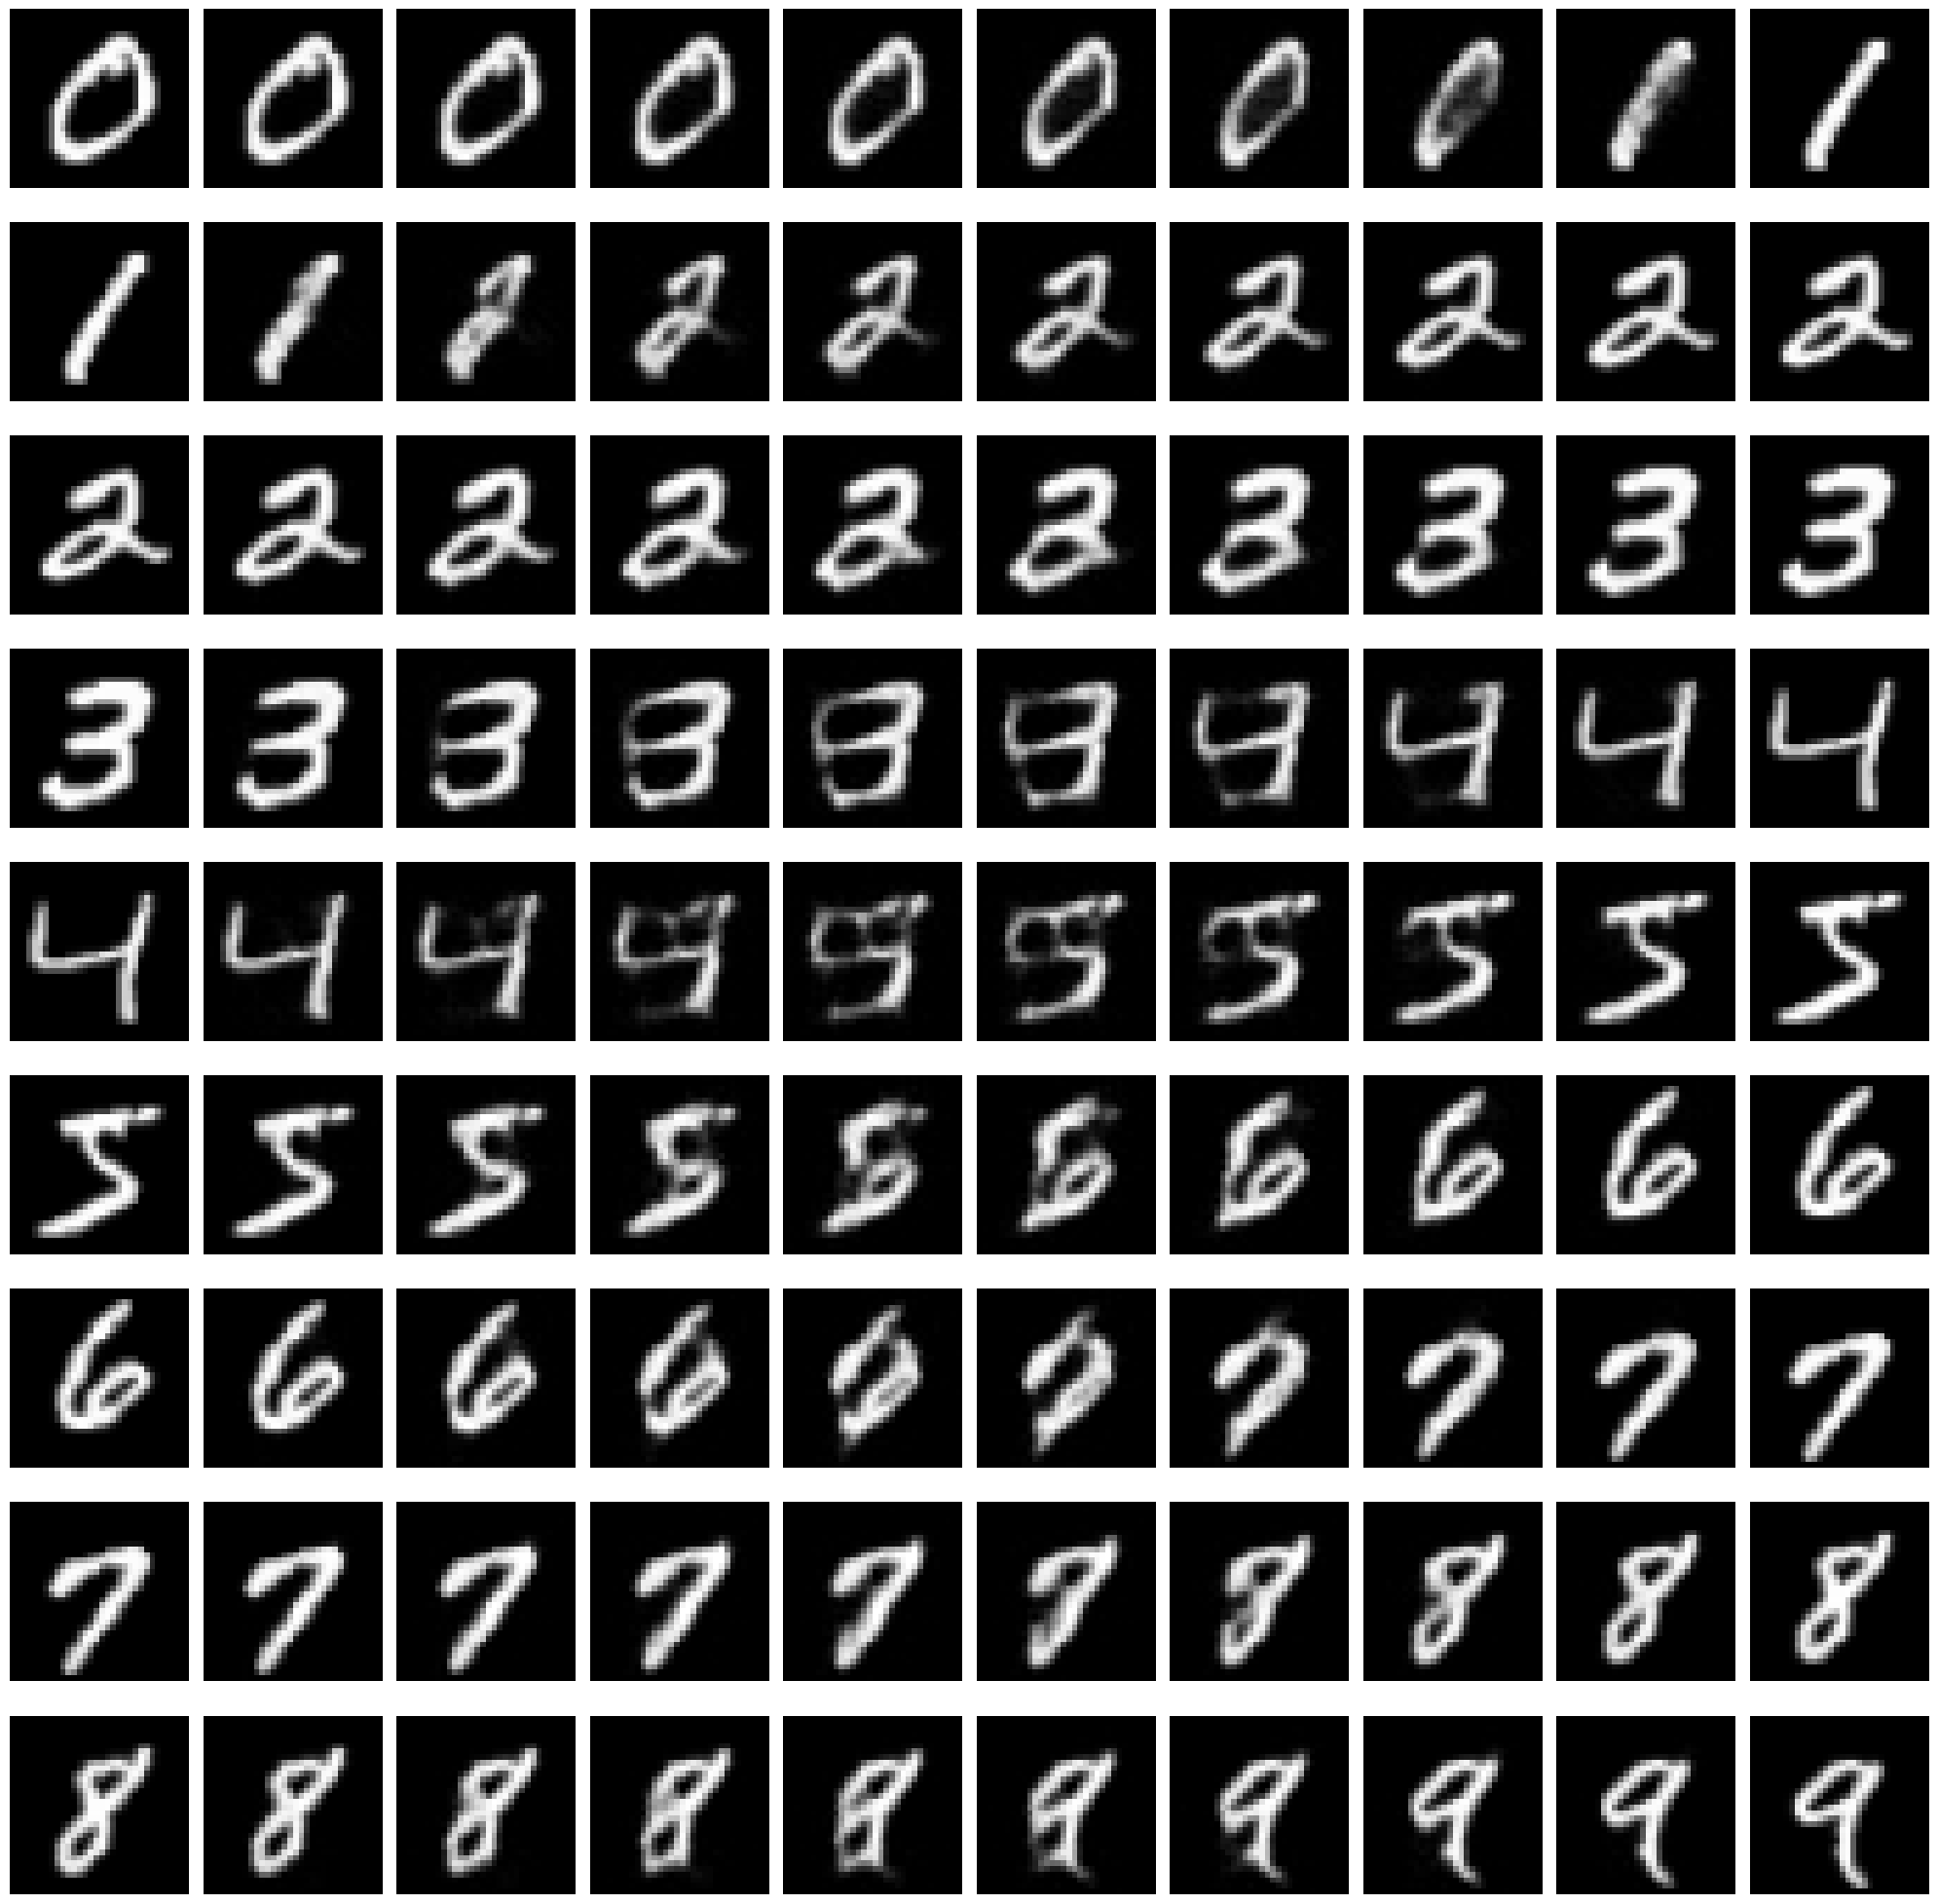

In [ ]:
with torch.no_grad():
    Omega_unsupervised_geodesics = Omega_unsupervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu() 

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(Omega_unsupervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_unsupervised.png"))
plt.show()

In [ ]:
iso_Omega_unsupervised_manifold = l2IsometrizedImageEuclidean(Omega_unsupervised_manifold, num_intervals=20)

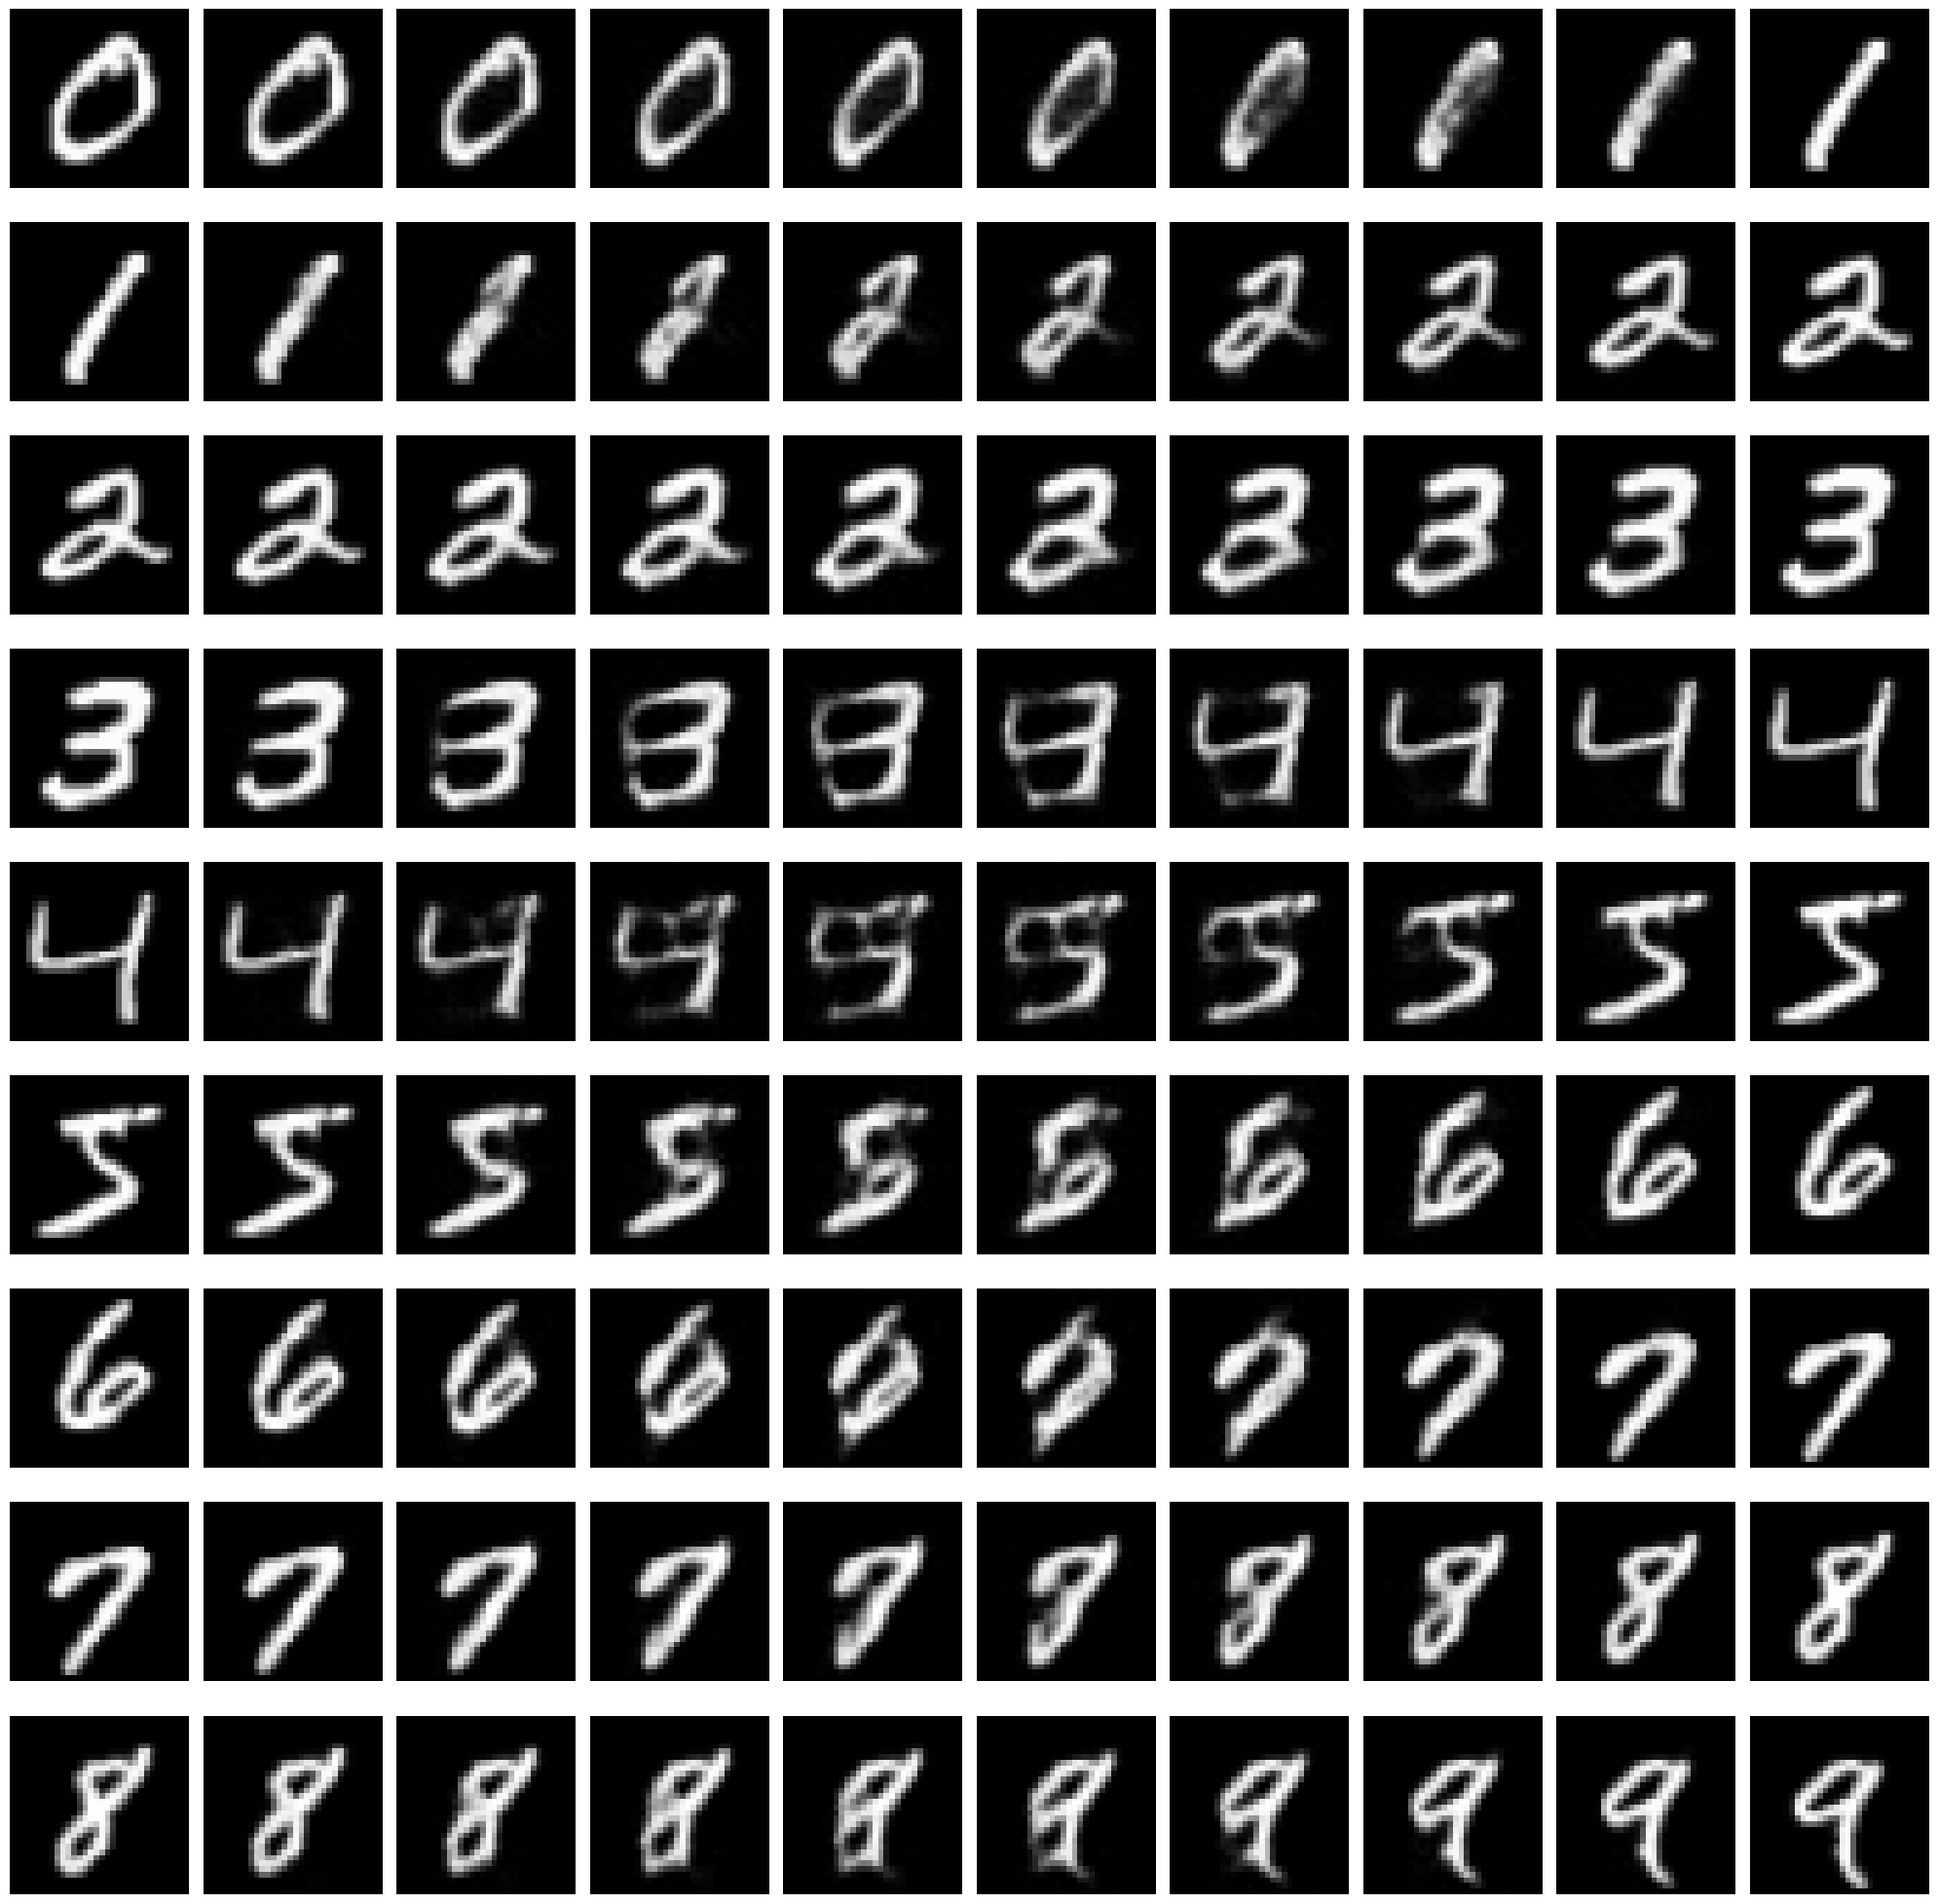

In [ ]:
# compute iso geodesics between all pairs of points
with torch.no_grad():
    iso_Omega_unsupervised_geodesics = iso_Omega_unsupervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()

# plot iso-geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(iso_Omega_unsupervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_iso_unsupervised.png"))
plt.show()

In [ ]:
# construct RAM
ram_unsupervised = RiemannianArchetypalMapping(Omega_supervised_manifold, torch.cat(archetypes_unsupervised, dim=0))

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/src/nn/module/riemannian/archetypal_mapping.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("pgd_step_tensor", torch.tensor(step, dtype=A.dtype, device=A.device))


In [ ]:
# project clusters
with torch.no_grad():
    ram_unsupervised_projected_data_clusters = ram_unsupervised.forward(data_clusters.to(device))
    ram_unsupervised_projected_centers = ram_unsupervised.forward(torch.stack(centers_unsupervised).to(device))

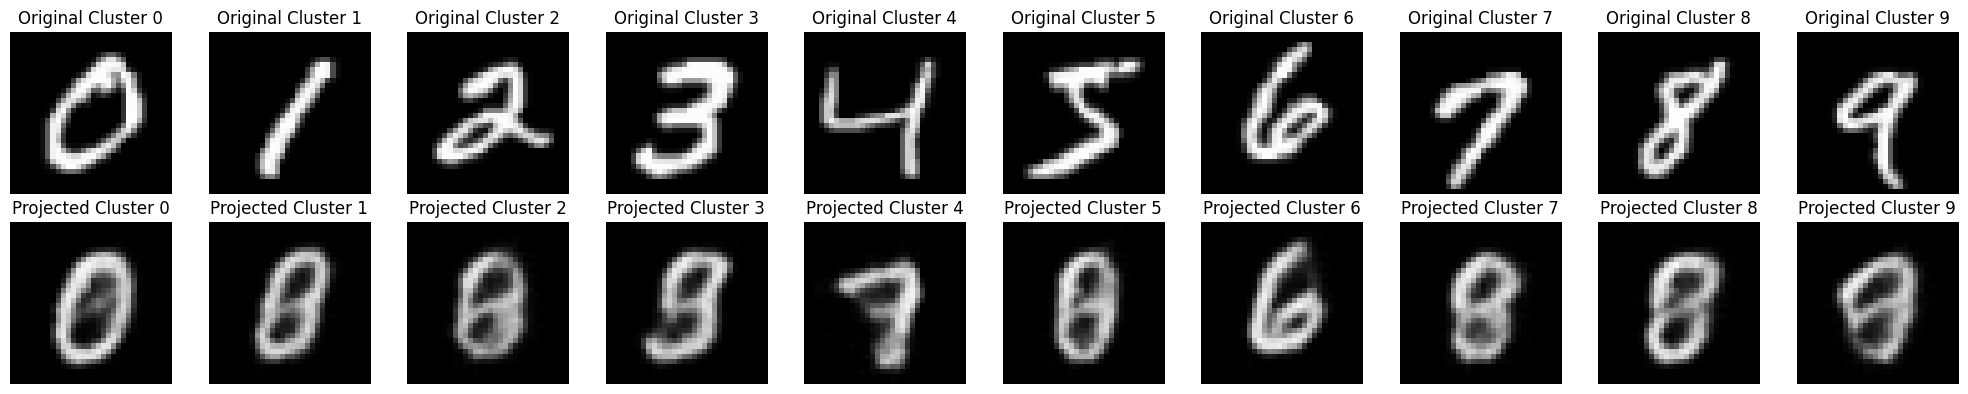

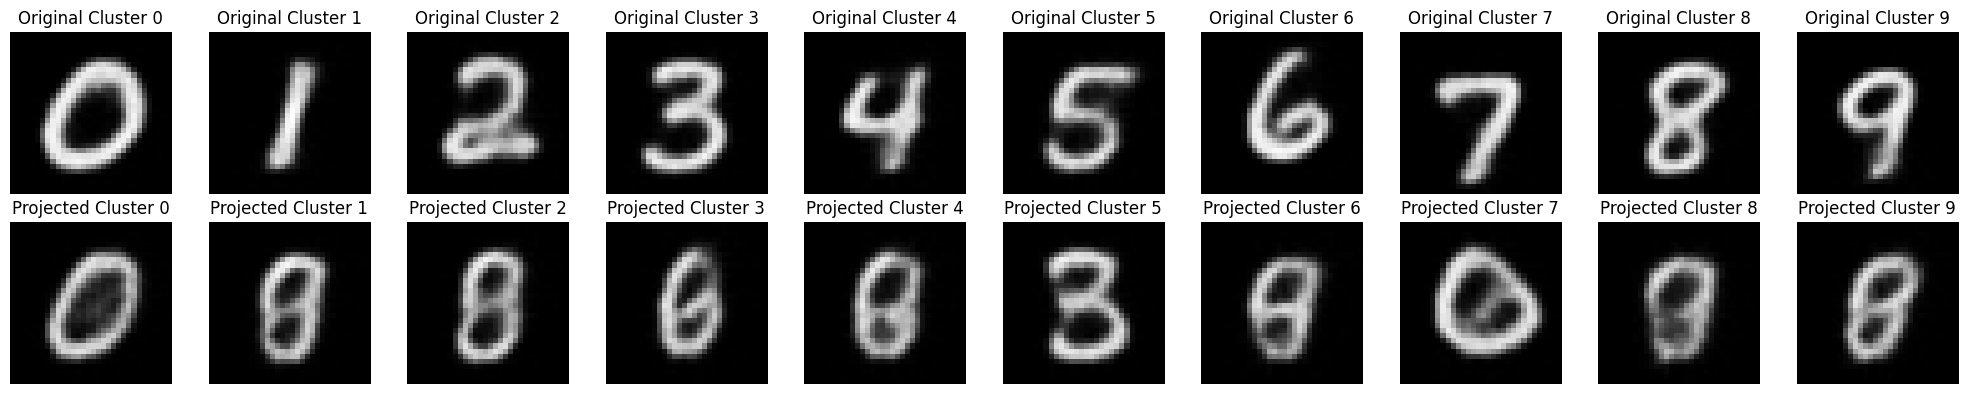

In [ ]:
# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_unsupervised_projected_data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(centers_supervised[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_unsupervised_projected_centers[i].reshape(H, W).squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()